# MODELADO

<div style="text-align: justify;">


Una vez concluido el proceso de análisis exploratorio, diagnóstico y control de calidad de los datos, se inicia la etapa de **modelado de `LiquiditySense`**, cuyo objetivo es transformar la información financiera histórica de las instituciones en una herramienta capaz de identificar señales de **deterioro futuro de la posición de liquidez**.

En esta etapa se construye formalmente la variable objetivo (`target`), utilizando la evolución trimestral del indicador `liquid_assets_assets` como referencia para identificar eventos de deterioro. La definición del objetivo se realiza desde una perspectiva temporal, de manera que la información disponible en un período determinado sea utilizada para anticipar si la institución presentará un deterioro de liquidez en el **trimestre siguiente**.

Posteriormente, se construye el conjunto de variables predictoras, excluyendo aquellas que podrían generar **data leakage**, es decir, información que no estaría disponible en el momento en que se pretende realizar la predicción. Este control es fundamental para garantizar que el desempeño obtenido por el modelo represente una capacidad predictiva real y no una ventaja artificial derivada del uso de información futura.

La preparación de los datos incluye además la clasificación de las variables predictoras, la identificación de variables financieras, ratios, indicadores de crecimiento y variables auxiliares, así como la eliminación de denominadores utilizados únicamente durante etapas de diagnóstico. Posteriormente, se realiza el tratamiento de valores faltantes y la estandarización de las variables mediante un proceso reproducible de preprocesamiento.

Debido a la naturaleza longitudinal de la información, la división de los datos se realiza **temporalmente**, diferenciando los períodos de entrenamiento, validación y prueba. Esta estrategia permite aproximar el escenario real de utilización del modelo: aprender con información histórica, evaluar configuraciones con información posterior y finalmente medir el desempeño sobre períodos futuros que no participaron en el entrenamiento.

Como algoritmo principal se utiliza **Random Forest**, complementado inicialmente con modelos de referencia como **XGBoost, HistGradientBoosting y Extra Trees**. La comparación permite determinar qué algoritmo presenta un mejor equilibrio entre capacidad discriminativa y desempeño de clasificación.

La evaluación considera métricas como **ROC-AUC, Accuracy, Precision, Recall y F1-score**, además de herramientas específicas para evaluar modelos de clasificación, como la curva ROC, la curva Precision-Recall, la matriz de confusión y el estadístico KS. Estas métricas permiten analizar el modelo desde diferentes perspectivas y no depender de un único indicador de desempeño.

Finalmente, se realiza un proceso de optimización del modelo Random Forest y se establece una configuración definitiva. La etapa concluye con el análisis de **interpretabilidad**, utilizando la importancia de variables para identificar qué factores financieros, ratios y medidas de crecimiento tienen mayor contribución relativa dentro del modelo.

De esta manera, el proceso de modelado sigue una secuencia lógica:

**Base procesada → Construcción del evento de deterioro → Target futuro → Control de Data Leakage → Selección de predictores → División temporal → Preprocesamiento → Entrenamiento → Evaluación → Comparación de modelos → Optimización → Modelo definitivo → Interpretabilidad → Guardado del modelo**

El resultado esperado de esta etapa es obtener un modelo predictivo capaz de asignar una **probabilidad de deterioro de liquidez para el siguiente trimestre**, utilizando exclusivamente información disponible hasta el período de predicción.

</div>



## 1. Carga de la Base Procesada

<div style="text-align: justify;">



En esta primera etapa se carga la base de datos obtenida como resultado del proceso de preparación y limpieza desarrollado en las etapas anteriores. Esta base constituye el punto de partida para la construcción del modelo predictivo.

El archivo utilizado es `base_liquidez_final.csv`, ubicado dentro de la carpeta `data/processed` del proyecto. La utilización de una base procesada permite asegurar que el modelado se realice sobre información previamente revisada, estructurada y depurada.

Durante la carga se utiliza la codificación `utf-8-sig`, con el objetivo de garantizar una correcta interpretación de los caracteres presentes en el archivo. Posteriormente, la variable `date` se convierte al formato `datetime`, permitiendo realizar operaciones temporales y establecer correctamente la división cronológica de los datos.

Además de cargar la información, se realiza una revisión inicial de:

* Número de registros.
* Número de variables.
* Número de bancos representados.
* Fecha mínima y máxima disponible.
* Tipo de dato de las variables.

Esta verificación permite confirmar que la base utilizada por el modelo mantiene la estructura esperada y que la dimensión temporal se encuentra correctamente definida.

### 1.1. Objetivo

El objetivo de esta sección es garantizar que la base utilizada para el modelado corresponda a la versión final procesada y que sus principales características estructurales sean conocidas antes de iniciar la construcción de la variable objetivo.

</div>


In [1]:
# ============================================================
# 1. CARGA DE LA BASE PROCESADA
# ============================================================

import pandas as pd
import numpy as np

ruta_base = r"D:\Edwin\DIPLOMADO INGENIERIA DE DATOS\Machine Learning II\Proyecto\LiquiditySense\data\processed\base_liquidez_final.csv"

Base = pd.read_csv(
    ruta_base,
    encoding="utf-8-sig"
)

# Convertir fecha a datetime
Base['date'] = pd.to_datetime(
    Base['date'],
    errors='coerce'
)

print("=" * 60)
print("1. CARGA DE LA BASE PROCESADA")
print("=" * 60)

print(f"Filas    : {Base.shape[0]:,}")
print(f"Columnas : {Base.shape[1]:,}")
print(f"Bancos   : {Base['id_rssd'].nunique():,}")
print(f"Desde    : {Base['date'].min()}")
print(f"Hasta    : {Base['date'].max()}")
print(f"Tipo date: {Base['date'].dtype}")

1. CARGA DE LA BASE PROCESADA
Filas    : 698,181
Columnas : 88
Bancos   : 11,339
Desde    : 2000-01-01 00:00:00
Hasta    : 2025-10-01 00:00:00
Tipo date: datetime64[us]



## 2. Creación de `TARGET` de Liquidez

<div style="text-align: justify;">


La construcción de la variable objetivo constituye una de las etapas fundamentales del proyecto, debido a que define exactamente qué comportamiento se pretende anticipar mediante Machine Learning.

En este caso, el objetivo consiste en identificar **eventos futuros de deterioro de la liquidez bancaria**. Para ello, se utiliza como referencia el indicador `liquid_assets_assets`, que representa la relación entre los activos líquidos y los activos totales del banco.

La metodología busca que el modelo no se limite a describir la situación actual de liquidez, sino que utilice la información disponible en un periodo determinado para **anticipar un posible deterioro durante el trimestre siguiente**.

La construcción del `target` se desarrolla en varias etapas:

1. Identificación de la liquidez del trimestre anterior.
2. Cálculo de la variación relativa trimestral.
3. Determinación de un umbral de deterioro.
4. Identificación de los eventos de deterioro.
5. Desplazamiento temporal del evento para construir el objetivo futuro.

De esta manera, la variable objetivo representa un evento que ocurre posteriormente al periodo en el que se encuentran las variables predictoras.

</div>


In [2]:
# ============================================================
# 2. CREACIÓN DEL TARGET DE LIQUIDEZ
# ============================================================

# Orden temporal
Base = Base.sort_values(
    ['id_rssd', 'date']
).reset_index(drop=True)





### 2.1. Liquidez del trimestre anterior

<div style="text-align: justify;">

Para determinar si existe un deterioro de la liquidez es necesario comparar la situación actual de cada banco con su comportamiento observado en el periodo inmediatamente anterior.

Para ello, se utiliza la variable `liquid_assets_assets` y, mediante `groupby('id_rssd')` junto con `shift(1)`, se obtiene el valor correspondiente al trimestre anterior para cada banco.

La operación se realiza después de ordenar la información por `id_rssd` y `date`, garantizando que el desplazamiento temporal respete correctamente la secuencia histórica de cada institución.

El resultado se almacena en la variable `liquidez_anterior`.

Conceptualmente:

$$
Liquidez_{t-1} = liquid\_assets\_assets_{t-1}
$$

donde:

* \(t\) representa el trimestre actual.
* \(t-1\) representa el trimestre inmediatamente anterior.
* `liquid_assets_assets` corresponde al indicador de activos líquidos sobre activos totales.

Esta variable constituye el punto de referencia necesario para calcular posteriormente el cambio relativo de liquidez.

</div>


In [3]:
# ------------------------------------------------------------
# 2.1 Liquidez del trimestre anterior
# ------------------------------------------------------------

Base['liquidez_anterior'] = (
    Base.groupby('id_rssd')['liquid_assets_assets']
    .shift(1)
)

### 2.2. Cambio relativo trimestral de liquidez

<div style="text-align: justify;">


Una vez obtenida la liquidez correspondiente al trimestre anterior, se calcula el cambio relativo trimestral del indicador `liquid_assets_assets`.

La variación se determina mediante:

$$
\text{Cambio Liquidez}_{t} = \frac{\text{Liquidez}_{t} - \text{Liquidez}_{t-1}}{\text{Liquidez}_{t-1}}
$$

Esta medida permite identificar cuánto aumentó o disminuyó la liquidez de cada banco respecto al trimestre inmediatamente anterior.

El resultado puede interpretarse de la siguiente manera:

* Un valor **positivo** indica un incremento relativo de la liquidez.
* Un valor **cercano a cero** indica estabilidad respecto al trimestre anterior.
* Un valor **negativo** indica una reducción relativa de la liquidez.
* Cuanto más negativo sea el valor, mayor será la magnitud del deterioro observado.

Posteriormente, se calculan diferentes percentiles de la distribución: 1%, 5%, 10%, 25%, 50%, 75%, 90%, 95% y 99%.

Esta revisión permite conocer la distribución de los cambios trimestrales antes de establecer el criterio utilizado para definir un evento de deterioro.

In [4]:

# ------------------------------------------------------------
# 2.2 Cambio relativo trimestral de liquidez
# ------------------------------------------------------------

Base['cambio_liquidez_qoq'] = (
    (Base['liquid_assets_assets'] - Base['liquidez_anterior'])
    / Base['liquidez_anterior']
)

print("=" * 60)
print("2. CAMBIO TRIMESTRAL RELATIVO DE LIQUIDEZ")
print("=" * 60)

print(
    Base['cambio_liquidez_qoq']
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

2. CAMBIO TRIMESTRAL RELATIVO DE LIQUIDEZ
count    6.865310e+05
mean              inf
std               NaN
min     -1.000000e+00
1%      -3.845940e-01
5%      -1.958310e-01
10%     -1.314436e-01
25%     -5.992136e-02
50%     -5.889957e-03
75%      5.326525e-02
90%      1.524500e-01
95%      2.589184e-01
99%      7.332181e-01
max               inf
Name: cambio_liquidez_qoq, dtype: float64


d:\Edwin\DIPLOMADO INGENIERIA DE DATOS\Machine Learning II\Proyecto\LiquiditySense\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



### 2.3. Umbral de deterioro
<div style="text-align: justify;">

Para transformar el cambio continuo de liquidez en un evento binario de deterioro, se establece un umbral basado en la propia distribución histórica de `cambio_liquidez_qoq`.

El umbral se define mediante el **percentil 10 (P10)**:

$$
Umbral = P_{10}(Cambio\ Liquidez_{qoq})
$$

La utilización del percentil 10 permite identificar los movimientos trimestrales ubicados en la parte más desfavorable de la distribución, evitando establecer de manera arbitraria un porcentaje fijo de reducción.

Por tanto, el criterio no debe interpretarse como una caída fija del 10 %. El **10 % corresponde al percentil utilizado para definir el umbral**, mientras que el porcentaje concreto de reducción dependerá de la distribución observada en los datos.

Este enfoque permite construir un evento de deterioro adaptado al comportamiento histórico de la muestra.

</div>


In [5]:
# ============================================================
# 2.3 DEFINICIÓN DEL UMBRAL DE DETERIORO
# ============================================================

umbral_deterioro = (
    Base['cambio_liquidez_qoq']
    .quantile(0.10)
)

print("=" * 60)
print("UMBRAL DE DETERIORO DE LIQUIDEZ")
print("=" * 60)

print(f"Umbral P10 : {umbral_deterioro:.6f}")
print(f"Equivalente: {umbral_deterioro:.2%}")

UMBRAL DE DETERIORO DE LIQUIDEZ
Umbral P10 : -0.131444
Equivalente: -13.14%


### 2.4. Definición del Umbral de Deterioro

<div style="text-align: justify;">

Para definir objetivamente qué se considera un deterioro significativo de liquidez, se establece como umbral el **percentil 10 (P10)** de la distribución histórica del cambio relativo trimestral de liquidez (`cambio_liquidez_qoq`). Esta metodología permite identificar los episodios ubicados en la cola inferior de la distribución, correspondientes a las mayores reducciones observadas en la liquidez de las instituciones analizadas.

El cálculo realizado sobre la base histórica determina un umbral de **-0,131444**, equivalente a una disminución aproximada de **13,14 %** en la liquidez respecto al trimestre anterior.

Por tanto, para la construcción del evento de deterioro, se considerará como una situación de deterioro aquella observación cuyo cambio trimestral de liquidez sea **menor o igual a -13,14 %**. En términos prácticos, esto significa que una reducción de liquidez igual o superior en magnitud al 13,14 % respecto al trimestre anterior será clasificada como un evento de deterioro.

La utilización del percentil 10 permite establecer un criterio basado en el comportamiento observado en la propia distribución histórica de los datos, evitando imponer arbitrariamente un porcentaje fijo de reducción. De esta manera, el umbral refleja las condiciones y características de la muestra utilizada para desarrollar el modelo.

Es importante señalar que el valor de **-13,14 % no representa una pérdida absoluta de liquidez**, sino un **cambio relativo trimestral** respecto al período anterior. Este umbral será posteriormente utilizado para construir la variable indicadora del evento de deterioro y, a partir de ella, el `target` futuro que será objeto de predicción.

</div>

**Resultado obtenido:**

| Indicador              |                                              Resultado |
| ---------------------- | -----------------------------------------------------: |
| Percentil utilizado    |                                                    P10 |
| Umbral de deterioro    |                                              -0,131444 |
| Equivalente porcentual |                                           **-13,14 %** |
| Interpretación         | Reducción trimestral de liquidez ≥ 13,14 % en magnitud |


### 2.5. Evento de Deterioro

<div style="text-align: justify;">

Una vez definido el umbral correspondiente al percentil 10, se construye la variable `deterioro_liquidez`.

El evento se define mediante la condición:

$$
deterioro\_liquidez =
\begin{cases}
1, & \text{si } cambio\_liquidez\_qoq \leq Umbral\\
0, & \text{si } cambio\_liquidez\_qoq > Umbral
\end{cases}
$$

Por lo tanto:

* **1:** representa un trimestre identificado como evento de deterioro.
* **0:** representa un trimestre que no cumple el criterio de deterioro.

La variable se almacena utilizando el tipo entero nullable `Int64`, permitiendo conservar valores nulos cuando no sea posible determinar el evento debido a la ausencia de información necesaria para calcular la variación.

Finalmente, se revisa la cantidad y proporción de observaciones correspondientes a cada clase.

Esta etapa transforma una variable financiera continua en una variable binaria que puede ser utilizada posteriormente en un problema de **clasificación supervisada**.

</div>


In [6]:
# ============================================================
# 2.4 CLASIFICACIÓN DEL EVENTO DE DETERIORO
# ============================================================

Base['deterioro_liquidez'] = (
    Base['cambio_liquidez_qoq'] <= umbral_deterioro
).astype('Int64')

print("=" * 60)
print("DISTRIBUCIÓN DEL EVENTO DE DETERIORO")
print("=" * 60)

print(
    Base['deterioro_liquidez']
    .value_counts(dropna=False)
)

print("\nProporción:")
print(
    Base['deterioro_liquidez']
    .value_counts(
        normalize=True,
        dropna=False
    )
)

DISTRIBUCIÓN DEL EVENTO DE DETERIORO
deterioro_liquidez
0    629527
1     68654
Name: count, dtype: Int64

Proporción:
deterioro_liquidez
0    0.901667
1    0.098333
Name: proportion, dtype: Float64


### 2.6. Clasificación del Evento de Deterioro

<div style="text-align: justify;">

Una vez definido el umbral de deterioro de liquidez, se construye la variable `deterioro_liquidez`, que identifica aquellos registros en los que la variación trimestral de los activos líquidos se encuentra en el extremo inferior de su distribución histórica. En particular, se clasifica como evento de deterioro cuando el cambio relativo trimestral de liquidez (`cambio_liquidez_qoq`) es menor o igual al umbral previamente establecido de **-13,14 %**.

La variable resultante es de naturaleza binaria, donde **0 representa la ausencia de un evento de deterioro** y **1 representa la ocurrencia de un evento de deterioro de liquidez**. Esta clasificación constituye posteriormente la base para la construcción del `target` predictivo.

El resultado obtenido muestra la siguiente distribución:

</div>

| Clasificación         |   Registros |   Proporción |
| --------------------- | ----------: | -----------: |
| **0 – Sin deterioro** |     629.527 |      90,17 % |
| **1 – Con deterioro** |      68.654 |       9,83 % |
| **Total**             | **698.181** | **100,00 %** |

<div style="text-align: justify;">

Se observa que de los **698.181 registros con evento clasificable**, **68.654 corresponden a episodios de deterioro de liquidez**, equivalentes al **9,83 %** del total, mientras que **629.527 registros (90,17 %)** no presentan dicho evento.

Esta distribución evidencia una **clase minoritaria asociada al deterioro de liquidez**, aunque con una frecuencia suficiente para ser modelada mediante técnicas de clasificación supervisada. Al mismo tiempo, el desbalance observado deberá ser considerado durante la etapa de entrenamiento y evaluación del modelo, evitando utilizar únicamente métricas como Accuracy, que podrían proporcionar una visión incompleta del desempeño frente a la clase de interés.

Es importante señalar que la clasificación no implica que el 9,83 % de los registros represente necesariamente una situación de insolvencia o crisis bancaria. El evento definido corresponde específicamente a una **reducción trimestral de los activos líquidos igual o superior al 13,14 % en términos relativos**, de acuerdo con el criterio estadístico establecido en la etapa anterior.

</div>


### 2.7. Target Futuro

<div style="text-align: justify;">

El objetivo principal del proyecto no consiste en identificar el deterioro que ya ocurrió, sino en **anticipar un posible deterioro en el siguiente trimestre**.

Para lograrlo, se utiliza nuevamente `groupby('id_rssd')`, pero esta vez aplicando `shift(-1)` sobre `deterioro_liquidez`.

De esta manera:

$$
Target_t = Deterioro_{t+1}
$$

Es decir, las variables disponibles en el trimestre \(t\) serán utilizadas para predecir si el banco presentará un evento de deterioro durante el trimestre \(t+1\).

Esta transformación temporal es fundamental para convertir el problema en uno de **predicción anticipada**.

Por ejemplo:

| Periodo de información | Evento utilizado como objetivo |
| ---------------------- | ------------------------------ |
| Trimestre \(t\)        | Deterioro en \(t+1\)           |
| Trimestre \(t+1\)      | Deterioro en \(t+2\)           |
| Trimestre \(t+2\)      | Deterioro en \(t+3\)           |

La última observación disponible de cada banco no puede tener un `target` futuro, debido a que no existe un trimestre posterior dentro de la base. Estas observaciones serán posteriormente excluidas de la base definitiva de modelado.

</div>


In [7]:
# ============================================================
# 2.5 TARGET — DETERIORO EN EL SIGUIENTE TRIMESTRE
# ============================================================

Base = Base.sort_values(
    ['id_rssd', 'date']
).reset_index(drop=True)

Base['target'] = (
    Base.groupby('id_rssd')['deterioro_liquidez']
    .shift(-1)
)

print("=" * 60)
print("DISTRIBUCIÓN DEL TARGET FUTURO")
print("=" * 60)

print(
    Base['target']
    .value_counts(dropna=False)
)

print("\nProporción:")
print(
    Base['target']
    .value_counts(
        normalize=True,
        dropna=False
    )
)

DISTRIBUCIÓN DEL TARGET FUTURO
target
0       618188
1        68654
<NA>     11339
Name: count, dtype: Int64

Proporción:
target
0       0.885427
1       0.098333
<NA>    0.016241
Name: proportion, dtype: Float64



## 3. Evitando Data Leakage

<div style="text-align: justify;">

Antes de construir el conjunto definitivo de variables predictoras, se realiza una etapa específica para prevenir el **Data Leakage** o fuga de información.

El Data Leakage ocurre cuando información que no estaría disponible en el momento real de realizar una predicción termina siendo utilizada directa o indirectamente por el modelo. En un problema de predicción de deterioro de liquidez, este problema es especialmente relevante, debido a que la variable objetivo se construye utilizando información temporal futura.

El objetivo de esta etapa es garantizar que las variables utilizadas como predictores representen únicamente información que podría estar disponible al momento de generar la predicción.

Para ello, inicialmente se realiza un inventario de todas las variables presentes en la base y se revisan sus dimensiones. Posteriormente, se construye el conjunto `X` de variables predictoras y el vector `y` correspondiente al objetivo.

Las variables utilizadas para construir el evento de deterioro o que contienen información auxiliar directamente relacionada con dicha construcción son excluidas del conjunto de predictores.

Entre las variables excluidas se encuentran:

| Variable / grupo                  | Motivo de exclusión                                                                   |
| --------------------------------- | ------------------------------------------------------------------------------------- |
| `liquidez_anterior`               | Participa directamente en el cálculo del cambio de liquidez                           |
| `cambio_liquidez_qoq`             | Se utiliza directamente para definir el evento de deterioro                           |
| `deterioro_liquidez`              | Es la variable intermedia utilizada para construir el `target`                        |
| `target`                          | Corresponde a la variable que el modelo debe predecir                                 |
| Variables `_denominador`          | Son variables auxiliares utilizadas para el diagnóstico y construcción de indicadores |
| Variables `_faltante_estructural` | Corresponden a indicadores diagnósticos sobre la disponibilidad de información        |
| `faltante_estructural_yoy`        | Variable auxiliar relacionada con el diagnóstico temporal de faltantes                |
| `faltante_estructural_qoq`        | Variable auxiliar relacionada con el diagnóstico temporal de faltantes                |

El criterio general puede resumirse de la siguiente manera:

$$
X = Información\ disponible\ para\ predecir
$$

$$
y = Deterioro\ de\ liquidez\ en\ el\ trimestre\ siguiente
$$

La separación entre `X` e `y` permite establecer claramente qué información será utilizada por el algoritmo y cuál constituye el resultado que se pretende anticipar.

Es importante destacar que la prevención del Data Leakage no se limita únicamente a eliminar la variable `target`. También es necesario excluir variables derivadas directamente de su construcción, ya que su inclusión podría permitir al algoritmo reconstruir parcial o totalmente el evento objetivo y producir una evaluación artificialmente elevada.

Por esta razón, esta etapa constituye un control metodológico fundamental para garantizar que el desempeño obtenido posteriormente represente de manera razonable la capacidad predictiva del modelo.

</div>


In [8]:
# ============================================================
# 3. EVITANDO DATA LEAKAGE
# ============================================================

print("=" * 60)
print("3. INVENTARIO DE VARIABLES PARA MODELADO")
print("=" * 60)

for i, col in enumerate(Base.columns, start=1):
    print(f"{i:3}. {col}")

print("\n" + "=" * 60)
print("DIMENSIONES")
print("=" * 60)

print(f"Filas   : {Base.shape[0]:,}")
print(f"Columnas: {Base.shape[1]:,}")

3. INVENTARIO DE VARIABLES PARA MODELADO
  1. id_rssd
  2. date
  3. assets
  4. cash
  5. securities
  6. deposits
  7. demand_deposits
  8. time_deposits
  9. brokered_dep
 10. insured_deposits
 11. ln_tot
 12. ln_tot_gross
 13. ln_re
 14. ln_ci
 15. ln_cons
 16. ln_agr
 17. ln_rre
 18. npl_tot
 19. liab_tot
 20. equity
 21. subdebt
 22. liquidez_inmediata
 23. cash_deposits
 24. securities_deposits
 25. loan_deposit
 26. loan_assets
 27. deposits_assets
 28. brokered_deposits_ratio
 29. insured_deposits_ratio
 30. time_deposits_ratio
 31. demand_deposits_ratio
 32. leverage_ratio
 33. liquid_assets_liabilities
 34. capital_assets_ratio
 35. npl_ratio
 36. loan_growth_yoy
 37. deposit_growth_yoy
 38. cash_growth_yoy
 39. securities_growth_yoy
 40. liabilities_growth_yoy
 41. assets_growth_yoy
 42. liquid_assets
 43. liquid_assets_growth_yoy
 44. liquid_assets_assets
 45. time_deposits_assets
 46. demand_deposits_assets
 47. loans_liquid_assets
 48. deposit_growth_qoq
 49. cash_growth


### 3.1. Construcción inicial de `X` e `y`

<div style="text-align: justify;">

En esta etapa se construyen formalmente los dos componentes principales del problema de aprendizaje supervisado:

* `X`: conjunto de variables predictoras.
* `y`: variable objetivo que representa el deterioro futuro de liquidez.

La variable `y` se obtiene directamente de `Base['target']`, mientras que `X` se construye eliminando de la base todas aquellas variables que podrían generar fuga de información o que corresponden a elementos auxiliares utilizados durante las etapas anteriores.

El conjunto de exclusiones considera:

```text
liquidez_anterior
cambio_liquidez_qoq
deterioro_liquidez
target
variables terminadas en _denominador
variables terminadas en _faltante_estructural
faltante_estructural_yoy
faltante_estructural_qoq
```

El procedimiento permite establecer una separación inicial entre las variables utilizadas para construir el objetivo y aquellas que potencialmente pueden actuar como predictores.

La estructura conceptual es:

$$
Base \rightarrow
\begin{cases}
X & \text{Variables predictoras}\\
y & \text{Variable objetivo}
\end{cases}
$$

Posteriormente se imprimen las dimensiones de `X` y `y`, así como el listado de variables excluidas. Esta revisión permite verificar que el proceso de depuración se haya ejecutado correctamente.

Es importante señalar que en esta etapa todavía se mantiene información como `id_rssd` y `date`. Estas variables serán tratadas posteriormente durante la construcción de la **base definitiva para el modelo**, donde se eliminarán los identificadores y campos temporales que no deben actuar directamente como variables financieras predictoras.

De esta manera, esta sección representa una primera separación metodológica entre el conjunto de información disponible y el objetivo que se pretende predecir, mientras que la depuración definitiva se realizará en las etapas posteriores.

</div>


In [9]:
# ============================================================
# 3.1 CONSTRUCCIÓN INICIAL DE X E Y
# ============================================================

# Variables que no deben utilizarse como predictores
variables_excluir = [
    'liquidez_anterior',
    'cambio_liquidez_qoq',
    'deterioro_liquidez',
    'target'
]

# Variables auxiliares de diagnóstico
variables_excluir += [
    col for col in Base.columns
    if (
        col.endswith('_denominador')
        or col.endswith('_faltante_estructural')
        or col in [
            'faltante_estructural_yoy',
            'faltante_estructural_qoq'
        ]
    )
]

# Variable objetivo
y = Base['target'].copy()

# Variables predictoras
X = Base.drop(
    columns=variables_excluir,
    errors='ignore'
).copy()

print("=" * 60)
print("CONSTRUCCIÓN DEL DATASET DE MODELADO")
print("=" * 60)

print("\nX:")
print(f"Filas   : {X.shape[0]:,}")
print(f"Columnas: {X.shape[1]:,}")

print("\ny:")
print(f"Filas   : {y.shape[0]:,}")

print("\nVariables excluidas:")
for col in variables_excluir:
    print("-", col)

CONSTRUCCIÓN DEL DATASET DE MODELADO

X:
Filas   : 698,181
Columnas: 56

y:
Filas   : 698,181

Variables excluidas:
- liquidez_anterior
- cambio_liquidez_qoq
- deterioro_liquidez
- target
- faltante_estructural_yoy
- faltante_estructural_qoq
- loan_growth_yoy_faltante_estructural
- deposit_growth_yoy_faltante_estructural
- cash_growth_yoy_faltante_estructural
- securities_growth_yoy_faltante_estructural
- liabilities_growth_yoy_faltante_estructural
- assets_growth_yoy_faltante_estructural
- liquid_assets_growth_yoy_faltante_estructural
- deposit_growth_qoq_faltante_estructural
- cash_growth_qoq_faltante_estructural
- liquid_assets_growth_qoq_faltante_estructural
- loan_growth_qoq_faltante_estructural
- liabilities_growth_qoq_faltante_estructural
- assets_growth_qoq_faltante_estructural
- securities_growth_qoq_faltante_estructural
- equity_growth_qoq_faltante_estructural
- loan_growth_qoq_denominador
- loan_growth_yoy_denominador
- deposit_growth_qoq_denominador
- deposit_growth_yoy_den


## 4. Revisión de Variables Predictoras

<div style="text-align: justify;">

Una vez construido el conjunto inicial de variables predictoras `X`, se procede a realizar una revisión de las variables disponibles para el modelado. Esta etapa tiene como finalidad comprender la composición de los predictores, identificar los principales indicadores financieros relacionados con la liquidez y analizar de manera preliminar su relación individual con la variable objetivo.

La revisión de variables constituye una etapa exploratoria y de diagnóstico previa al entrenamiento definitivo de los modelos. Su propósito no es determinar de manera automática qué variables deben permanecer o eliminarse, sino obtener evidencia sobre la naturaleza de la información disponible y su posible utilidad predictiva.

En el contexto de `LiquiditySense`, las variables predictoras representan diferentes dimensiones de la situación financiera de las instituciones, incluyendo niveles de activos y pasivos, indicadores de liquidez, estructura de depósitos, calidad de cartera, capitalización y tasas de crecimiento.

La revisión se concentra principalmente en dos aspectos. En primer lugar, se identifican los indicadores financieros que presentan una relación directa o indirecta con la posición de liquidez de las instituciones. En segundo lugar, se analiza la relación estadística individual entre las variables predictoras y el `target`, utilizando la correlación como una herramienta exploratoria.

Es importante señalar que una relación estadística individual elevada con el `target` no implica necesariamente que una variable sea indispensable para el modelo. Del mismo modo, una correlación baja no significa que una variable carezca de capacidad predictiva. Los algoritmos utilizados posteriormente pueden identificar relaciones no lineales, interacciones entre variables y patrones conjuntos que no son detectables mediante una medida de correlación simple.

Por esta razón, los resultados obtenidos en esta sección deben interpretarse como evidencia diagnóstica y no como un criterio automático de selección de variables.

La revisión de los predictores se organiza en dos componentes principales:

1. **Identificación de indicadores de liquidez y variables financieras relevantes.**
2. **Análisis de la relación univariada entre los predictores y el `target`.**

Esta revisión permite establecer una conexión entre la interpretación financiera de las variables y su posible contribución al problema predictivo, manteniendo posteriormente la evaluación mediante modelos de Machine Learning como el criterio principal para determinar su utilidad predictiva.

</div>



In [10]:
# ============================================================
# 4. REVISIÓN DE VARIABLES PREDICTORAS
# ============================================================

print("=" * 60)
print("REVISIÓN DE VARIABLES PREDICTORAS")
print("=" * 60)

for i, col in enumerate(X.columns, start=1):
    print(f"{i:3}. {col}")

REVISIÓN DE VARIABLES PREDICTORAS
  1. id_rssd
  2. date
  3. assets
  4. cash
  5. securities
  6. deposits
  7. demand_deposits
  8. time_deposits
  9. brokered_dep
 10. insured_deposits
 11. ln_tot
 12. ln_tot_gross
 13. ln_re
 14. ln_ci
 15. ln_cons
 16. ln_agr
 17. ln_rre
 18. npl_tot
 19. liab_tot
 20. equity
 21. subdebt
 22. liquidez_inmediata
 23. cash_deposits
 24. securities_deposits
 25. loan_deposit
 26. loan_assets
 27. deposits_assets
 28. brokered_deposits_ratio
 29. insured_deposits_ratio
 30. time_deposits_ratio
 31. demand_deposits_ratio
 32. leverage_ratio
 33. liquid_assets_liabilities
 34. capital_assets_ratio
 35. npl_ratio
 36. loan_growth_yoy
 37. deposit_growth_yoy
 38. cash_growth_yoy
 39. securities_growth_yoy
 40. liabilities_growth_yoy
 41. assets_growth_yoy
 42. liquid_assets
 43. liquid_assets_growth_yoy
 44. liquid_assets_assets
 45. time_deposits_assets
 46. demand_deposits_assets
 47. loans_liquid_assets
 48. deposit_growth_qoq
 49. cash_growth_qoq
 5


### 4.1. Indicadores de Liquidez

<div style="text-align: justify;">

Dentro del conjunto de variables predictoras se identifican aquellos indicadores que presentan una relación directa con la posición de liquidez, la estructura de financiamiento, la composición de los activos y la capacidad de la institución para hacer frente a sus obligaciones.

Los principales indicadores considerados son los siguientes:

| Indicador | Descripción |
|---|---|
| `liquidez_inmediata` | Mide la capacidad de cobertura de obligaciones mediante recursos líquidos disponibles. |
| `cash_deposits` | Relaciona el efectivo disponible con los depósitos de la institución. |
| `securities_deposits` | Relaciona los valores o títulos líquidos con los depósitos. |
| `loan_deposit` | Relaciona la cartera de créditos con los depósitos captados. |
| `loan_assets` | Representa la participación de los créditos dentro del total de activos. |
| `deposits_assets` | Mide la participación de los depósitos dentro de los activos totales. |
| `brokered_deposits_ratio` | Representa la participación de los depósitos intermediados o captados mediante mecanismos de intermediación específica. |
| `insured_deposits_ratio` | Mide la proporción de depósitos que cuentan con cobertura o seguro. |
| `time_deposits_ratio` | Representa la participación de los depósitos a plazo dentro de la estructura de depósitos. |
| `demand_deposits_ratio` | Representa la participación de los depósitos a la vista dentro de la estructura de depósitos. |
| `leverage_ratio` | Relaciona el nivel de capital con la estructura de activos y permite aproximar la posición de apalancamiento de la institución. |
| `liquid_assets_liabilities` | Relaciona los activos líquidos con las obligaciones o pasivos, aproximando la capacidad de cobertura mediante recursos líquidos. |
| `capital_assets_ratio` | Representa la relación entre el capital y los activos totales. |
| `npl_ratio` | Mide la proporción de cartera deteriorada o préstamos en mora respecto a la cartera correspondiente. |
| `liquid_assets_assets` | Representa la proporción de activos líquidos respecto a los activos totales y constituye el indicador utilizado como referencia para la construcción del evento de deterioro. |
| `time_deposits_assets` | Relaciona los depósitos a plazo con el total de activos. |
| `demand_deposits_assets` | Relaciona los depósitos a la vista con el total de activos. |
| `loans_liquid_assets` | Relaciona el nivel de cartera de créditos con los activos líquidos disponibles. |

Estos indicadores permiten representar diferentes dimensiones de la situación financiera de una institución. Mientras algunos se concentran directamente en la disponibilidad de recursos líquidos, otros permiten aproximar la estructura de financiamiento, la composición de los activos, la calidad de cartera y la capacidad de absorción de posibles tensiones financieras.

Una característica importante del conjunto de predictores es que varios indicadores pueden representar conceptos financieros relacionados desde diferentes denominadores o perspectivas. Por ejemplo, determinados ratios pueden expresar la misma estructura financiera utilizando como referencia los depósitos o los activos totales.

Esta situación no implica necesariamente que las variables deban eliminarse de manera inmediata. Sin embargo, justifica la realización de análisis posteriores de redundancia y correlación para determinar si existen grupos de variables que contienen información sustancialmente similar.

En particular, `liquid_assets_assets` posee una importancia conceptual especial, debido a que constituye la referencia utilizada para identificar la evolución de la posición de liquidez y construir el evento objetivo. No obstante, la variable utilizada en el período de predicción debe distinguirse claramente del evento futuro que se pretende anticipar.

En consecuencia, la presencia de estos indicadores dentro del conjunto `X` permite proporcionar al modelo información sobre diferentes dimensiones de la situación financiera de cada institución, aumentando la capacidad potencial de identificar patrones asociados con futuros episodios de deterioro.

</div>



In [11]:
# ============================================================
# 4.1 INDICADORES DE LIQUIDEZ
# ============================================================

variables_liquidez = [
    'liquidez_inmediata',
    'cash_deposits',
    'securities_deposits',
    'loan_deposit',
    'loan_assets',
    'deposits_assets',
    'brokered_deposits_ratio',
    'insured_deposits_ratio',
    'time_deposits_ratio',
    'demand_deposits_ratio',
    'leverage_ratio',
    'liquid_assets_liabilities',
    'capital_assets_ratio',
    'npl_ratio',
    'liquid_assets_assets',
    'time_deposits_assets',
    'demand_deposits_assets',
    'loans_liquid_assets'
]

print("=" * 60)
print("INDICADORES DE LIQUIDEZ DISPONIBLES")
print("=" * 60)

for col in variables_liquidez:
    if col in X.columns:
        print("-", col)

INDICADORES DE LIQUIDEZ DISPONIBLES
- liquidez_inmediata
- cash_deposits
- securities_deposits
- loan_deposit
- loan_assets
- deposits_assets
- brokered_deposits_ratio
- insured_deposits_ratio
- time_deposits_ratio
- demand_deposits_ratio
- leverage_ratio
- liquid_assets_liabilities
- capital_assets_ratio
- npl_ratio
- liquid_assets_assets
- time_deposits_assets
- demand_deposits_assets
- loans_liquid_assets



### 4.2. Relación Univariada del `TARGET`

<div style="text-align: justify;">

Como complemento a la revisión conceptual de las variables predictoras, se realiza un análisis de la relación estadística individual entre cada variable numérica y el `target`.

Para este propósito se utiliza el **coeficiente de correlación de Pearson**, calculado entre cada predictor y la variable objetivo. Esta medida permite identificar la intensidad y dirección de una relación lineal entre dos variables.

El coeficiente de correlación se expresa mediante la siguiente formulación:

$$
r_{X,Y} =
\frac{Cov(X,Y)}
{\sigma_X \sigma_Y}
$$

donde:

- $X$ representa una variable predictora.
- $Y$ representa la variable objetivo.
- $Cov(X,Y)$ corresponde a la covarianza entre ambas variables.
- $\sigma_X$ y $\sigma_Y$ representan sus respectivas desviaciones estándar.

El coeficiente puede tomar valores entre -1 y 1:

- **Valores cercanos a 1:** indican una relación lineal positiva.
- **Valores cercanos a -1:** indican una relación lineal negativa.
- **Valores cercanos a 0:** indican una relación lineal débil o inexistente.

En este análisis, la correlación se utiliza exclusivamente como una herramienta exploratoria. Su finalidad es identificar variables que presentan asociaciones lineales relativamente importantes con el evento de deterioro futuro y detectar aquellas cuya relación individual es reducida.

El análisis se realiza excluyendo `id_rssd` y `date`, debido a que estas variables cumplen funciones de identificación y ordenamiento temporal, pero no representan por sí mismas indicadores financieros destinados a explicar el deterioro.

Asimismo, se consideran únicamente las observaciones que cuentan con un `target` definido. Esto evita incorporar registros que no poseen información sobre el evento futuro, como ocurre con la última observación disponible de una institución cuando no existe un trimestre posterior con el cual construir el objetivo.

Los resultados se ordenan desde las correlaciones más negativas hasta las más positivas, permitiendo identificar tanto las variables con mayor asociación lineal inversa como aquellas con mayor asociación lineal directa respecto al `target`.

Es importante interpretar estos resultados con cautela. Una correlación elevada no implica causalidad y tampoco garantiza que la variable tendrá una alta importancia dentro del modelo final. De igual manera, una correlación cercana a cero no implica necesariamente ausencia de capacidad predictiva, debido a que los algoritmos de Machine Learning pueden capturar relaciones no lineales o combinaciones entre múltiples variables.

Por ejemplo, una variable podría presentar una relación lineal débil con el `target`, pero contribuir significativamente cuando interactúa con otras variables financieras. Esta característica es especialmente relevante en modelos basados en árboles de decisión, como Random Forest y XGBoost.

Por tanto, la correlación univariada se considera un **diagnóstico preliminar** que complementa el conocimiento financiero de las variables, pero no constituye por sí sola un criterio definitivo para la selección de predictores.

Los resultados obtenidos en esta sección servirán posteriormente como referencia para analizar posibles problemas de redundancia, revisar la estabilidad de las variables y complementar la interpretación de la importancia de los predictores obtenida a partir del modelo definitivo.

</div>



In [12]:
# ============================================================
# 4.2 RELACIÓN UNIVARIADA CON EL TARGET
# ============================================================

df_corr = Base[
    ['target'] + [
        col for col in X.columns
        if col not in ['id_rssd', 'date']
    ]
].copy()

# Solo observaciones con target conocido
df_corr = df_corr.dropna(
    subset=['target']
)

correlaciones = (
    df_corr
    .corr(numeric_only=True)['target']
    .drop('target')
    .sort_values()
)

print("=" * 60)
print("CORRELACIÓN CON TARGET")
print("=" * 60)

print("\nMenores correlaciones:")
print(correlaciones.head(10))

print("\nMayores correlaciones:")
print(correlaciones.tail(10))

CORRELACIÓN CON TARGET

Menores correlaciones:
liquid_assets_assets     -0.147064
insured_deposits_ratio   -0.079109
periodo_banco            -0.055180
deposits_assets          -0.026138
leverage_ratio           -0.022040
securities               -0.011835
insured_deposits         -0.010146
liquid_assets            -0.010076
ln_re                    -0.010035
deposits                 -0.009645
Name: target, dtype: float64

Mayores correlaciones:
loan_growth_yoy            0.007608
assets_growth_yoy          0.008318
loan_deposit               0.009350
demand_deposits_assets     0.013355
capital_assets_ratio       0.021946
demand_deposits_ratio      0.024129
time_deposits_assets       0.024261
time_deposits_ratio        0.033314
brokered_deposits_ratio    0.035133
loan_assets                0.122652
Name: target, dtype: float64


### 4.3. Relación Univariada con el TARGET

<div style="text-align: justify;">

Como parte de la revisión exploratoria de las variables predictoras, se analiza la relación lineal individual de cada variable con el `target` mediante el **coeficiente de correlación de Pearson**. Este análisis permite identificar qué variables presentan una asociación lineal positiva o negativa con la ocurrencia del evento de deterioro de liquidez.

Para este análisis se consideran únicamente las observaciones cuyo `target` es conocido y se excluyen las variables identificadoras (`id_rssd`) y temporales (`date`), debido a que no representan predictores financieros directos del evento.

El análisis debe interpretarse como una herramienta **univariada y exploratoria**, ya que evalúa cada predictor de manera individual frente al `target`. Por tanto, una correlación cercana a cero no significa necesariamente que una variable carezca de capacidad predictiva. Una variable puede presentar relaciones no lineales, efectos de umbral o interacciones con otras variables que no son capturadas por el coeficiente de Pearson.

</div>

| Variable                  | Correlación con TARGET | Interpretación                          |
| ------------------------- | ---------------------: | --------------------------------------- |
| `liquid_assets_assets`    |            **-0.1471** | Principal asociación negativa observada |
| `insured_deposits_ratio`  |                -0.0791 | Asociación negativa débil               |
| `periodo_banco`           |                -0.0552 | Asociación negativa débil               |
| `deposits_assets`         |                -0.0261 | Asociación lineal muy baja              |
| `leverage_ratio`          |                -0.0220 | Asociación lineal muy baja              |
| `brokered_deposits_ratio` |             **0.0351** | Asociación positiva muy baja            |
| `loan_assets`             |             **0.1227** | Principal asociación positiva observada |

<div style="text-align: justify;">

Los resultados muestran que la variable con mayor asociación lineal negativa es **`liquid_assets_assets`**, con una correlación de **-0.1471**, mientras que la mayor asociación positiva corresponde a **`loan_assets`**, con una correlación de **0.1227**. El resto de las variables presenta correlaciones relativamente próximas a cero, tanto en sentido positivo como negativo.

En términos generales, los valores obtenidos son de **magnitud baja**, por lo que no se observa una relación lineal fuerte entre los predictores individuales y el evento de deterioro. Esto es consistente con la naturaleza del problema, donde el deterioro de liquidez puede depender simultáneamente de múltiples dimensiones financieras, como la estructura de activos líquidos, composición de depósitos, crecimiento de cartera, nivel de apalancamiento y estructura de pasivos.

Por ejemplo, la correlación negativa de `liquid_assets_assets` indica que, dentro de esta evaluación univariada, mayores niveles relativos de activos líquidos están asociados con una menor ocurrencia del evento definido como deterioro. Sin embargo, esta relación debe interpretarse únicamente como **asociación estadística**, sin establecer una relación causal.

Por otra parte, `loan_assets` presenta una correlación positiva de **0.1227**, lo que sugiere una asociación lineal positiva con el evento de deterioro. No obstante, su magnitud sigue siendo moderada-baja, por lo que tampoco resulta suficiente para explicar individualmente el comportamiento del `target`.

En consecuencia, **no se eliminan variables únicamente en función de sus correlaciones univariadas**. La capacidad predictiva será evaluada posteriormente mediante el modelo multivariado, considerando simultáneamente los predictores y permitiendo capturar relaciones no lineales e interacciones entre variables.

Este análisis cumple principalmente una función de **diagnóstico y comprensión inicial de los predictores**, mientras que la selección y evaluación definitiva de las variables se realizará mediante el proceso completo de modelado y validación temporal.

</div>


## 5. Base Definitiva para Modelado

<div style="text-align: justify;">

Una vez finalizada la construcción del `target` y realizado el control de posibles fuentes de `Data Leakage`, se procede a establecer la **base definitiva para el modelado** de `LiquiditySense`.

Esta etapa tiene como finalidad consolidar las observaciones que cuentan con un `target` observable, mantener una estructura temporal consistente, definir las variables que no serán utilizadas como predictores y construir finalmente los conjuntos `X` e `y` que serán empleados en el proceso de aprendizaje supervisado.

La base definitiva constituye el punto de transición entre las etapas de preparación y diagnóstico de los datos y la etapa propiamente dicha de entrenamiento de los modelos de Machine Learning.

El proceso se desarrolla mediante las siguientes actividades:

1. **Eliminar registros sin `Target` observable.**
2. **Establecer el orden temporal de las observaciones.**
3. **Definir las variables que no serán utilizadas como predictoras.**
4. **Construir los conjuntos definitivos `X` e `y`.**
5. **Realizar controles sobre la estructura, distribución y período de la base.**

De esta manera, se obtiene un conjunto de datos supervisado y estructurado para continuar con la división temporal entre entrenamiento, validación y prueba.

</div>


### 5.1. Eliminar registros sin `Target` observable

<div style="text-align: justify;">

Para iniciar la construcción de la base definitiva se eliminan aquellas observaciones cuyo `target` no se encuentra disponible.

La ausencia del `target` se produce cuando no existe información suficiente para determinar si la institución presentó o no un deterioro de liquidez durante el trimestre siguiente. Al tratarse de un problema de aprendizaje supervisado, estas observaciones no pueden utilizarse para entrenar ni evaluar el modelo, debido a que no existe una clase conocida contra la cual comparar la predicción.

Por esta razón, se conservan únicamente los registros en los cuales la variable `target` presenta un valor observable.

Posteriormente, el `target` se convierte a formato entero, asegurando que la variable objetivo quede representada de manera explícita como una clasificación binaria.

La estructura de la variable queda definida de la siguiente manera:

* **`target = 0`**: no se identifica deterioro de liquidez en el trimestre siguiente.
* **`target = 1`**: se identifica deterioro de liquidez en el trimestre siguiente.

Este procedimiento permite obtener una base compuesta exclusivamente por observaciones que pueden participar en el proceso de aprendizaje supervisado.

</div>


### 5.2. Orden Temporal

<div style="text-align: justify;">

Una vez eliminadas las observaciones sin `target` observable, se establece un orden temporal de la base utilizando las variables `date` e `id_rssd`.

El ordenamiento por fecha permite mantener una secuencia cronológica de las observaciones, mientras que `id_rssd` permite organizar las instituciones dentro de cada período.

Este procedimiento es especialmente importante debido a la naturaleza temporal del proyecto. `LiquiditySense` busca utilizar información disponible en un período determinado para anticipar un posible deterioro durante el trimestre siguiente.

Por tanto, mantener una estructura temporal consistente resulta fundamental para evitar que las observaciones sean organizadas de manera que dificulte los controles posteriores de temporalidad.

El ordenamiento realizado en esta etapa prepara la base para la siguiente fase del proceso, en la cual se establecerán los períodos de entrenamiento, validación y prueba respetando la secuencia cronológica de la información.

En términos conceptuales:

**Información histórica → Entrenamiento → Validación posterior → Prueba futura**

De esta manera, el orden temporal constituye un elemento fundamental para preservar la lógica predictiva del proyecto.

</div>


### 5.3. Variables que no serán Predictoras

<div style="text-align: justify;">

Antes de construir los conjuntos definitivos de modelado se identifican las variables que no deben utilizarse como predictores.

La primera variable excluida es `id_rssd`, debido a que corresponde al identificador de la institución financiera. Su utilización como predictor podría provocar que el modelo aprenda patrones específicos asociados a determinados identificadores, en lugar de aprender relaciones financieras generalizables.

También se excluye `date`, debido a que representa la dimensión temporal utilizada para organizar y dividir la información, pero no constituye una variable financiera que deba ingresar directamente al algoritmo como predictor.

Asimismo, se excluyen las variables utilizadas durante la construcción del evento de deterioro:

* `liquidez_anterior`
* `cambio_liquidez_qoq`
* `deterioro_liquidez`
* `target`

La exclusión de estas variables permite mantener la separación entre las variables explicativas y el proceso utilizado para construir el objetivo predictivo.

En particular, `target` no puede formar parte de `X`, debido a que representa precisamente el resultado que el modelo debe aprender a predecir.

De esta manera, se establece una separación conceptual clara:

**Variables predictoras (`X`) → Información disponible para realizar la predicción**

**Variable objetivo (`y`) → Deterioro de liquidez observado en el trimestre siguiente**

Este procedimiento contribuye a preservar la validez metodológica del modelo y reduce el riesgo de incorporar información que pueda generar `Data Leakage`.

</div>


### 5.4. Crear `X` e `y` Definitivos

<div style="text-align: justify;">

Una vez definidas las variables que no serán utilizadas como predictores, se construyen los conjuntos definitivos `X` e `y` que serán utilizados durante el desarrollo del modelo de Machine Learning.

El conjunto `X` se obtiene a partir de `Base_modelo`, eliminando las variables identificadas previamente como no predictoras. Por tanto, `X` contiene las variables financieras, ratios, indicadores de crecimiento y demás variables que pueden aportar información para anticipar un deterioro futuro de liquidez.

Por otra parte, `y` se define directamente a partir de la variable `target` y constituye la variable objetivo del problema de clasificación.

La estructura resultante puede expresarse de la siguiente manera:

$$
X_t \rightarrow Modelo \rightarrow P(Y_{t+1}=1)
$$

donde `X_t` representa la información disponible en el período actual y `Y_{t+1}` representa la ocurrencia de un deterioro de liquidez durante el trimestre siguiente.

Esta separación permite establecer formalmente el problema de aprendizaje supervisado y proporciona las estructuras necesarias para realizar posteriormente la división temporal de los datos.

El conjunto `X` representa, por tanto, la información que estará disponible para el modelo, mientras que `y` representa el resultado que se desea predecir.

</div>


### 5.5. Control

<div style="text-align: justify;">

Finalmente, se realiza un conjunto de controles para verificar que la base definitiva haya sido construida correctamente antes de iniciar el entrenamiento de los modelos.

En primer lugar, se revisa el número de filas y columnas de `Base_modelo`. Esta verificación permite conocer el tamaño final de la base después de eliminar las observaciones que no cuentan con un `target` observable.

Posteriormente, se revisan las dimensiones de `X` e `y`, verificando que ambos conjuntos contengan exactamente el mismo número de observaciones. Esta condición es necesaria para garantizar la correspondencia entre cada conjunto de variables predictoras y su respectivo resultado objetivo.

También se analiza la distribución absoluta del `target`, identificando el número de observaciones correspondientes a las clases `0` y `1`.

Adicionalmente, se calcula la proporción de cada clase respecto del total de observaciones. Este control permite identificar posibles situaciones de **desbalance de clases**, aspecto que deberá ser considerado durante el entrenamiento y evaluación de los modelos.

Finalmente, se verifica el período temporal de `Base_modelo`, identificando la fecha inicial y final de las observaciones disponibles.

Estos controles permiten confirmar que la base se encuentra correctamente estructurada y que contiene la información necesaria para avanzar hacia la división temporal de los datos.

En términos generales, esta etapa confirma cuatro elementos fundamentales:

* La cantidad definitiva de observaciones disponibles.
* La cantidad de variables que ingresarán al proceso de modelado.
* La distribución de la variable objetivo.
* El período histórico utilizado.

Una vez superados estos controles, `Base_modelo`, `X` e `y` quedan preparados para la siguiente etapa del proyecto: la **división temporal de la base de datos en los conjuntos de entrenamiento, validación y prueba**.

</div>


In [13]:
# ============================================================
# 5. BASE DEFINITIVA PARA MODELADO
# ============================================================

Base_modelo = Base.copy()

# ------------------------------------------------------------
# 5.1 Eliminar registros sin Target observable
# ------------------------------------------------------------

Base_modelo = Base_modelo[
    Base_modelo['target'].notna()
].copy()

# Convertir target a entero
Base_modelo['target'] = (
    Base_modelo['target']
    .astype(int)
)

# ------------------------------------------------------------
# 5.2 Orden temporal
# ------------------------------------------------------------

Base_modelo = Base_modelo.sort_values(
    ['date', 'id_rssd']
).reset_index(drop=True)

# ------------------------------------------------------------
# 5.3 Variables que no serán predictoras
# ------------------------------------------------------------

variables_no_predictoras = [
    'id_rssd',
    'date',
    'liquidez_anterior',
    'cambio_liquidez_qoq',
    'deterioro_liquidez',
    'target'
]

# ------------------------------------------------------------
# 5.4 Crear X e y definitivos
# ------------------------------------------------------------

X = Base_modelo.drop(
    columns=variables_no_predictoras,
    errors='ignore'
).copy()

y = Base_modelo['target'].copy()

# ------------------------------------------------------------
# 5.5 Control
# ------------------------------------------------------------

print("=" * 60)
print("BASE DEFINITIVA PARA MODELADO")
print("=" * 60)

print(
    f"Filas Base_modelo   : {Base_modelo.shape[0]:,}"
)

print(
    f"Columnas Base_modelo: {Base_modelo.shape[1]}"
)

print(f"\nFilas X    : {X.shape[0]:,}")
print(f"Columnas X : {X.shape[1]:,}")
print(f"Filas y    : {y.shape[0]:,}")

print("\nDistribución del Target:")
print(y.value_counts())

print("\nProporción del Target:")
print(y.value_counts(normalize=True))

print("\nPeríodo:")
print("Desde:", Base_modelo['date'].min())
print("Hasta:", Base_modelo['date'].max())

BASE DEFINITIVA PARA MODELADO
Filas Base_modelo   : 686,842
Columnas Base_modelo: 92

Filas X    : 686,842
Columnas X : 86
Filas y    : 686,842

Distribución del Target:
target
0    618188
1     68654
Name: count, dtype: int64

Proporción del Target:
target
0    0.900044
1    0.099956
Name: proportion, dtype: float64

Período:
Desde: 2000-01-01 00:00:00
Hasta: 2025-07-01 00:00:00


## 6. División Temporal de la Base de Datos

<div style="text-align: justify;">

Debido a que `LiquiditySense` constituye un problema de predicción temporal, la división de la base de datos se realiza respetando el orden cronológico de las observaciones.

A diferencia de una división aleatoria convencional, en la cual los registros pueden distribuirse independientemente de su fecha, en este proyecto se busca reproducir un escenario similar al que se presentaría en una aplicación real. El modelo debe aprender utilizando información histórica y posteriormente generar predicciones sobre períodos que ocurren después de aquellos utilizados durante el entrenamiento.

Por esta razón, la base se divide en tres conjuntos:

* **Entrenamiento:** información histórica utilizada para que el modelo aprenda los patrones existentes en los datos.
* **Validación:** período posterior al entrenamiento utilizado para comparar configuraciones y tomar decisiones sobre el modelo.
* **Prueba:** período más reciente y completamente posterior, reservado para realizar la evaluación final del desempeño.

La lógica temporal puede representarse de la siguiente manera:

**Pasado → Entrenamiento | Futuro cercano → Validación | Futuro más reciente → Prueba**

Para este proyecto se establecen como fechas de corte el **31 de diciembre de 2020** para finalizar el período de entrenamiento y el **31 de diciembre de 2022** para finalizar el período de validación. En consecuencia, las observaciones posteriores a 2022 conforman el conjunto de prueba.

Esta metodología permite evitar que información correspondiente a períodos futuros sea utilizada durante el aprendizaje del modelo. De esta manera, la evaluación final representa de mejor manera la capacidad del modelo para generalizar hacia información temporalmente posterior.

La división temporal constituye además un mecanismo adicional de control frente al `Data Leakage`, debido a que evita mezclar observaciones históricas y futuras dentro de un mismo conjunto de aprendizaje.

El proceso se desarrolla mediante cuatro etapas:

1. Definición de las fechas de corte.
2. Creación de los índices correspondientes a cada período.
3. Construcción de los conjuntos `X` e `y` para entrenamiento, validación y prueba.
4. Control de las dimensiones y períodos correspondientes a cada conjunto.

</div>


### 6.1. Definir Períodos

<div style="text-align: justify;">

En primer lugar, se establecen las fechas que delimitan los conjuntos de entrenamiento, validación y prueba.

El período de **entrenamiento** comprende las observaciones disponibles hasta el **31 de diciembre de 2020**.

El período de **validación** comprende las observaciones posteriores al período de entrenamiento y hasta el **31 de diciembre de 2022**.

Finalmente, el período de **prueba** comprende todas las observaciones posteriores al 31 de diciembre de 2022.

La estructura temporal queda definida de la siguiente manera:

| Conjunto      | Período                 | Finalidad                                  |
| ------------- | ----------------------- | ------------------------------------------ |
| Entrenamiento | Hasta 31/12/2020        | Aprendizaje de los patrones históricos.    |
| Validación    | 01/01/2021 – 31/12/2022 | Selección y evaluación de configuraciones. |
| Prueba        | Desde 01/01/2023        | Evaluación final sobre información futura. |

La selección de estos períodos permite mantener una separación cronológica entre las diferentes etapas del desarrollo del modelo.

Es importante destacar que la fecha de corte no se establece de manera aleatoria. Su función es garantizar que el modelo sea entrenado con información del pasado y posteriormente evaluado sobre períodos que no fueron utilizados durante el aprendizaje.

Esta estructura resulta especialmente adecuada para `LiquiditySense`, debido a que el objetivo del modelo es anticipar eventos de deterioro de liquidez en períodos posteriores.

</div>


In [14]:
# ============================================================
# 6. DIVISIÓN TEMPORAL DE LA BASE
# ============================================================

# ------------------------------------------------------------
# 6.1 Definir períodos
# ------------------------------------------------------------

fecha_train_fin = pd.Timestamp(
    '2020-12-31'
)

fecha_validacion_fin = pd.Timestamp(
    '2022-12-31'
)


### 6.2. Crear Índices Temporales

<div style="text-align: justify;">

Una vez definidas las fechas de corte, se construyen índices lógicos que permiten identificar a qué conjunto pertenece cada observación.

El índice `idx_train` identifica las observaciones cuya fecha es menor o igual al 31 de diciembre de 2020.

El índice `idx_validacion` identifica las observaciones posteriores al período de entrenamiento y cuya fecha es menor o igual al 31 de diciembre de 2022.

Finalmente, `idx_test` identifica todas las observaciones posteriores al período definido para la validación.

La lógica utilizada garantiza que cada observación pertenezca a un único conjunto y que los períodos no se superpongan.

Conceptualmente:

**`date ≤ 2020-12-31` → Entrenamiento**

**`2020-12-31 < date ≤ 2022-12-31` → Validación**

**`date > 2022-12-31` → Prueba**

Este procedimiento permite realizar una partición determinística y reproducible de la información.

Además, al utilizar directamente la variable `date` para establecer los índices, se mantiene explícitamente la naturaleza temporal del problema y se evita recurrir a una división aleatoria que pudiera mezclar información de diferentes períodos.

</div>


In [15]:
# ------------------------------------------------------------
# 6.2 Crear índices temporales
# ------------------------------------------------------------

idx_train = (
    Base_modelo['date'] <= fecha_train_fin
)

idx_validacion = (
    (Base_modelo['date'] > fecha_train_fin) &
    (Base_modelo['date'] <= fecha_validacion_fin)
)

idx_test = (
    Base_modelo['date'] > fecha_validacion_fin
)

### 6.3. Crear Conjuntos de Entrenamiento, Validación y Prueba

<div style="text-align: justify;">

Con los índices temporales definidos, se procede a separar tanto las variables predictoras `X` como la variable objetivo `y` en tres conjuntos independientes.

El conjunto de entrenamiento queda conformado por `X_train` e `y_train`, y contiene únicamente las observaciones correspondientes al período histórico definido para el aprendizaje.

El conjunto de validación está compuesto por `X_validacion` e `y_validacion` y contiene información temporalmente posterior al entrenamiento. Este conjunto será utilizado posteriormente para evaluar configuraciones alternativas de los modelos y apoyar la selección de parámetros.

El conjunto de prueba está compuesto por `X_test` e `y_test` y corresponde al período más reciente. Este conjunto se reserva para la evaluación final del modelo, evitando utilizarlo para tomar decisiones durante el desarrollo.

La estructura puede representarse de la siguiente manera:

| Conjunto      | Variables predictoras | Variable objetivo | Uso                      |
| ------------- | --------------------- | ----------------- | ------------------------ |
| Entrenamiento | `X_train`             | `y_train`         | Entrenamiento del modelo |
| Validación    | `X_validacion`        | `y_validacion`    | Evaluación y selección   |
| Prueba        | `X_test`              | `y_test`          | Evaluación final         |

La separación simultánea de `X` e `y` garantiza que cada observación conserve la correspondencia entre sus variables predictoras y el evento futuro asociado.

Esta estructura será utilizada durante las siguientes etapas para entrenar los diferentes algoritmos, comparar su desempeño y seleccionar la configuración definitiva.

Es importante señalar que el conjunto de prueba debe permanecer aislado durante el proceso de selección y optimización. Su utilización principal corresponde a la medición final de la capacidad de generalización del modelo sobre información temporalmente posterior.

</div>


In [16]:

# ------------------------------------------------------------
# 6.3 Crear conjuntos
# ------------------------------------------------------------

X_train = X.loc[idx_train].copy()
y_train = y.loc[idx_train].copy()

X_validacion = X.loc[idx_validacion].copy()
y_validacion = y.loc[idx_validacion].copy()

X_test = X.loc[idx_test].copy()
y_test = y.loc[idx_test].copy()

### 6.4. Control de Dimensiones y Períodos

<div style="text-align: justify;">

Finalmente, se realiza un control de las dimensiones y períodos correspondientes a cada conjunto de datos.

Para cada partición se verifica el número de observaciones disponibles, así como la fecha mínima y máxima. Este procedimiento permite comprobar que la división temporal se haya realizado correctamente y que no existan inconsistencias en los límites establecidos.

El control permite responder, entre otras, las siguientes preguntas:

* ¿Cuántas observaciones fueron asignadas al entrenamiento?
* ¿Cuántas observaciones corresponden a validación?
* ¿Cuántas observaciones corresponden a prueba?
* ¿Cuál es el período temporal cubierto por cada conjunto?
* ¿Existe superposición entre los períodos?
* ¿La cantidad de filas de `X` coincide con la cantidad de filas de `y` en cada conjunto?

La verificación de estas condiciones es importante antes de continuar con el preprocesamiento y entrenamiento, debido a que una división temporal incorrecta podría afectar la validez de toda la evaluación posterior.

En particular, se espera que los períodos cumplan la siguiente condición:

**Fecha máxima de Entrenamiento < Fecha mínima de Validación < Fecha mínima de Prueba**

De esta manera, se garantiza que el modelo será desarrollado siguiendo una secuencia temporal coherente:

**Información histórica → Aprendizaje → Validación posterior → Evaluación futura**

Una vez verificada la correcta separación de los datos, los conjuntos quedan preparados para la siguiente etapa: la **clasificación de las variables predictoras**, donde se identificarán ratios financieros, indicadores de crecimiento, variables financieras, indicadores de faltantes y otras categorías utilizadas para organizar los predictores del modelo.

</div>


In [17]:
# ------------------------------------------------------------
# 6.4 Control de dimensiones
# ------------------------------------------------------------

print("=" * 60)
print("DIVISIÓN TEMPORAL — LIQUIDITYSENSE")
print("=" * 60)

print("\nTRAIN")
print(f"Filas: {len(X_train):,}")
print(
    f"Desde: {Base_modelo.loc[idx_train, 'date'].min()}"
)
print(
    f"Hasta: {Base_modelo.loc[idx_train, 'date'].max()}"
)

print("\nVALIDACIÓN")
print(f"Filas: {len(X_validacion):,}")
print(
    f"Desde: {Base_modelo.loc[idx_validacion, 'date'].min()}"
)
print(
    f"Hasta: {Base_modelo.loc[idx_validacion, 'date'].max()}"
)

print("\nTEST")
print(f"Filas: {len(X_test):,}")
print(
    f"Desde: {Base_modelo.loc[idx_test, 'date'].min()}"
)
print(
    f"Hasta: {Base_modelo.loc[idx_test, 'date'].max()}"
)


DIVISIÓN TEMPORAL — LIQUIDITYSENSE

TRAIN
Filas: 597,931
Desde: 2000-01-01 00:00:00
Hasta: 2020-10-01 00:00:00

VALIDACIÓN
Filas: 38,769
Desde: 2021-01-01 00:00:00
Hasta: 2022-10-01 00:00:00

TEST
Filas: 50,142
Desde: 2023-01-01 00:00:00
Hasta: 2025-07-01 00:00:00


## 7. Clasificación de Variables Predictoras

<div style="text-align: justify;">

Una vez definidos los conjuntos de entrenamiento, validación y prueba, se procede a realizar una **clasificación conceptual de las variables predictoras** que forman parte del conjunto `X`.

El objetivo de esta etapa es organizar las variables de acuerdo con su naturaleza financiera, temporal o auxiliar, facilitando posteriormente su interpretación y el análisis de su contribución al modelo.

La clasificación permite distinguir entre diferentes grupos de información utilizados por `LiquiditySense`, tales como ratios financieros, indicadores de crecimiento, variables financieras en niveles, indicadores relacionados con valores faltantes y variables auxiliares.

Esta organización resulta especialmente útil debido a que el conjunto de predictores contiene variables con diferentes escalas, unidades y significados económicos. Por ejemplo, algunas variables representan montos financieros absolutos, mientras que otras corresponden a ratios o tasas de crecimiento.

La clasificación realizada en esta etapa es de carácter **descriptivo y organizativo**. No implica que una categoría tenga mayor importancia predictiva que otra ni constituye, por sí misma, un mecanismo de selección de variables.

Las variables se organizan en las siguientes categorías principales:

1. **Ratios financieros**
2. **Indicadores de crecimiento**
3. **Indicadores de faltantes**
4. **Denominadores auxiliares**
5. **Variables financieras**
6. **Variables temporales**
7. **Otras variables pendientes de revisión**

Esta estructura permitirá posteriormente analizar la composición del conjunto predictivo, verificar que las variables hayan sido correctamente identificadas y facilitar la interpretación financiera de los resultados obtenidos por los modelos.

</div>


In [18]:
# ============================================================
# 7. CLASIFICACIÓN DE VARIABLES PREDICTORAS
# ============================================================

variables_x = X.columns.tolist()

### 7.1. Ratios Financieros

<div style="text-align: justify;">

Los **ratios financieros** corresponden a indicadores construidos a partir de relaciones entre diferentes componentes del balance y de la situación financiera de las instituciones.

Estas variables permiten expresar determinadas características financieras de manera relativa, facilitando la comparación entre instituciones de diferente tamaño y estructura.

Dentro de esta categoría se consideran indicadores relacionados principalmente con liquidez, estructura de depósitos, composición de activos, apalancamiento, capitalización y calidad de cartera.

Entre las principales variables identificadas se encuentran:

* `liquidez_inmediata`
* `cash_deposits`
* `securities_deposits`
* `loan_deposit`
* `loan_assets`
* `deposits_assets`
* `brokered_deposits_ratio`
* `insured_deposits_ratio`
* `time_deposits_ratio`
* `demand_deposits_ratio`
* `leverage_ratio`
* `liquid_assets_liabilities`
* `capital_assets_ratio`
* `npl_ratio`
* `liquid_assets_assets`
* `time_deposits_assets`
* `demand_deposits_assets`
* `loans_liquid_assets`

Desde una perspectiva de modelado, estos indicadores permiten proporcionar al algoritmo información relativa sobre la estructura financiera de cada institución, evitando depender exclusivamente de los valores absolutos.

Por ejemplo, dos instituciones pueden presentar diferentes niveles de activos líquidos en términos monetarios, pero una proporción similar de activos líquidos respecto de sus activos totales. El uso de ratios permite capturar este tipo de relaciones estructurales.

La clasificación de estos indicadores facilita posteriormente la interpretación de la importancia de las variables y el análisis de posibles redundancias entre ratios que representan conceptos financieros similares.

</div>


In [19]:

# ------------------------------------------------------------
# 7.1 Ratios
# ------------------------------------------------------------

variables_ratios = [
    'liquidez_inmediata',
    'cash_deposits',
    'securities_deposits',
    'loan_deposit',
    'loan_assets',
    'deposits_assets',
    'brokered_deposits_ratio',
    'insured_deposits_ratio',
    'time_deposits_ratio',
    'demand_deposits_ratio',
    'leverage_ratio',
    'liquid_assets_liabilities',
    'capital_assets_ratio',
    'npl_ratio',
    'liquid_assets_assets',
    'time_deposits_assets',
    'demand_deposits_assets',
    'loans_liquid_assets'
]


### 7.2. Indicadores de Crecimiento

<div style="text-align: justify;">

Los **indicadores de crecimiento** representan la evolución de determinadas variables financieras respecto de períodos anteriores.

Su incorporación permite complementar la información estática de los estados financieros con información relacionada con la dinámica de crecimiento o contracción de la institución.

En el conjunto de predictores se identifican indicadores de crecimiento interanual (`YoY`) y trimestral (`QoQ`), entre ellos:

* `loan_growth_yoy`
* `deposit_growth_yoy`
* `cash_growth_yoy`
* `securities_growth_yoy`
* `liabilities_growth_yoy`
* `assets_growth_yoy`
* `liquid_assets_growth_yoy`
* `deposit_growth_qoq`
* `cash_growth_qoq`
* `liquid_assets_growth_qoq`
* `loan_growth_qoq`
* `liabilities_growth_qoq`
* `assets_growth_qoq`
* `securities_growth_qoq`
* `equity_growth_qoq`

Los indicadores `YoY` permiten analizar la variación respecto del período equivalente del año anterior, mientras que los indicadores `QoQ` permiten capturar cambios entre trimestres consecutivos.

Esta distinción es relevante para `LiquiditySense`, debido a que un deterioro de liquidez puede estar asociado no solamente con el nivel actual de los recursos líquidos, sino también con cambios relativamente rápidos en activos, pasivos, depósitos, cartera o patrimonio.

Por tanto, las variables de crecimiento permiten incorporar al modelo información relacionada con la **velocidad y dirección del cambio financiero** de cada institución.

La clasificación de estos indicadores permitirá posteriormente analizar si las variables relacionadas con crecimiento presentan una contribución relevante dentro del modelo y si determinadas medidas de crecimiento contienen información redundante.

</div>


In [20]:

# ------------------------------------------------------------
# 7.2 Crecimientos
# ------------------------------------------------------------

variables_crecimiento = [
    'loan_growth_yoy',
    'deposit_growth_yoy',
    'cash_growth_yoy',
    'securities_growth_yoy',
    'liabilities_growth_yoy',
    'assets_growth_yoy',
    'liquid_assets_growth_yoy',
    'deposit_growth_qoq',
    'cash_growth_qoq',
    'liquid_assets_growth_qoq',
    'loan_growth_qoq',
    'liabilities_growth_qoq',
    'assets_growth_qoq',
    'securities_growth_qoq',
    'equity_growth_qoq'
]


### 7.3. Indicadores de Faltantes

<div style="text-align: justify;">

Los **indicadores de faltantes** corresponden a variables auxiliares generadas durante las etapas de preparación y diagnóstico de la información.

Estas variables permiten identificar situaciones en las cuales determinados datos presentan ausencia de información o comportamientos asociados con faltantes estructurales.

Su presencia dentro de la base puede aportar información sobre la calidad o disponibilidad de determinados registros. Sin embargo, debido a su naturaleza auxiliar, deben diferenciarse claramente de las variables financieras utilizadas directamente para representar la situación económica de las instituciones.

En esta categoría se identifican las variables cuyo nombre contiene o termina con indicadores relacionados con `faltante_estructural`.

La clasificación permite mantener identificadas estas variables y facilita su posterior revisión antes del entrenamiento definitivo.

Es importante señalar que la existencia de un indicador de faltante no implica necesariamente que la información financiera subyacente sea incorrecta. Un valor faltante puede responder a características particulares de la fuente de información, a la estructura de reporte de una institución o a la naturaleza de determinada variable.

Por esta razón, estos indicadores se mantienen diferenciados dentro de la clasificación para poder evaluar posteriormente su tratamiento y su posible utilidad predictiva.

</div>


In [21]:
# ------------------------------------------------------------
# 7.3 Indicadores de faltantes
# ------------------------------------------------------------

variables_faltantes = [
    col for col in variables_x
    if 'faltante_estructural' in col
]

### 7.4. Denominadores Auxiliares

<div style="text-align: justify;">

Los **denominadores auxiliares** corresponden a variables utilizadas durante la construcción de determinados ratios financieros.

Estas variables cumplen principalmente una función técnica en el proceso de transformación de los datos, ya que permiten calcular indicadores relativos a partir de relaciones entre variables financieras.

Por ejemplo, la construcción de un ratio puede requerir dividir una variable financiera entre un determinado denominador. El denominador utilizado para dicha operación puede conservarse inicialmente como parte de la base para realizar controles y diagnósticos.

Sin embargo, estas variables no necesariamente representan información adicional independiente para el modelo. En consecuencia, se identifican mediante una clasificación específica para facilitar su posterior depuración.

En esta categoría se incluyen las variables cuyos nombres terminan en `_denominador`.

La identificación de estos campos permite diferenciar las variables financieras e indicadores destinados al modelado de aquellas variables que fueron creadas principalmente como elementos auxiliares durante el proceso de construcción de ratios.

Esta separación resulta importante para evitar que variables técnicas generadas durante la preparación de los datos sean incorporadas innecesariamente como predictores.

</div>


In [22]:
# ------------------------------------------------------------
# 7.4 Denominadores auxiliares
# ------------------------------------------------------------

variables_denominadores = [
    col for col in variables_x
    if col.endswith('_denominador')
]

### 7.5. Variables Financieras

<div style="text-align: justify;">

Las **variables financieras** representan valores asociados directamente con la estructura económica y financiera de las instituciones.

A diferencia de los ratios, que expresan relaciones relativas entre diferentes componentes, estas variables contienen principalmente valores o magnitudes financieras utilizadas para describir el tamaño, composición y estructura del balance.

Entre las variables identificadas se encuentran:

* `assets`
* `cash`
* `securities`
* `deposits`
* `demand_deposits`
* `time_deposits`
* `brokered_dep`
* `insured_deposits`
* `ln_tot`
* `ln_tot_gross`
* `ln_re`
* `ln_ci`
* `ln_cons`
* `ln_agr`
* `ln_rre`
* `npl_tot`
* `liab_tot`
* `equity`
* `subdebt`
* `liquid_assets`

Estas variables proporcionan información sobre los principales componentes financieros de las instituciones y complementan la información contenida en los ratios.

La presencia simultánea de niveles absolutos y ratios permite que el modelo disponga de información sobre dos dimensiones diferentes: **el tamaño o magnitud financiera de la institución y su estructura relativa**.

Las variables transformadas mediante logaritmos, identificadas mediante prefijos como `ln_`, permiten representar determinadas magnitudes financieras en una escala transformada, lo cual puede ayudar a reducir diferencias extremas de escala y distribución entre instituciones de distinto tamaño.

La clasificación de estas variables facilita posteriormente la interpretación de los resultados del modelo, especialmente cuando se analice la importancia relativa de los predictores financieros.

</div>


In [23]:
# ------------------------------------------------------------
# 7.5 Variables financieras
# ------------------------------------------------------------

variables_financieras = [
    'assets',
    'cash',
    'securities',
    'deposits',
    'demand_deposits',
    'time_deposits',
    'brokered_dep',
    'insured_deposits',
    'ln_tot',
    'ln_tot_gross',
    'ln_re',
    'ln_ci',
    'ln_cons',
    'ln_agr',
    'ln_rre',
    'npl_tot',
    'liab_tot',
    'equity',
    'subdebt',
    'liquid_assets'
]

### 7.6. Variables Auxiliares y Temporales

<div style="text-align: justify;">

Dentro del conjunto de variables también pueden existir campos cuya función no corresponde directamente a un indicador financiero, sino que cumplen una función auxiliar dentro de la estructura de la base.

En esta categoría se considera `periodo_banco`, variable utilizada para representar información relacionada con la permanencia o estructura temporal de las observaciones de cada institución.

La identificación de estas variables permite diferenciarlas de los indicadores financieros y ratios que representan directamente la situación económica de la institución.

Esta clasificación resulta útil para determinar posteriormente si una variable auxiliar debe incorporarse como predictor, mantenerse únicamente para controles internos o excluirse del conjunto definitivo de modelado.

En particular, las variables de identificación y fecha, como `id_rssd` y `date`, ya fueron excluidas del conjunto `X` definitivo debido a su función de identificación y ordenamiento temporal. Por tanto, no deben confundirse con variables predictoras financieras.

</div>


In [24]:
# ------------------------------------------------------------
# 7.6 Variables auxiliares
# ------------------------------------------------------------

variables_auxiliares = [
    'periodo_banco'
]


### 7.7. Crear Clasificación

<div style="text-align: justify;">

Una vez definidos conceptualmente los diferentes grupos, se establece una clasificación sistemática para cada variable incluida en el conjunto de predictores.

La clasificación se realiza mediante reglas basadas principalmente en el nombre y naturaleza de las variables. De esta manera, cada predictor es asignado a una categoría específica, como **Ratio financiero, Crecimiento, Indicador de faltante, Denominador auxiliar, Variable financiera o Variable temporal**.

El objetivo de este procedimiento no es modificar los datos ni seleccionar automáticamente las variables, sino construir una estructura organizada que permita conocer la composición del conjunto `X`.

Cuando una variable no cumple ninguna de las reglas previamente establecidas, se asigna a la categoría **`Revisar`**.

Esta categoría funciona como un mecanismo de control, ya que permite identificar variables que no fueron contempladas inicialmente en la clasificación y que requieren una revisión adicional.

La metodología permite, por tanto, evitar que una variable quede sin identificar dentro del proceso de organización de los predictores.

</div>


In [25]:
# ------------------------------------------------------------
# 7.7 Crear clasificación
# ------------------------------------------------------------

clasificacion_variables = []

for variable in variables_x:

    if variable in variables_ratios:
        categoria = 'Ratio financiero'

    elif variable in variables_crecimiento:
        categoria = 'Crecimiento'

    elif variable in variables_faltantes:
        categoria = 'Indicador de faltante'

    elif variable in variables_denominadores:
        categoria = 'Denominador auxiliar'

    elif variable in variables_financieras:
        categoria = 'Variable financiera'

    elif variable in variables_auxiliares:
        categoria = 'Variable temporal'

    else:
        categoria = 'Revisar'

    clasificacion_variables.append({
        'variable': variable,
        'categoria': categoria
    })

tabla_variables = pd.DataFrame(
    clasificacion_variables
)


### 7.8. Mostrar Clasificación

<div style="text-align: justify;">

Una vez asignada una categoría a cada variable predictora, se agrupan los resultados para visualizar la composición del conjunto de variables.

Esta presentación permite conocer qué cantidad y qué tipo de predictores forman parte de `X`, facilitando una revisión general de la estructura del conjunto de datos.

La agrupación por categorías permite identificar, entre otros aspectos, la presencia de ratios financieros, indicadores de crecimiento, variables financieras y variables auxiliares.

Este control resulta útil para verificar que las reglas de clasificación se hayan aplicado correctamente y que las variables hayan sido asignadas a categorías coherentes con su naturaleza.

Además, esta organización será útil en etapas posteriores de interpretación, ya que permitirá analizar la importancia de los predictores no solamente de manera individual, sino también desde una perspectiva agrupada por naturaleza financiera.

</div>


In [26]:
# ------------------------------------------------------------
# 7.8 Mostrar clasificación
# ------------------------------------------------------------

print("=" * 70)
print("CLASIFICACIÓN DE VARIABLES PREDICTORAS")
print("=" * 70)

print(
    tabla_variables
    .groupby('categoria')
    .size()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("DETALLE")
print("=" * 70)

for categoria in (
    tabla_variables['categoria'].unique()
):

    print(f"\n--- {categoria} ---")

    print(
        tabla_variables.loc[
            tabla_variables['categoria'] == categoria,
            'variable'
        ].tolist()
    )

CLASIFICACIÓN DE VARIABLES PREDICTORAS
categoria
Variable financiera      20
Ratio financiero         18
Indicador de faltante    17
Crecimiento              15
Denominador auxiliar     15
Variable temporal         1
dtype: int64

DETALLE

--- Variable financiera ---
['assets', 'cash', 'securities', 'deposits', 'demand_deposits', 'time_deposits', 'brokered_dep', 'insured_deposits', 'ln_tot', 'ln_tot_gross', 'ln_re', 'ln_ci', 'ln_cons', 'ln_agr', 'ln_rre', 'npl_tot', 'liab_tot', 'equity', 'subdebt', 'liquid_assets']

--- Ratio financiero ---
['liquidez_inmediata', 'cash_deposits', 'securities_deposits', 'loan_deposit', 'loan_assets', 'deposits_assets', 'brokered_deposits_ratio', 'insured_deposits_ratio', 'time_deposits_ratio', 'demand_deposits_ratio', 'leverage_ratio', 'liquid_assets_liabilities', 'capital_assets_ratio', 'npl_ratio', 'liquid_assets_assets', 'time_deposits_assets', 'demand_deposits_assets', 'loans_liquid_assets']

--- Crecimiento ---
['loan_growth_yoy', 'deposit_growth_y

### 7.9. Variables sin Clasificar

<div style="text-align: justify;">

Como último control de esta etapa, se identifican las variables que hayan quedado asignadas a la categoría `Revisar`.

El propósito de este procedimiento es detectar posibles variables que no hayan sido contempladas por las reglas de clasificación establecidas previamente.

Una variable sin clasificar no significa necesariamente que deba eliminarse. Por el contrario, representa una señal para realizar una revisión individual de su significado y determinar si corresponde a una variable financiera, un ratio, un indicador de crecimiento, una variable auxiliar o alguna otra categoría.

Este control contribuye a mejorar la trazabilidad del proceso de preparación de los predictores, evitando que variables potencialmente relevantes queden sin una interpretación definida.

En caso de existir variables clasificadas como `Revisar`, estas deberán ser analizadas antes de avanzar hacia las etapas posteriores de depuración y modelado.

De esta manera, la clasificación de variables funciona como un mecanismo adicional de control de calidad y comprensión de la información que será utilizada por los modelos de Machine Learning.

</div>


In [27]:

# ------------------------------------------------------------
# 7.9 Variables sin clasificar
# ------------------------------------------------------------

sin_clasificar = tabla_variables[
    tabla_variables['categoria'] == 'Revisar'
]

print("\n" + "=" * 70)
print("VARIABLES SIN CLASIFICAR")
print("=" * 70)

print(sin_clasificar)


VARIABLES SIN CLASIFICAR
Empty DataFrame
Columns: [variable, categoria]
Index: []


## 8. Depuración Definitiva de Predictores

<div style="text-align: justify;">

Una vez definida la clasificación de las variables predictoras, se realiza una etapa de depuración orientada a establecer el conjunto definitivo de variables que será utilizado en el proceso de modelado. En esta etapa se excluyen los **denominadores auxiliares**, debido a que fueron utilizados como componentes de cálculo para la construcción de determinados indicadores financieros y no representan, por sí mismos, variables predictoras independientes.

La eliminación de estos campos permite evitar que información auxiliar o redundante ingrese innecesariamente al modelo y facilita la interpretación del conjunto final de predictores. Esta depuración se realiza manteniendo la consistencia entre los conjuntos de entrenamiento, validación y prueba, de manera que todos ellos utilicen exactamente la misma estructura de variables.

Es importante señalar que esta etapa constituye una **depuración técnica de las variables**, y no una selección estadística definitiva de predictores. La evaluación de la relevancia predictiva de las variables se realizará posteriormente mediante el entrenamiento, comparación e interpretación de los modelos.

</div>


### 8.1. Variables a Excluir

<div style="text-align: justify;">

A partir de la clasificación realizada en la etapa anterior, se identifican las variables cuya denominación termina en `_denominador`. Estas variables corresponden a componentes auxiliares utilizados para calcular determinados ratios financieros y, por tanto, no se consideran predictores independientes para el modelo.

En consecuencia, se construye una lista específica de variables denominadoras que serán excluidas del conjunto de predictores. La exclusión se realiza de manera explícita y trazable, permitiendo conocer posteriormente qué variables fueron retiradas y mantener un control reproducible sobre la estructura de la base utilizada para el modelado.

</div>


In [28]:
# ============================================================
# 8. DEPURACIÓN DEFINITIVA DE PREDICTORES
# ============================================================

# ------------------------------------------------------------
# 8.1 Variables a excluir
# ------------------------------------------------------------

variables_excluir_denominadores = (
    variables_denominadores.copy()
)

print("=" * 70)
print("VARIABLES EXCLUIDAS")
print("=" * 70)

for variable in variables_excluir_denominadores:
    print("-", variable)

print(
    f"\nTotal excluidas: "
    f"{len(variables_excluir_denominadores)}"
)

VARIABLES EXCLUIDAS
- loan_growth_qoq_denominador
- loan_growth_yoy_denominador
- deposit_growth_qoq_denominador
- deposit_growth_yoy_denominador
- cash_growth_qoq_denominador
- cash_growth_yoy_denominador
- securities_growth_qoq_denominador
- securities_growth_yoy_denominador
- liabilities_growth_qoq_denominador
- liabilities_growth_yoy_denominador
- assets_growth_qoq_denominador
- assets_growth_yoy_denominador
- liquid_assets_growth_qoq_denominador
- liquid_assets_growth_yoy_denominador
- equity_growth_qoq_denominador

Total excluidas: 15


### 8.2. Crear X Definitivo

<div style="text-align: justify;">

Con las variables denominadoras identificadas, se construye nuevamente la matriz de predictores `X`, eliminando únicamente aquellas variables que corresponden a denominadores auxiliares.

El objetivo es obtener una matriz de características que contenga exclusivamente las variables destinadas a participar en el proceso de aprendizaje del modelo. En esta etapa se mantiene la información financiera, los ratios, los indicadores de crecimiento y los indicadores estructurales que fueron definidos previamente como potencialmente predictivos.

De esta manera, `X` representa el conjunto de variables explicativas que será utilizado como entrada para las siguientes etapas de preparación y entrenamiento.

</div>


In [29]:
# ------------------------------------------------------------
# 8.2 Crear X definitivo
# ------------------------------------------------------------

X_definitivo = X.drop(
    columns=variables_excluir_denominadores,
    errors='ignore'
).copy()

### 8.3. Crear Conjuntos Definitivos

<div style="text-align: justify;">

Después de actualizar la matriz `X`, se procede a aplicar la misma depuración sobre los conjuntos de entrenamiento, validación y prueba. Esto garantiza que los tres conjuntos mantengan exactamente las mismas variables predictoras y evita inconsistencias en las etapas posteriores del procesamiento.

La eliminación se realiza de forma independiente sobre `X_train`, `X_validacion` y `X_test`, conservando las respectivas variables objetivo (`y_train`, `y_validacion` y `y_test`) sin modificaciones.

Esta consistencia es fundamental para garantizar que el modelo sea entrenado, validado y evaluado bajo una estructura homogénea de características.

</div>


In [30]:
# ------------------------------------------------------------
# 8.3 Crear conjuntos definitivos
# ------------------------------------------------------------

X_train_def = X_train.drop(
    columns=variables_excluir_denominadores,
    errors='ignore'
).copy()

X_validacion_def = X_validacion.drop(
    columns=variables_excluir_denominadores,
    errors='ignore'
).copy()

X_test_def = X_test.drop(
    columns=variables_excluir_denominadores,
    errors='ignore'
).copy()

### 8.4. Control

<div style="text-align: justify;">

Como mecanismo de control, se verifican las dimensiones de la base original de predictores, el número de variables excluidas y las dimensiones resultantes después de la depuración. Este control permite comprobar que la eliminación de los denominadores se haya realizado correctamente y que no se hayan producido pérdidas inesperadas de registros.

También se contrastan las dimensiones de los conjuntos de entrenamiento, validación y prueba. El número de filas debe mantenerse respecto a la división temporal previamente realizada, mientras que la reducción debe observarse únicamente en el número de columnas correspondientes a las variables excluidas.

Este control proporciona una validación estructural antes de continuar con el diagnóstico de datos faltantes y el preprocesamiento de las variables.

</div>


In [31]:

# ------------------------------------------------------------
# 8.4 Control
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASE DE PREDICTORES DEFINITIVA")
print("=" * 70)

print(
    f"X original          : {X.shape[1]} variables"
)

print(
    f"Variables excluidas : "
    f"{len(variables_excluir_denominadores)}"
)

print(
    f"X definitivo        : "
    f"{X_definitivo.shape[1]} variables"
)

print("\nDimensiones:")

print(
    f"Train      : {X_train_def.shape}"
)

print(
    f"Validación : {X_validacion_def.shape}"
)

print(
    f"Test       : {X_test_def.shape}"
)



BASE DE PREDICTORES DEFINITIVA
X original          : 86 variables
Variables excluidas : 15
X definitivo        : 71 variables

Dimensiones:
Train      : (597931, 71)
Validación : (38769, 71)
Test       : (50142, 71)


### 8.5. Verificar Denominadores Restantes

<div style="text-align: justify;">

Finalmente, se realiza una comprobación específica para identificar si permanece alguna variable cuyo nombre termine en `_denominador` dentro del conjunto definitivo de predictores.

El resultado esperado de esta validación es que no existan denominadores auxiliares dentro de `X`. Esta comprobación constituye un control adicional de calidad que permite detectar posibles inconsistencias en la depuración antes de iniciar el preprocesamiento y entrenamiento de los modelos.

La validación mediante una regla basada en el nombre de las variables permite que el control sea reproducible y fácilmente auditable, reduciendo el riesgo de que algún campo auxiliar sea incorporado accidentalmente al modelo.

</div>


In [32]:

# ------------------------------------------------------------
# 8.5 Verificar denominadores restantes
# ------------------------------------------------------------

denominadores_restantes = [
    col for col in X_definitivo.columns
    if col.endswith('_denominador')
]

print("\n" + "=" * 70)
print("CONTROL DE DENOMINADORES")
print("=" * 70)

print(
    f"Denominadores restantes: "
    f"{len(denominadores_restantes)}"
)

print(denominadores_restantes)


CONTROL DE DENOMINADORES
Denominadores restantes: 0
[]


## 9. Diagnóstico de Datos Faltantes

<div style="text-align: justify;">

Antes de iniciar el preprocesamiento de las variables predictoras, se realiza un diagnóstico de los datos faltantes presentes en los conjuntos de entrenamiento, validación y prueba. Esta etapa permite conocer la magnitud y distribución de los valores ausentes y verificar si existen diferencias relevantes entre los períodos utilizados para desarrollar y evaluar el modelo.

El análisis se realiza de manera independiente para cada conjunto, considerando tanto el número absoluto de valores faltantes como su proporción respecto al total de registros. Esta separación es importante debido a la naturaleza temporal del proyecto, ya que un patrón de ausencia observado en un período puede diferir del comportamiento registrado en otros períodos.

El diagnóstico tiene carácter descriptivo y de control de calidad. La identificación de valores faltantes no implica su eliminación automática, puesto que su tratamiento será definido posteriormente dentro de la etapa de preprocesamiento, procurando mantener la mayor cantidad posible de información disponible y evitar pérdidas innecesarias de observaciones.

</div>


In [33]:
# ============================================================
# 9. DIAGNÓSTICO DE DATOS FALTANTES
# ============================================================

def diagnostico_faltantes(df, nombre):

    faltantes = df.isna().sum()

    porcentaje = (
        faltantes / len(df)
    ) * 100

    resultado = pd.DataFrame({
        'variable': faltantes.index,
        'faltantes': faltantes.values,
        'porcentaje': porcentaje.values
    })

    resultado = (
        resultado[
            resultado['faltantes'] > 0
        ]
        .sort_values(
            'porcentaje',
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("=" * 70)
    print(f"FALTANTES — {nombre}")
    print("=" * 70)

    print(f"Filas: {len(df):,}")
    print(f"Variables: {df.shape[1]}")
    print(
        f"Variables con faltantes: "
        f"{len(resultado)}"
    )

    if len(resultado) > 0:

        print("\nVariables con faltantes:")
        print(
            resultado.to_string(index=False)
        )

    else:

        print("\nNo existen valores faltantes.")

    return resultado


faltantes_train = diagnostico_faltantes(
    X_train_def,
    'TRAIN'
)

faltantes_validacion = diagnostico_faltantes(
    X_validacion_def,
    'VALIDACIÓN'
)

faltantes_test = diagnostico_faltantes(
    X_test_def,
    'TEST'
)

FALTANTES — TRAIN
Filas: 597,931
Variables: 71
Variables con faltantes: 27

Variables con faltantes:
                 variable  faltantes  porcentaje
    securities_growth_yoy      57215    9.568830
          loan_growth_yoy      51839    8.669729
       deposit_growth_yoy      48829    8.166327
          cash_growth_yoy      44342    7.415906
 liquid_assets_growth_yoy      44008    7.360047
   liabilities_growth_yoy      43863    7.335796
        assets_growth_yoy      43750    7.316898
    securities_growth_qoq      25854    4.323910
          loan_growth_qoq      19975    3.340686
       deposit_growth_qoq      16669    2.787780
          cash_growth_qoq      11806    1.974475
 liquid_assets_growth_qoq      11445    1.914100
   liabilities_growth_qoq      11288    1.887843
        equity_growth_qoq      11163    1.866938
        assets_growth_qoq      11163    1.866938
                npl_ratio       9083    1.519072
   insured_deposits_ratio       5694    0.952284
       liquidez_i

## 10. Revisión de Tipos de Variables

<div style="text-align: justify;">

Una vez realizado el diagnóstico de datos faltantes, se procede a revisar los tipos de datos de las variables predictoras definitivas. Esta etapa es necesaria para identificar correctamente la naturaleza de cada variable y determinar qué tratamiento debe recibir durante el preprocesamiento.

La revisión permite distinguir entre variables numéricas y variables booleanas, así como detectar posibles inconsistencias en la estructura de los datos. Esta clasificación es especialmente importante debido a que las variables deberán ser transformadas a un formato compatible con los algoritmos de Machine Learning utilizados posteriormente.

El análisis se realiza sobre la base de predictores definitiva, evitando incluir variables identificadoras, temporales o variables relacionadas con la construcción del `target` que ya fueron excluidas en las etapas anteriores.

</div>


### 10.1. Revisión de Tipos de Datos

<div style="text-align: justify;">

En primer lugar, se inspecciona el tipo de dato asignado a cada variable del conjunto de predictores. Esta revisión permite comprobar si las columnas fueron interpretadas correctamente durante la carga y transformación de la información.

La identificación de los tipos de datos constituye un control previo al modelado, ya que los algoritmos requieren que las variables de entrada se encuentren representadas en formatos compatibles con las operaciones matemáticas que serán realizadas durante el entrenamiento.

Asimismo, esta revisión permite detectar posibles variables almacenadas como texto, booleanos u otros tipos que requieran una transformación antes de ser incorporadas al modelo.

</div>


### 10.2. Identificación de Variables Booleanas

<div style="text-align: justify;">

A continuación, se identifican las variables cuyo tipo de dato corresponde a `bool`. Estas variables representan condiciones binarias y pueden tomar únicamente dos estados lógicos, por ejemplo, verdadero o falso.

Aunque conceptualmente estas variables ya contienen información binaria, se realiza una transformación explícita para representarlas posteriormente mediante valores numéricos `0` y `1`. Esto permite mantener una estructura homogénea y compatible con las etapas posteriores del pipeline de preprocesamiento.

La transformación no modifica el significado de la información: únicamente cambia su representación para facilitar su utilización dentro del proceso de modelado.

</div>


### 10.3. Identificación de Variables Numéricas

<div style="text-align: justify;">

También se identifican las variables de naturaleza numérica presentes en el conjunto de predictores. Estas variables incluyen los indicadores financieros, ratios, tasas de crecimiento y demás medidas cuantitativas utilizadas para representar la situación financiera de las instituciones.

La identificación permite establecer qué variables pueden ingresar directamente al pipeline numérico de preprocesamiento, donde posteriormente se aplicarán las estrategias definidas para el tratamiento de valores faltantes y la transformación de escala.

Esta clasificación se realiza de manera automática a partir del tipo de dato registrado en el DataFrame, reduciendo el riesgo de asignaciones manuales incorrectas.

</div>


### 10.4. Control de la Clasificación

<div style="text-align: justify;">

Finalmente, se realiza un control sobre el número de variables identificadas como booleanas y numéricas, así como sobre la cantidad total de predictores disponibles.

El objetivo es verificar que la clasificación realizada sea consistente con la estructura esperada de la base. La suma de las variables identificadas debe ser coherente con el conjunto de predictores que será utilizado en el preprocesamiento, considerando cualquier variable que pudiera requerir una revisión adicional.

Este control permite detectar anticipadamente problemas de tipificación antes de construir el pipeline, evitando que errores en la representación de las variables afecten las etapas posteriores de entrenamiento y evaluación.

</div>


In [34]:
# ============================================================
# 10. REVISIÓN DE TIPOS DE VARIABLES
# ============================================================

print("=" * 70)
print("TIPOS DE VARIABLES — X DEFINITIVO")
print("=" * 70)

print(
    X_definitivo.dtypes.value_counts()
)

print("\n" + "=" * 70)
print("VARIABLES BOOLEANAS")
print("=" * 70)

variables_bool = X_definitivo.select_dtypes(
    include=['bool']
).columns.tolist()

print(f"Total: {len(variables_bool)}")

for col in variables_bool:
    print("-", col)

print("\n" + "=" * 70)
print("VARIABLES NUMÉRICAS")
print("=" * 70)

variables_numericas = X_definitivo.select_dtypes(
    include=[np.number]
).columns.tolist()

print(f"Total: {len(variables_numericas)}")

for col in variables_numericas:
    print("-", col)

print("\n" + "=" * 70)
print("CONTROL DE TIPOS")
print("=" * 70)

print(
    f"Variables numéricas : "
    f"{len(variables_numericas)}"
)

print(
    f"Variables booleanas : "
    f"{len(variables_bool)}"
)

print(
    f"Total variables     : "
    f"{len(variables_numericas) + len(variables_bool)}"
)

TIPOS DE VARIABLES — X DEFINITIVO
float64    53
bool       17
int64       1
Name: count, dtype: int64

VARIABLES BOOLEANAS
Total: 17
- faltante_estructural_yoy
- faltante_estructural_qoq
- loan_growth_yoy_faltante_estructural
- deposit_growth_yoy_faltante_estructural
- cash_growth_yoy_faltante_estructural
- securities_growth_yoy_faltante_estructural
- liabilities_growth_yoy_faltante_estructural
- assets_growth_yoy_faltante_estructural
- liquid_assets_growth_yoy_faltante_estructural
- deposit_growth_qoq_faltante_estructural
- cash_growth_qoq_faltante_estructural
- liquid_assets_growth_qoq_faltante_estructural
- loan_growth_qoq_faltante_estructural
- liabilities_growth_qoq_faltante_estructural
- assets_growth_qoq_faltante_estructural
- securities_growth_qoq_faltante_estructural
- equity_growth_qoq_faltante_estructural

VARIABLES NUMÉRICAS
Total: 54
- assets
- cash
- securities
- deposits
- demand_deposits
- time_deposits
- brokered_dep
- insured_deposits
- ln_tot
- ln_tot_gross
- ln_re
-

## 11. Preprocesamiento

<div style="text-align: justify;">

Una vez revisada la estructura y los tipos de variables, se desarrolla la etapa de preprocesamiento de los predictores. El objetivo es transformar los datos originales a una representación adecuada para el entrenamiento de los modelos de Machine Learning, manteniendo al mismo tiempo la consistencia entre los conjuntos de entrenamiento, validación y prueba.

El preprocesamiento contempla principalmente el tratamiento de valores faltantes, la transformación de las variables booleanas a una representación numérica y el escalamiento de las variables cuantitativas. Estas transformaciones se integran dentro de un pipeline reproducible, lo que permite aplicar exactamente las mismas reglas durante las diferentes etapas del proceso.

Un aspecto metodológico fundamental es que los parámetros necesarios para realizar las transformaciones se estiman exclusivamente utilizando el conjunto de entrenamiento. Posteriormente, estas transformaciones aprendidas se aplican sobre validación y prueba sin volver a calcular sus parámetros. De esta manera, se preserva la separación temporal definida anteriormente y se evita incorporar información futura durante el proceso de aprendizaje.

</div>


In [35]:
# ============================================================
# 11. PREPROCESAMIENTO
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("=" * 60)
print("11. PREPROCESAMIENTO")
print("=" * 60)

11. PREPROCESAMIENTO


### 11.1. Identificación de Variables Booleanas y Numéricas

<div style="text-align: justify;">

Como primer paso del preprocesamiento, se identifican las variables booleanas y numéricas presentes en el conjunto de entrenamiento. Esta clasificación permite establecer qué transformación corresponde aplicar a cada tipo de variable.

Las variables booleanas serán convertidas a una representación binaria mediante valores `0` y `1`, mientras que las variables numéricas serán procesadas mediante un pipeline específico para el tratamiento de valores faltantes y la transformación de escala.

La clasificación se realiza a partir de los tipos de datos efectivamente presentes en la base, evitando depender de una asignación manual de variables. Esto contribuye a que el proceso sea reproducible y pueda aplicarse de manera consistente sobre los diferentes conjuntos de datos.

</div>


In [36]:
# ------------------------------------------------------------
# 11.1 Identificar variables
# ------------------------------------------------------------

variables_bool = X_train_def.select_dtypes(
    include=['bool']
).columns.tolist()

variables_numericas = X_train_def.select_dtypes(
    include=[np.number]
).columns.tolist()

### 11.2. Conversión de Variables Booleanas

<div style="text-align: justify;">

Las variables booleanas identificadas previamente se transforman a una representación numérica binaria, asignando `0` al estado falso y `1` al estado verdadero.

Esta transformación permite que las variables lógicas puedan ser procesadas conjuntamente con las variables numéricas dentro de las etapas posteriores del modelado. Al tratarse de una transformación de representación, no se modifica la información contenida en las variables, sino únicamente el formato en el que esta información es presentada al algoritmo.

El tipo de dato utilizado para esta conversión se mantiene compacto, contribuyendo además a un uso eficiente de memoria durante el procesamiento de una base de tamaño considerable.

</div>


In [37]:
# ------------------------------------------------------------
# 11.2 Convertir variables booleanas a 0/1
# ------------------------------------------------------------

X_train_def = X_train_def.copy()
X_validacion_def = X_validacion_def.copy()
X_test_def = X_test_def.copy()

for variable in variables_bool:
    X_train_def[variable] = X_train_def[variable].astype('int8')
    X_validacion_def[variable] = X_validacion_def[variable].astype('int8')
    X_test_def[variable] = X_test_def[variable].astype('int8')

# Actualizar clasificación después de la conversión
variables_bool = []

variables_numericas = X_train_def.select_dtypes(
    include=[np.number]
).columns.tolist()

print(f"Variables numéricas : {len(variables_numericas)}")
print(f"Variables booleanas : 17 → convertidas a 0/1")
print(f"Total predictores   : {len(variables_numericas)}")

Variables numéricas : 71
Variables booleanas : 17 → convertidas a 0/1
Total predictores   : 71


### 11.3. Pipeline para Variables Numéricas

<div style="text-align: justify;">

Para las variables numéricas se establece un pipeline compuesto por dos etapas principales: imputación de valores faltantes y escalamiento robusto.

En primer lugar, los valores ausentes se completan utilizando la **mediana** de cada variable. La mediana constituye una medida robusta frente a valores extremos y resulta apropiada para variables financieras que pueden presentar distribuciones asimétricas o valores alejados del centro de la distribución.

Posteriormente, se aplica `RobustScaler`, transformación que utiliza estadísticas robustas de la distribución y reduce la influencia de valores extremos sobre la escala de las variables.

Ambas transformaciones se integran dentro de un único pipeline para garantizar que el procedimiento sea reproducible y que sus parámetros puedan ser aprendidos exclusivamente a partir del conjunto de entrenamiento.

</div>


In [38]:
# ------------------------------------------------------------
# 11.3 Pipeline booleano
# ------------------------------------------------------------

pipeline_numerico = Pipeline(
    steps=[
        (
            'imputacion',
            SimpleImputer(strategy='median')
        ),
        (
            'escalado',
            RobustScaler()
        )
    ]
)

### 11.4. Construcción del ColumnTransformer

<div style="text-align: justify;">

A partir de los tipos de variables identificados se construye un `ColumnTransformer`, encargado de aplicar el pipeline numérico sobre las variables correspondientes.

Esta estructura permite centralizar las transformaciones y mantener una única definición del proceso de preparación de datos. En el caso de las variables utilizadas en este proyecto, el procesamiento se concentra en las características numéricas previamente identificadas.

La utilización de `ColumnTransformer` facilita además la integración del preprocesamiento con los modelos de Machine Learning, evitando realizar transformaciones manuales separadas para cada conjunto de datos.

</div>


In [39]:
# ------------------------------------------------------------
# 11.4 ColumnTransformer
# ------------------------------------------------------------

preprocesador = ColumnTransformer(
    transformers=[
        (
            'numericas',
            pipeline_numerico,
            variables_numericas
        )
    ],
    remainder='drop'
)

### 11.5. Ajuste del Preprocesador con el Conjunto de Entrenamiento

<div style="text-align: justify;">

El preprocesador se ajusta exclusivamente utilizando `X_train_def`, correspondiente al conjunto de entrenamiento definido mediante la división temporal.

Durante este ajuste se calculan los parámetros necesarios para realizar la imputación y el escalamiento de las variables. Esta decisión metodológica es fundamental, ya que evita que información proveniente de los períodos de validación o prueba influya en la transformación de los datos utilizados para entrenar el modelo.

De esta manera, el proceso reproduce una situación real de modelado predictivo: las transformaciones disponibles al momento de entrenar el modelo se construyen únicamente con información histórica.

</div>


In [40]:
# ------------------------------------------------------------
# 11.5 Ajustar preprocesador SOLO con Train
# ------------------------------------------------------------

preprocesador.fit(X_train_def)

print("\nPreprocesador ajustado correctamente.")
print("Los parámetros fueron aprendidos únicamente con Train.")


Preprocesador ajustado correctamente.
Los parámetros fueron aprendidos únicamente con Train.


### 11.6. Transformación de Entrenamiento, Validación y Prueba

<div style="text-align: justify;">

Una vez ajustado el preprocesador con el conjunto de entrenamiento, se utiliza la transformación aprendida para procesar `X_train_def`, `X_validacion_def` y `X_test_def`.

En el conjunto de entrenamiento, la transformación utiliza los parámetros previamente estimados. Para validación y prueba se aplican exactamente esos mismos parámetros, sin realizar un nuevo ajuste.

Esta metodología garantiza que los tres conjuntos compartan una representación homogénea y, al mismo tiempo, mantiene la independencia temporal de los períodos utilizados para evaluar el comportamiento del modelo.

</div>


In [41]:
# ------------------------------------------------------------
# 11.6 Transformar Train, Validación y Test
# ------------------------------------------------------------

X_train_preprocesado = preprocesador.transform(
    X_train_def
)

X_validacion_preprocesado = preprocesador.transform(
    X_validacion_def
)

X_test_preprocesado = preprocesador.transform(
    X_test_def
)

### 11.7. Recuperación de los Nombres de las Variables

<div style="text-align: justify;">

Después de aplicar el `ColumnTransformer`, los datos transformados pueden quedar representados en una estructura matricial que no conserva directamente los nombres originales de las variables.

Por este motivo, se recuperan los nombres de las características resultantes y se utilizan para reconstruir los DataFrames preprocesados. Esta operación facilita la trazabilidad de las variables y resulta especialmente importante en las etapas posteriores de interpretación del modelo, donde será necesario relacionar la importancia de cada característica con su significado financiero.

La conservación de los nombres permite mantener la conexión entre la información original y la representación utilizada por los algoritmos de Machine Learning.

</div>


In [42]:
nombres_variables_preprocesadas = (
    preprocesador.get_feature_names_out()
)

X_train_preprocesado = pd.DataFrame(
    X_train_preprocesado,
    columns=nombres_variables_preprocesadas,
    index=X_train_def.index
)

X_validacion_preprocesado = pd.DataFrame(
    X_validacion_preprocesado,
    columns=nombres_variables_preprocesadas,
    index=X_validacion_def.index
)

X_test_preprocesado = pd.DataFrame(
    X_test_preprocesado,
    columns=nombres_variables_preprocesadas,
    index=X_test_def.index
)

### 11.8. Verificación Final del Preprocesamiento

<div style="text-align: justify;">

Finalmente, se realiza una verificación sobre los conjuntos de datos transformados para comprobar que el proceso de preprocesamiento se haya ejecutado correctamente.

Entre los controles realizados se encuentra la identificación de valores faltantes remanentes y la búsqueda de valores infinitos. El objetivo es garantizar que las matrices que serán entregadas al modelo no contengan valores incompatibles con el proceso de entrenamiento.

Asimismo, se verifica la estructura de los conjuntos preprocesados, comprobando que entrenamiento, validación y prueba mantengan una cantidad consistente de características.

Esta etapa constituye un control de calidad previo al entrenamiento y permite detectar posibles problemas de transformación antes de utilizar los datos en los algoritmos predictivos.

</div>


In [43]:

print("=" * 60)
print("DATOS PREPROCESADOS")
print("=" * 60)

print(f"Train       : {X_train_preprocesado.shape}")
print(f"Validación  : {X_validacion_preprocesado.shape}")
print(f"Test        : {X_test_preprocesado.shape}")

print("\nValores faltantes después del preprocesamiento:")

print(
    f"Train       : "
    f"{X_train_preprocesado.isna().sum().sum():,}"
)

print(
    f"Validación  : "
    f"{X_validacion_preprocesado.isna().sum().sum():,}"
)

print(
    f"Test        : "
    f"{X_test_preprocesado.isna().sum().sum():,}"
)

print("\nValores infinitos después del preprocesamiento:")

print(
    f"Train       : "
    f"{np.isinf(X_train_preprocesado).sum().sum():,}"
)

print(
    f"Validación  : "
    f"{np.isinf(X_validacion_preprocesado).sum().sum():,}"
)

print(
    f"Test        : "
    f"{np.isinf(X_test_preprocesado).sum().sum():,}"
)

DATOS PREPROCESADOS
Train       : (597931, 71)
Validación  : (38769, 71)
Test        : (50142, 71)

Valores faltantes después del preprocesamiento:
Train       : 0
Validación  : 0
Test        : 0

Valores infinitos después del preprocesamiento:
Train       : 0
Validación  : 0
Test        : 0


## 12. Entrenamiento del Modelo

<div style="text-align: justify;">

Una vez completadas las etapas de depuración, división temporal y preprocesamiento de los datos, se procede al entrenamiento de un primer modelo de clasificación supervisada. El objetivo es construir un modelo capaz de estimar la probabilidad de que una institución bancaria presente un evento de deterioro de liquidez en el período siguiente.

Como primer candidato se utiliza **XGBoost**, un algoritmo basado en árboles de decisión mediante un esquema de *gradient boosting*. Su utilización permite establecer un modelo inicial de referencia con capacidad para capturar relaciones no lineales e interacciones entre las variables financieras.

Debido a que el evento de deterioro puede presentar una distribución desigual entre las clases, se incorpora un mecanismo de ponderación mediante `scale_pos_weight`. Este parámetro permite otorgar mayor peso a la clase minoritaria durante el entrenamiento.

El modelo entrenado en esta etapa constituye un **primer candidato y punto de comparación**, no necesariamente el modelo definitivo del proyecto. Posteriormente, su desempeño será contrastado con otros algoritmos de clasificación y se realizará un proceso específico de optimización para seleccionar la alternativa con mejor comportamiento predictivo y estabilidad fuera de muestra.

</div>


### 12.1. Preparación del Modelo XGBoost

<div style="text-align: justify;">

Se define un clasificador `XGBClassifier` como primer modelo candidato para la predicción del deterioro de liquidez. XGBoost utiliza múltiples árboles de decisión construidos secuencialmente, donde cada nuevo árbol busca mejorar los errores cometidos por los árboles anteriores.

La configuración utilizada establece una cantidad de árboles de `400`, una profundidad máxima de `5` niveles y una tasa de aprendizaje de `0.03`. Adicionalmente, se incorporan mecanismos de muestreo de observaciones y características mediante `subsample` y `colsample_bytree`, respectivamente.

Esta configuración busca mantener una capacidad predictiva adecuada controlando simultáneamente la complejidad del modelo. El objetivo no es asumir que estos hiperparámetros son óptimos desde el inicio, sino disponer de una primera especificación reproducible que posteriormente pueda ser comparada con otras alternativas.

</div>


In [44]:
# ============================================================
# 12. ENTRENAMIENTO DEL MODELO
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

print("=" * 60)
print("12. ENTRENAMIENTO DEL MODELO")
print("=" * 60)

print("Distribución del TARGET - TRAIN")
print(y_train.value_counts())
print()

print("Proporción del TARGET - TRAIN")
print(y_train.value_counts(normalize=True))

12. ENTRENAMIENTO DEL MODELO
Distribución del TARGET - TRAIN
target
0    537512
1     60419
Name: count, dtype: int64

Proporción del TARGET - TRAIN
target
0    0.898953
1    0.101047
Name: proportion, dtype: float64


### 12.2. Tratamiento del Desbalance de Clases

<div style="text-align: justify;">

Antes de entrenar el modelo se calcula la cantidad de observaciones correspondientes a cada clase del `target`. Esta revisión permite determinar si existe un desbalance entre los eventos de deterioro y los casos de no deterioro.

A partir de las frecuencias observadas en el conjunto de entrenamiento se calcula el parámetro `scale_pos_weight`, definido como la relación entre el número de observaciones negativas y positivas.

La utilización de esta ponderación busca evitar que la clase mayoritaria domine el proceso de aprendizaje. De esta manera, el modelo recibe un mayor peso por los errores cometidos sobre la clase positiva, que representa el evento de deterioro de liquidez.

El ajuste del peso se realiza utilizando exclusivamente la distribución observada en el conjunto de entrenamiento, manteniendo la independencia de los períodos de validación y prueba.

</div>


In [45]:
# ------------------------------------------------------------
# 12.2 Peso de la clase positiva
# ------------------------------------------------------------

cantidad_negativos = (y_train == 0).sum()
cantidad_positivos = (y_train == 1).sum()

scale_pos_weight = (
    cantidad_negativos / cantidad_positivos
)

print("=" * 60)
print("PESO DE LA CLASE POSITIVA")
print("=" * 60)

print(f"Negativos : {cantidad_negativos:,}")
print(f"Positivos : {cantidad_positivos:,}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")

PESO DE LA CLASE POSITIVA
Negativos : 537,512
Positivos : 60,419
scale_pos_weight : 8.8964


### 12.3. Configuración de Hiperparámetros

<div style="text-align: justify;">

El modelo se configura mediante un conjunto de hiperparámetros que controlan tanto la complejidad como el proceso de aprendizaje. Entre los principales parámetros se consideran `n_estimators=400`, `max_depth=5`, `learning_rate=0.03`, `subsample=0.85` y `colsample_bytree=0.85`.

El parámetro `n_estimators` determina el número de árboles construidos, mientras que `max_depth` controla la profundidad máxima de cada árbol. Por su parte, `learning_rate` regula la contribución de cada árbol al modelo final.

Los parámetros `subsample` y `colsample_bytree` incorporan aleatoriedad mediante el uso de una proporción de observaciones y variables en cada etapa, respectivamente. Esto puede contribuir a controlar la complejidad y reducir el riesgo de sobreajuste.

La función objetivo utilizada corresponde a una clasificación binaria y la métrica de evaluación durante el entrenamiento es `AUC`, coherente con el objetivo de discriminar entre instituciones con y sin deterioro futuro de liquidez.

</div>


In [46]:
# ------------------------------------------------------------
# 12.3 Definición del modelo XGBoost
# ------------------------------------------------------------

modelo_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("=" * 60)
print("MODELO XGBOOST DEFINIDO")
print("=" * 60)

print(modelo_xgb)

MODELO XGBOOST DEFINIDO
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)


### 12.4. Entrenamiento con el Conjunto Histórico

<div style="text-align: justify;">

El modelo se entrena utilizando exclusivamente el conjunto `X_train_preprocesado` y su variable objetivo correspondiente `y_train`. Este conjunto representa la información histórica disponible hasta el período definido para entrenamiento.

La utilización exclusiva del conjunto de entrenamiento es fundamental para respetar la estructura temporal del problema. La información correspondiente a los períodos posteriores no participa en el ajuste de los parámetros internos del modelo.

Una vez finalizado el entrenamiento, el modelo queda preparado para generar estimaciones sobre los conjuntos de entrenamiento, validación y prueba.

</div>


In [47]:
# ------------------------------------------------------------
# 12.4 Entrenamiento
# ------------------------------------------------------------

modelo_xgb.fit(
    X_train_preprocesado,
    y_train
)

print("=" * 60)
print("MODELO ENTRENADO")
print("=" * 60)

print("XGBoost finalizó el entrenamiento correctamente.")


MODELO ENTRENADO
XGBoost finalizó el entrenamiento correctamente.


### 12.5. Generación de Probabilidades

<div style="text-align: justify;">

Después del entrenamiento se generan las probabilidades estimadas de pertenecer a la clase positiva para los conjuntos de entrenamiento, validación y prueba.

Estas probabilidades representan la estimación del modelo sobre la posibilidad de que ocurra un deterioro de liquidez en el período siguiente. A diferencia de una clasificación binaria directa, trabajar inicialmente con probabilidades permite evaluar el poder discriminatorio del modelo de manera independiente del umbral de clasificación.

Las probabilidades obtenidas serán utilizadas posteriormente para calcular métricas como ROC-AUC, construir la curva ROC, analizar diferentes umbrales de decisión y comparar el comportamiento del modelo con otras alternativas.

</div>


In [48]:
# ------------------------------------------------------------
# 12.5 Probabilidades de deterioro
# ------------------------------------------------------------

prob_train = modelo_xgb.predict_proba(
    X_train_preprocesado
)[:, 1]

prob_validacion = modelo_xgb.predict_proba(
    X_validacion_preprocesado
)[:, 1]

prob_test = modelo_xgb.predict_proba(
    X_test_preprocesado
)[:, 1]

print("=" * 60)
print("PROBABILIDADES GENERADAS")
print("=" * 60)

print(f"Train       : {len(prob_train):,}")
print(f"Validación  : {len(prob_validacion):,}")
print(f"Test        : {len(prob_test):,}")

PROBABILIDADES GENERADAS
Train       : 597,931
Validación  : 38,769
Test        : 50,142


### 12.6. Evaluación Inicial mediante ROC-AUC

<div style="text-align: justify;">

Como primera medida de desempeño se calcula el área bajo la curva ROC, conocida como **ROC-AUC**, para los conjuntos de entrenamiento, validación y prueba.

La métrica ROC-AUC permite evaluar la capacidad del modelo para ordenar correctamente las observaciones según su probabilidad de pertenecer a la clase positiva, considerando diferentes umbrales de decisión. Su utilización resulta apropiada en este proyecto debido a que el interés inicial se concentra en la capacidad discriminatoria del modelo y no únicamente en una clasificación obtenida mediante un umbral específico.

El cálculo separado para entrenamiento, validación y prueba permite identificar posibles diferencias en el desempeño entre los períodos. Una diferencia considerable entre entrenamiento y períodos posteriores puede constituir una señal de sobreajuste o de pérdida de capacidad predictiva fuera de muestra.

Los resultados obtenidos en esta etapa serán considerados como referencia para la posterior comparación entre algoritmos.

</div>


In [49]:
# ------------------------------------------------------------
# 12.6 AUC
# ------------------------------------------------------------

auc_train = roc_auc_score(
    y_train,
    prob_train
)

auc_validacion = roc_auc_score(
    y_validacion,
    prob_validacion
)

auc_test = roc_auc_score(
    y_test,
    prob_test
)

print("=" * 60)
print("AUC DEL MODELO")
print("=" * 60)

print(f"AUC Train       : {auc_train:.4f}")
print(f"AUC Validación  : {auc_validacion:.4f}")
print(f"AUC Test        : {auc_test:.4f}")

AUC DEL MODELO
AUC Train       : 0.8102
AUC Validación  : 0.7656
AUC Test        : 0.8019


### 12.7. AUC del Modelo

<div style="text-align: justify;">

Para evaluar la capacidad del modelo para distinguir entre las observaciones que presentan un evento de deterioro de liquidez y aquellas que no lo presentan, se calcula el **Área Bajo la Curva ROC (ROC-AUC)** sobre los conjuntos de entrenamiento, validación y prueba.

El ROC-AUC mide la capacidad de discriminación del modelo considerando diferentes umbrales de clasificación. Su interpretación se encuentra en un rango entre 0 y 1, donde un valor cercano a **0,5** representa una capacidad discriminatoria similar al azar, mientras que valores más próximos a **1,0** indican una mayor capacidad para ordenar correctamente las observaciones según su probabilidad de pertenecer a la clase de deterioro.

Los resultados obtenidos son los siguientes:

</div>

| Conjunto          |    ROC-AUC | Interpretación                                                               |
| ----------------- | ---------: | ---------------------------------------------------------------------------- |
| **Entrenamiento** | **0.8102** | Buena capacidad discriminatoria                                              |
| **Validación**    | **0.7656** | Buena capacidad discriminatoria fuera de muestra                             |
| **Prueba**        | **0.8019** | Buena capacidad discriminatoria en datos no utilizados para el entrenamiento |

<div style="text-align: justify;">

El modelo alcanza un **ROC-AUC de 0.8102 en entrenamiento**, lo que indica una buena capacidad para diferenciar entre registros con y sin deterioro dentro de los datos utilizados para ajustar el modelo.

En el conjunto de **validación**, el ROC-AUC disminuye a **0.7656**. Esta reducción respecto al entrenamiento es esperable, debido a que las observaciones de validación corresponden a un período temporal posterior y no fueron utilizadas para ajustar los parámetros del modelo. El resultado mantiene, sin embargo, una capacidad discriminatoria adecuada.

En el conjunto de **prueba**, correspondiente a un período temporal aún posterior y completamente reservado para la evaluación final, se obtiene un **ROC-AUC de 0.8019**. Este resultado es especialmente relevante debido a que permite evaluar el comportamiento del modelo frente a información temporalmente posterior a la utilizada durante su entrenamiento.

La diferencia entre el AUC de entrenamiento y prueba es de aproximadamente **0.0083 puntos**, mientras que el AUC de prueba incluso supera al obtenido en validación. Este comportamiento no evidencia una pérdida importante de capacidad discriminatoria al trasladar el modelo hacia períodos temporales no utilizados durante su entrenamiento.

En conjunto, los resultados muestran que el modelo mantiene una **capacidad de discriminación consistente fuera de muestra**, logrando distinguir razonablemente entre observaciones con mayor y menor probabilidad de presentar un deterioro futuro de liquidez.

Es importante señalar que el ROC-AUC evalúa principalmente la **capacidad de ordenamiento y discriminación** de las probabilidades estimadas, pero no determina por sí solo cuál debe ser el umbral óptimo para clasificar una observación como evento de deterioro. Por ello, en las etapas posteriores se complementará esta evaluación mediante métricas como **Precision, Recall, F1-Score, matriz de confusión y curva Precision-Recall**, además del análisis del umbral de clasificación.

</div>


## 13. Evaluación del Modelo

<div style="text-align: justify;">

Una vez entrenado el modelo XGBoost, se procede a evaluar su capacidad predictiva sobre los conjuntos de entrenamiento, validación y prueba. Esta etapa tiene como propósito determinar qué tan adecuadamente el modelo discrimina entre las instituciones que presentan y no presentan un deterioro futuro de liquidez.

La evaluación no se limita a una única métrica. Se utilizan diferentes indicadores de desempeño que permiten analizar el poder discriminatorio, la capacidad de clasificación y el comportamiento del modelo frente a los eventos positivos. Entre las principales métricas consideradas se encuentran ROC-AUC, Accuracy, Precision, Recall y F1-Score.

Adicionalmente, se analizan herramientas gráficas y estadísticas como la curva ROC, la curva Precision-Recall, la matriz de confusión y el estadístico KS. El análisis conjunto de estas medidas permite obtener una evaluación más completa del comportamiento del modelo y evitar conclusiones basadas exclusivamente en una métrica.

Dado que el proyecto tiene una estructura temporal, especial atención se presta al desempeño sobre los conjuntos de validación y prueba, ya que estos representan períodos posteriores al utilizado para entrenar el modelo.

</div>


### 13.1. Evaluación Inicial

<div style="text-align: justify;">

Como primera etapa de evaluación se revisan las probabilidades estimadas por el modelo para los conjuntos de entrenamiento, validación y prueba. Estas probabilidades representan el nivel de riesgo estimado de que ocurra el evento definido como deterioro de liquidez en el período siguiente.

La comparación entre los tres conjuntos permite observar si el comportamiento del modelo se mantiene relativamente estable cuando se pasa de información conocida durante el entrenamiento hacia períodos posteriores.

Una diferencia elevada entre el desempeño obtenido en entrenamiento y el observado en validación o prueba puede indicar que el modelo está capturando patrones específicos del período de entrenamiento que no se mantienen en información temporalmente posterior. Por ello, la evaluación fuera de muestra constituye un elemento central para determinar la utilidad predictiva del modelo.

</div>


In [50]:
# ============================================================
# 13. EVALUACIÓN DEL MODELO
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve
)

import matplotlib.pyplot as plt

print("=" * 60)
print("13. EVALUACIÓN DEL MODELO")
print("=" * 60)

13. EVALUACIÓN DEL MODELO


### 13.2. ROC-AUC

<div style="text-align: justify;">

La primera métrica principal utilizada es el **ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**. Esta métrica resume la capacidad del modelo para discriminar entre observaciones pertenecientes a la clase positiva y negativa considerando diferentes umbrales de clasificación.

Un valor de AUC cercano a `0.50` representa una capacidad discriminatoria similar a una clasificación aleatoria, mientras que valores superiores indican una mayor capacidad para ordenar correctamente las observaciones según su riesgo estimado. En términos generales, cuanto mayor sea el AUC, mayor será la capacidad discriminatoria del modelo.

En este proyecto, el ROC-AUC se calcula para entrenamiento, validación y prueba. La comparación de estos valores permite analizar tanto la capacidad de aprendizaje del modelo como su estabilidad cuando se enfrenta a períodos posteriores no utilizados durante el entrenamiento.

</div>


In [51]:
# ------------------------------------------------------------
# 13.2 ROC-AUC
# ------------------------------------------------------------

auc_train = roc_auc_score(
    y_train,
    prob_train
)

auc_validacion = roc_auc_score(
    y_validacion,
    prob_validacion
)

auc_test = roc_auc_score(
    y_test,
    prob_test
)

tabla_auc = pd.DataFrame({
    'Muestra': [
        'Train',
        'Validación',
        'Test'
    ],
    'AUC': [
        auc_train,
        auc_validacion,
        auc_test
    ]
})

print("=" * 60)
print("ROC-AUC")
print("=" * 60)

print(tabla_auc.to_string(index=False))

ROC-AUC
   Muestra      AUC
     Train 0.810232
Validación 0.765615
      Test 0.801908


### 13.3. Curva ROC sobre el Conjunto de Prueba

<div style="text-align: justify;">

Se construye la **curva ROC** utilizando las probabilidades estimadas sobre el conjunto de prueba. La curva representa la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para diferentes umbrales de clasificación.

El análisis gráfico permite observar el comportamiento del modelo a lo largo de distintos niveles de sensibilidad y especificidad. El área bajo esta curva corresponde al ROC-AUC calculado anteriormente.

La utilización del conjunto de prueba permite visualizar el comportamiento discriminatorio del modelo sobre observaciones correspondientes a un período posterior al utilizado durante el entrenamiento, proporcionando una evaluación más representativa de su capacidad de generalización temporal.

</div>


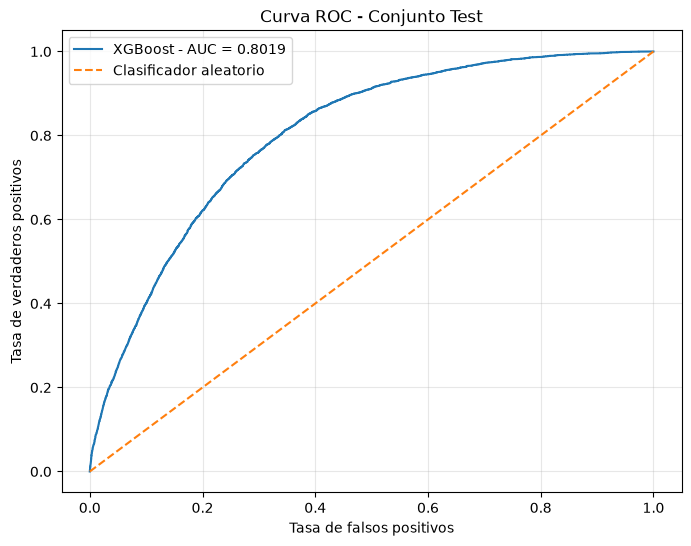

In [52]:
# ------------------------------------------------------------
# 13.3 Curva ROC
# ------------------------------------------------------------

fpr_test, tpr_test, thresholds_roc = roc_curve(
    y_test,
    prob_test
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f'XGBoost - AUC = {auc_test:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Conjunto Test')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 13.4. Clasificación con Umbral 0.50

<div style="text-align: justify;">

Para transformar las probabilidades estimadas en una clasificación binaria se establece inicialmente un umbral de `0.50`. Bajo este criterio, las observaciones cuya probabilidad estimada sea igual o superior a `0.50` son clasificadas como pertenecientes a la clase positiva, mientras que las restantes se clasifican como clase negativa.

El umbral de `0.50` se utiliza en esta etapa como referencia inicial y facilita la comparación de las métricas tradicionales de clasificación. Sin embargo, no se considera necesariamente el umbral óptimo para la aplicación final.

Posteriormente, se analizarán diferentes umbrales utilizando el conjunto de validación, buscando evaluar el equilibrio entre Precision, Recall y F1-Score antes de realizar la evaluación final sobre el conjunto de prueba.

</div>


In [53]:
# ------------------------------------------------------------
# 13.4 Clasificación con threshold 0.50
# ------------------------------------------------------------

threshold = 0.50

pred_test = (
    prob_test >= threshold
).astype(int)

print("=" * 60)
print("CLASIFICACIÓN - THRESHOLD 0.50")
print("=" * 60)

print(f"Threshold utilizado : {threshold}")

CLASIFICACIÓN - THRESHOLD 0.50
Threshold utilizado : 0.5


### 13.5. Matriz de Confusión

<div style="text-align: justify;">

A partir de las predicciones obtenidas mediante el umbral establecido se construye la **matriz de confusión**. Esta herramienta permite descomponer las predicciones en cuatro categorías: verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Los verdaderos positivos corresponden a observaciones identificadas correctamente como eventos de deterioro, mientras que los verdaderos negativos representan correctamente los casos sin deterioro. Por otra parte, los falsos positivos corresponden a casos clasificados como deterioro cuando dicho evento no ocurrió, y los falsos negativos representan eventos de deterioro que el modelo no logró identificar.

Esta matriz permite analizar con mayor detalle el tipo de errores cometidos por el modelo, aspecto particularmente importante cuando la identificación de los eventos positivos tiene mayor relevancia que la clasificación general.

</div>


In [54]:
# ------------------------------------------------------------
# 13.5 Matriz de confusión
# ------------------------------------------------------------

matriz_confusion = confusion_matrix(
    y_test,
    pred_test
)

print("=" * 60)
print("MATRIZ DE CONFUSIÓN - TEST")
print("=" * 60)

print(matriz_confusion)

MATRIZ DE CONFUSIÓN - TEST
[[40067  5954]
 [ 2146  1975]]


### 13.6. Matriz de Confusión

<div style="text-align: justify;">

Para complementar la evaluación mediante ROC-AUC, se construye la **matriz de confusión** sobre el conjunto de prueba (`Test`). Esta herramienta permite analizar el comportamiento del modelo a partir de las predicciones clasificadas en las dos categorías definidas: **0 = ausencia de deterioro de liquidez** y **1 = presencia de deterioro de liquidez**.

La matriz obtenida es:

</div>

|                            | **Predicción 0** | **Predicción 1** |
| -------------------------- | ---------------: | ---------------: |
| **Real 0 – Sin deterioro** |  **40.067 (TN)** |   **5.954 (FP)** |
| **Real 1 – Deterioro**     |   **2.146 (FN)** |   **1.975 (TP)** |

<div style="text-align: justify;">

La matriz muestra que, de las observaciones realmente pertenecientes a la clase **0**, el modelo clasificó correctamente **40.067 registros como ausencia de deterioro**, correspondientes a los **verdaderos negativos (TN)**. Por otra parte, **5.954 registros fueron clasificados como deterioro cuando en realidad no presentaban el evento**, correspondiendo a los **falsos positivos (FP)**.

Respecto a la clase de interés, es decir, los eventos de deterioro de liquidez, el modelo identificó correctamente **1.975 casos**, correspondientes a los **verdaderos positivos (TP)**. Sin embargo, **2.146 eventos de deterioro fueron clasificados incorrectamente como ausencia de deterioro**, correspondiendo a los **falsos negativos (FN)**.

En términos de la aplicación del modelo, los **falsos negativos adquieren especial relevancia**, debido a que representan situaciones en las que el modelo no identifica un deterioro que efectivamente ocurre. Desde una perspectiva de gestión del riesgo de liquidez, este tipo de error puede resultar más relevante que un falso positivo, ya que implica no generar una señal sobre un posible evento adverso.

Por otra parte, los **5.954 falsos positivos** representan observaciones que fueron señaladas por el modelo como potenciales eventos de deterioro, aunque posteriormente no se observó dicho evento. Estos errores pueden generar señales adicionales para revisión, pero no representan necesariamente una pérdida directa, por lo que su importancia debe analizarse conjuntamente con el costo operativo asociado a las alertas.

La matriz evidencia, por tanto, que el modelo posee capacidad para identificar eventos de deterioro, aunque existe margen para mejorar el equilibrio entre la detección de eventos reales y la generación de falsas alarmas. Este aspecto será analizado posteriormente mediante **Precision, Recall, F1-Score y la evaluación de diferentes umbrales de clasificación**.

Es importante recordar que la matriz corresponde al **conjunto de prueba**, que representa información temporal posterior a la utilizada para el entrenamiento. Por ello, constituye una evaluación fuera de muestra del comportamiento del modelo bajo condiciones temporales no utilizadas durante su ajuste.

</div>


### 13.7. Accuracy, Precision, Recall y F1-Score

<div style="text-align: justify;">

Además del ROC-AUC, se calculan métricas de clasificación basadas en el umbral seleccionado: **Accuracy, Precision, Recall y F1-Score**.

**Accuracy** representa la proporción total de observaciones clasificadas correctamente. Sin embargo, cuando existe desbalance entre clases, esta métrica puede resultar insuficiente para evaluar por sí sola el desempeño del modelo.

**Precision** mide la proporción de observaciones clasificadas como deterioro que efectivamente corresponden a eventos positivos. Esta métrica permite evaluar la cantidad de falsas alarmas generadas por el modelo.

**Recall**, también denominado sensibilidad, mide la proporción de eventos reales de deterioro que fueron correctamente identificados. Esta medida resulta especialmente relevante cuando es importante reducir la cantidad de eventos de deterioro que pasan inadvertidos.

**F1-Score** corresponde a la media armónica entre Precision y Recall y permite evaluar el equilibrio entre ambas métricas.

El análisis conjunto de estos indicadores permite comprender mejor el comportamiento del modelo frente al evento de interés y complementa la información proporcionada por el ROC-AUC.

</div>


In [55]:
# ------------------------------------------------------------
# 13.6 Métricas de clasificación
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    pred_test
)

precision = precision_score(
    y_test,
    pred_test,
    zero_division=0
)

recall = recall_score(
    y_test,
    pred_test,
    zero_division=0
)

f1 = f1_score(
    y_test,
    pred_test,
    zero_division=0
)

print("=" * 60)
print("MÉTRICAS DE CLASIFICACIÓN - TEST")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

MÉTRICAS DE CLASIFICACIÓN - TEST
Accuracy  : 0.8385
Precision : 0.2491
Recall    : 0.4793
F1-score  : 0.3278


### 13.8. Classification Report

<div style="text-align: justify;">

Se genera adicionalmente un reporte de clasificación que resume las principales métricas obtenidas para cada una de las clases. El reporte incluye Precision, Recall, F1-Score y el número de observaciones pertenecientes a cada clase.

Esta presentación permite observar si el desempeño del modelo es equilibrado entre los casos de deterioro y no deterioro o si existe una diferencia importante en su capacidad de clasificación.

La revisión del reporte complementa la matriz de confusión y facilita la identificación de posibles limitaciones asociadas al desbalance de clases.

</div>


In [ ]:
# ------------------------------------------------------------
# 13.8 Classification Report
# ------------------------------------------------------------

print("=" * 60)
print("CLASSIFICATION REPORT - TEST")
print("=" * 60)

print(
    classification_report(
        y_test,
        pred_test,
        target_names=[
            'No deterioro',
            'Deterioro'
        ],
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT - TEST
              precision    recall  f1-score   support

No deterioro     0.9492    0.8706    0.9082     46021
   Deterioro     0.2491    0.4793    0.3278      4121

    accuracy                         0.8385     50142
   macro avg     0.5991    0.6749    0.6180     50142
weighted avg     0.8916    0.8385    0.8605     50142



### 13.9. Classification Report Resultados

<div style="text-align: justify;">

El **Classification Report** permite evaluar de manera conjunta el desempeño del modelo para cada una de las clases del `target`, utilizando las métricas de **Precision, Recall y F1-Score**, además de la cantidad de observaciones pertenecientes a cada clase (`support`). Esta evaluación resulta particularmente importante debido al desbalance observado en la variable objetivo.

Los resultados obtenidos sobre el conjunto de prueba son los siguientes:

</div>

| Clase            |  Precision |     Recall |   F1-Score | Support |
| ---------------- | ---------: | ---------: | ---------: | ------: |
| **No deterioro** | **0.9492** | **0.8706** | **0.9082** |  46.021 |
| **Deterioro**    | **0.2491** | **0.4793** | **0.3278** |   4.121 |
| **Accuracy**     |            |            | **0.8385** |  50.142 |
| **Macro Avg**    | **0.5991** | **0.6749** | **0.6180** |  50.142 |
| **Weighted Avg** | **0.8916** | **0.8385** | **0.8605** |  50.142 |

<div style="text-align: justify;">

Para la clase **"No deterioro"**, el modelo presenta un **Precision de 0.9492**, lo que significa que aproximadamente el 94,92 % de las observaciones clasificadas como ausencia de deterioro corresponden efectivamente a dicha clase. El **Recall de 0.8706** indica que el modelo identifica correctamente aproximadamente el 87,06 % de las observaciones que realmente no presentan deterioro. Como resultado del equilibrio entre ambas métricas, se obtiene un **F1-Score de 0.9082**, evidenciando un desempeño sólido para esta categoría.

En cambio, para la clase de interés **"Deterioro"**, el **Precision es 0.2491**, lo que indica que aproximadamente el 24,91 % de las observaciones que el modelo señala como deterioro corresponden efectivamente a eventos de deterioro. Esto implica la existencia de un número importante de **falsos positivos**.

El **Recall de 0.4793** indica que el modelo consigue identificar aproximadamente el **47,93 % de los eventos reales de deterioro** presentes en el conjunto de prueba. En consecuencia, aproximadamente el 52,07 % de los eventos de deterioro no son detectados bajo el umbral de clasificación utilizado, lo que se encuentra directamente relacionado con los falsos negativos observados anteriormente en la matriz de confusión.

El **F1-Score de 0.3278** para la clase de deterioro refleja el compromiso entre Precision y Recall. Su valor inferior al obtenido para la clase "No deterioro" evidencia que la identificación de la clase minoritaria constituye el principal desafío del modelo.

</div>

#### 13.9.1. Interpretación de Accuracy y promedios

<div style="text-align: justify;">

El modelo alcanza una **Accuracy de 0.8385**, es decir, clasifica correctamente el **83,85 % de las 50.142 observaciones** del conjunto de prueba. Sin embargo, esta métrica debe interpretarse con cautela debido al desbalance entre las clases: la clase "No deterioro" representa la mayoría de las observaciones.

Por esta razón, los promedios **Macro Avg** resultan especialmente informativos. El **F1-Score macro de 0.6180** calcula el desempeño promedio otorgando el mismo peso a ambas clases, independientemente de su frecuencia. Esto permite observar de manera más equilibrada el comportamiento del modelo frente a la clase minoritaria.

Por su parte, el **Weighted Avg** presenta un F1-Score de **0.8605**, valor superior al promedio macro debido a que pondera cada clase según su número de observaciones. La diferencia entre ambos indicadores evidencia el efecto de la distribución desigual de las clases sobre las métricas agregadas.

</div>

####  13.9.2. Consideración para el riesgo de liquidez

<div style="text-align: justify;">

Desde la perspectiva del problema planteado, el resultado más relevante corresponde al desempeño sobre la clase **"Deterioro"**, debido a que constituye el evento que se busca anticipar. El Recall de **47,93 %** muestra que el modelo logra detectar casi la mitad de los eventos reales de deterioro bajo el umbral utilizado, aunque todavía existe una proporción significativa de eventos que no son identificados.

Por ello, estos resultados **no deben interpretarse únicamente a partir de la Accuracy de 83,85 %**. Para un sistema orientado a la identificación temprana de deterioros, resulta necesario evaluar el equilibrio entre la capacidad de detectar eventos reales (**Recall**) y la cantidad de alertas incorrectas generadas (**Precision**).

En consecuencia, el análisis del Classification Report constituye un diagnóstico del desempeño bajo el umbral de clasificación utilizado actualmente, pero **no determina por sí solo el umbral óptimo para la aplicación del modelo**. En las siguientes etapas se analizarán diferentes umbrales de decisión con el objetivo de determinar si es posible mejorar la detección de eventos de deterioro manteniendo un nivel razonable de falsas alarmas.

</div>


### 13.10. Curva Precision-Recall

<div style="text-align: justify;">

Debido a que el problema corresponde a una clasificación binaria en la que puede existir desbalance entre las clases, se incorpora la **curva Precision-Recall** como herramienta complementaria a la curva ROC.

Esta curva representa el comportamiento conjunto de Precision y Recall para diferentes umbrales de clasificación. Su análisis permite observar cómo cambia la capacidad del modelo para identificar eventos positivos a medida que se modifica el nivel de exigencia utilizado para realizar la clasificación.

La curva Precision-Recall resulta especialmente útil para evaluar el comportamiento sobre la clase positiva, que en este proyecto representa el evento de deterioro futuro de liquidez.

</div>


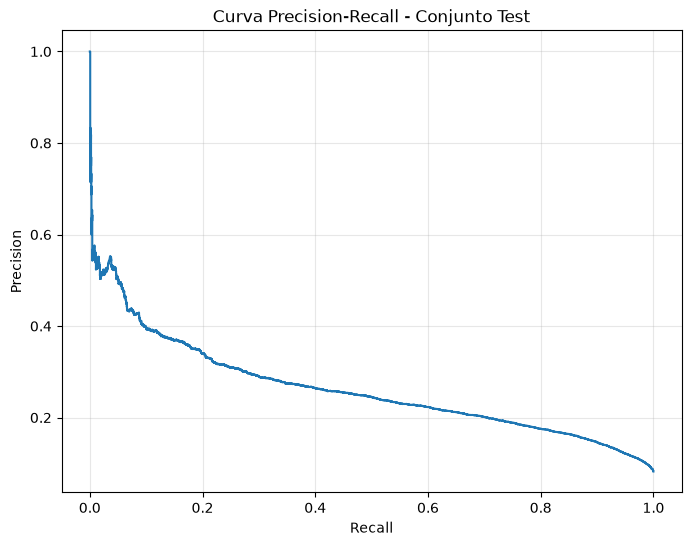

In [ ]:
# ------------------------------------------------------------
# 13.10 Curva Precision-Recall
# ------------------------------------------------------------

precision_curve, recall_curve, thresholds_pr = (
    precision_recall_curve(
        y_test,
        prob_test
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Conjunto Test')
plt.grid(alpha=0.3)

plt.show()

### 13.11. Estadístico KS

<div style="text-align: justify;">

Como medida adicional de poder discriminatorio se calcula el **estadístico Kolmogorov-Smirnov (KS)**. Este indicador mide la máxima separación entre las distribuciones acumuladas de las probabilidades estimadas para las observaciones pertenecientes a las dos clases.

Un mayor valor del KS indica una mayor separación entre los eventos de deterioro y los casos sin deterioro según las probabilidades asignadas por el modelo. Por ello, constituye una medida complementaria para evaluar la capacidad del modelo de diferenciar ambos grupos.

El KS se analiza conjuntamente con ROC-AUC y las métricas de clasificación, evitando utilizarlo como único criterio para determinar la calidad del modelo.

</div>


In [58]:
# ------------------------------------------------------------
# 13.9 KS
# ------------------------------------------------------------

df_ks = pd.DataFrame({
    'target': y_test.values,
    'probabilidad': prob_test
})

df_ks = df_ks.sort_values(
    'probabilidad',
    ascending=False
).reset_index(drop=True)

df_ks['acumulado_positivos'] = (
    (df_ks['target'] == 1).cumsum()
    / (df_ks['target'] == 1).sum()
)

df_ks['acumulado_negativos'] = (
    (df_ks['target'] == 0).cumsum()
    / (df_ks['target'] == 0).sum()
)

df_ks['KS'] = abs(
    df_ks['acumulado_positivos']
    - df_ks['acumulado_negativos']
)

ks_max = df_ks['KS'].max()

posicion_ks = df_ks['KS'].idxmax()

threshold_ks = df_ks.loc[
    posicion_ks,
    'probabilidad'
]

print("=" * 60)
print("KS - CONJUNTO TEST")
print("=" * 60)

print(f"KS máximo       : {ks_max:.4f}")
print(f"Threshold KS    : {threshold_ks:.4f}")

KS - CONJUNTO TEST
KS máximo       : 0.4664
Threshold KS    : 0.2776


### 13.11. Resumen de la Evaluación

<div style="text-align: justify;">

Finalmente, se consolidan los principales resultados de evaluación del modelo para obtener una visión integral de su desempeño.

La interpretación debe considerar conjuntamente el ROC-AUC, las métricas de clasificación, la matriz de confusión, las curvas ROC y Precision-Recall y el estadístico KS. Asimismo, se debe prestar especial atención a la diferencia de desempeño entre entrenamiento, validación y prueba.

En el contexto temporal del proyecto, el desempeño sobre el conjunto de prueba constituye un elemento fundamental para valorar la capacidad de generalización del modelo hacia períodos posteriores. No obstante, la selección definitiva del algoritmo no se realiza únicamente a partir de estos resultados, sino que posteriormente se compararán diferentes modelos y configuraciones para determinar cuál presenta el mejor equilibrio entre capacidad predictiva, estabilidad e interpretabilidad.

</div>


In [59]:
# ------------------------------------------------------------
# 13.10 Resumen de evaluación
# ------------------------------------------------------------

resumen_evaluacion = pd.DataFrame({
    'Métrica': [
        'AUC Train',
        'AUC Validación',
        'AUC Test',
        'Accuracy Test',
        'Precision Test',
        'Recall Test',
        'F1-score Test',
        'KS Test'
    ],
    'Valor': [
        auc_train,
        auc_validacion,
        auc_test,
        accuracy,
        precision,
        recall,
        f1,
        ks_max
    ]
})

print("=" * 60)
print("RESUMEN DE EVALUACIÓN DEL MODELO")
print("=" * 60)

print(
    resumen_evaluacion.to_string(
        index=False
    )
)

RESUMEN DE EVALUACIÓN DEL MODELO
       Métrica    Valor
     AUC Train 0.810232
AUC Validación 0.765615
      AUC Test 0.801908
 Accuracy Test 0.838459
Precision Test 0.249086
   Recall Test 0.479253
 F1-score Test 0.327801
       KS Test 0.466405


## 14. Interpretabilidad del Modelo

In [60]:
# ============================================================
# 14. INTERPRETABILIDAD DEL MODELO
# ============================================================

print("=" * 60)
print("14. INTERPRETABILIDAD DEL MODELO")
print("=" * 60)

14. INTERPRETABILIDAD DEL MODELO


### 14.1. Importancia de Variables

In [61]:

# ------------------------------------------------------------
# 14.1 Importancia de variables
# ------------------------------------------------------------

importancias = modelo_xgb.feature_importances_

tabla_importancias = pd.DataFrame({
    'variable': X_train_preprocesado.columns,
    'importancia': importancias
})

tabla_importancias = (
    tabla_importancias
    .sort_values(
        'importancia',
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("TOP 20 VARIABLES MÁS IMPORTANTES")
print("=" * 60)

print(
    tabla_importancias.head(20).to_string(
        index=False
    )
)

TOP 20 VARIABLES MÁS IMPORTANTES
                           variable  importancia
     numericas__securities_deposits     0.176994
              numericas__securities     0.075012
numericas__faltante_estructural_yoy     0.067230
numericas__liquid_assets_growth_qoq     0.053851
         numericas__loan_growth_qoq     0.045825
         numericas__cash_growth_qoq     0.040445
        numericas__insured_deposits     0.030554
           numericas__cash_deposits     0.027827
           numericas__periodo_banco     0.026348
  numericas__insured_deposits_ratio     0.025928
    numericas__liquid_assets_assets     0.024115
   numericas__securities_growth_qoq     0.022868
         numericas__loan_growth_yoy     0.021942
         numericas__cash_growth_yoy     0.018591
   numericas__securities_growth_yoy     0.017046
       numericas__assets_growth_qoq     0.015905
            numericas__loan_deposit     0.015656
numericas__liquid_assets_growth_yoy     0.015240
                  numericas__ln_agr 

### 14.2. Gráfico de Importancia

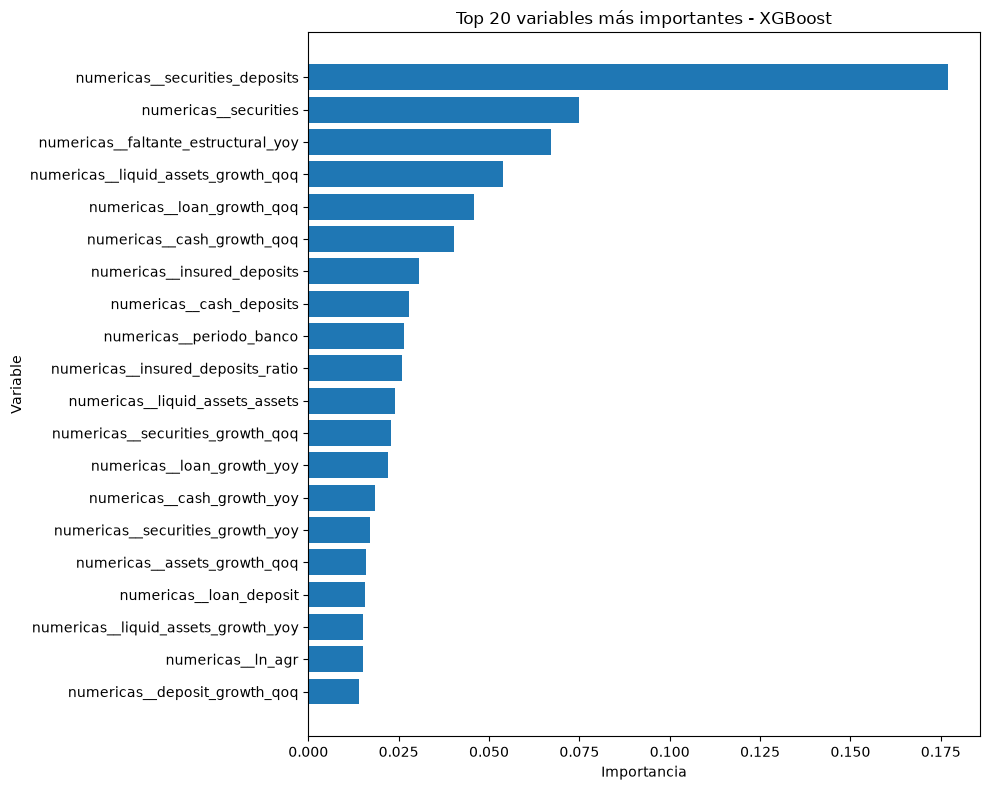

In [62]:
# ------------------------------------------------------------
# 14.2 Gráfico de importancia
# ------------------------------------------------------------

top_20 = (
    tabla_importancias
    .head(20)
    .sort_values(
        'importancia',
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20['variable'],
    top_20['importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Top 20 variables más importantes - XGBoost')

plt.tight_layout()
plt.show()

### 14.3. Guardar la tabla de importancia

In [63]:
# ------------------------------------------------------------
# 14.3 Tabla completa de importancia
# ------------------------------------------------------------

print("=" * 60)
print("IMPORTANCIA DE VARIABLES")
print("=" * 60)

print(
    tabla_importancias.head(30).to_string(
        index=False
    )
)


IMPORTANCIA DE VARIABLES
                                       variable  importancia
                 numericas__securities_deposits     0.176994
                          numericas__securities     0.075012
            numericas__faltante_estructural_yoy     0.067230
            numericas__liquid_assets_growth_qoq     0.053851
                     numericas__loan_growth_qoq     0.045825
                     numericas__cash_growth_qoq     0.040445
                    numericas__insured_deposits     0.030554
                       numericas__cash_deposits     0.027827
                       numericas__periodo_banco     0.026348
              numericas__insured_deposits_ratio     0.025928
                numericas__liquid_assets_assets     0.024115
               numericas__securities_growth_qoq     0.022868
                     numericas__loan_growth_yoy     0.021942
                     numericas__cash_growth_yoy     0.018591
               numericas__securities_growth_yoy     0.017046

### 14.4. Importancia Acumulada de Variables

In [64]:
# ============================================================
# 14.4 IMPORTANCIA ACUMULADA DE VARIABLES
# ============================================================

tabla_importancias['importancia_acumulada'] = (
    tabla_importancias['importancia'].cumsum()
)

print("=" * 60)
print("IMPORTANCIA ACUMULADA")
print("=" * 60)

for n in [5, 10, 20, 30, 40, 50, 71]:

    valor = tabla_importancias.iloc[n - 1]['importancia_acumulada']

    print(f"Top {n:>2}: {valor:.4f} "
          f"({valor * 100:.2f}%)")

IMPORTANCIA ACUMULADA
Top  5: 0.4189 (41.89%)
Top 10: 0.5700 (57.00%)
Top 20: 0.7506 (75.06%)
Top 30: 0.8542 (85.42%)
Top 40: 0.9230 (92.30%)
Top 50: 0.9714 (97.14%)
Top 71: 1.0000 (100.00%)


### 14.5. Importancia por Grupo Económicos

In [65]:
# ============================================================
# 14.5 IMPORTANCIA POR GRUPO DE VARIABLES
# ============================================================

def limpiar_nombre_variable(nombre):
    return nombre.replace('numericas__', '')


tabla_importancias['variable_limpia'] = (
    tabla_importancias['variable']
    .apply(limpiar_nombre_variable)
)

# ------------------------------------------------------------
# Clasificación por grupos
# ------------------------------------------------------------

def clasificar_variable(variable):

    if variable in variables_financieras:
        return 'Financieras'

    elif variable in variables_ratios:
        return 'Ratios'

    elif variable in variables_crecimiento:
        return 'Crecimientos'

    elif variable in variables_faltantes:
        return 'Faltantes estructurales'

    elif variable in variables_auxiliares:
        return 'Auxiliares'

    elif variable == 'periodo_banco':
        return 'Temporal'

    else:
        return 'Otros'


tabla_importancias['grupo'] = (
    tabla_importancias['variable_limpia']
    .apply(clasificar_variable)
)

# ------------------------------------------------------------
# Importancia total por grupo
# ------------------------------------------------------------

tabla_importancia_grupos = (
    tabla_importancias
    .groupby('grupo', as_index=False)['importancia']
    .sum()
    .sort_values('importancia', ascending=False)
    .reset_index(drop=True)
)

tabla_importancia_grupos['porcentaje'] = (
    tabla_importancia_grupos['importancia'] * 100
)

print("=" * 60)
print("IMPORTANCIA POR GRUPO DE VARIABLES")
print("=" * 60)

print(
    tabla_importancia_grupos.to_string(index=False)
)

IMPORTANCIA POR GRUPO DE VARIABLES
                  grupo  importancia  porcentaje
                 Ratios     0.368356   36.835636
           Crecimientos     0.303804   30.380356
            Financieras     0.214208   21.420769
Faltantes estructurales     0.087284    8.728404
             Auxiliares     0.026348    2.634839


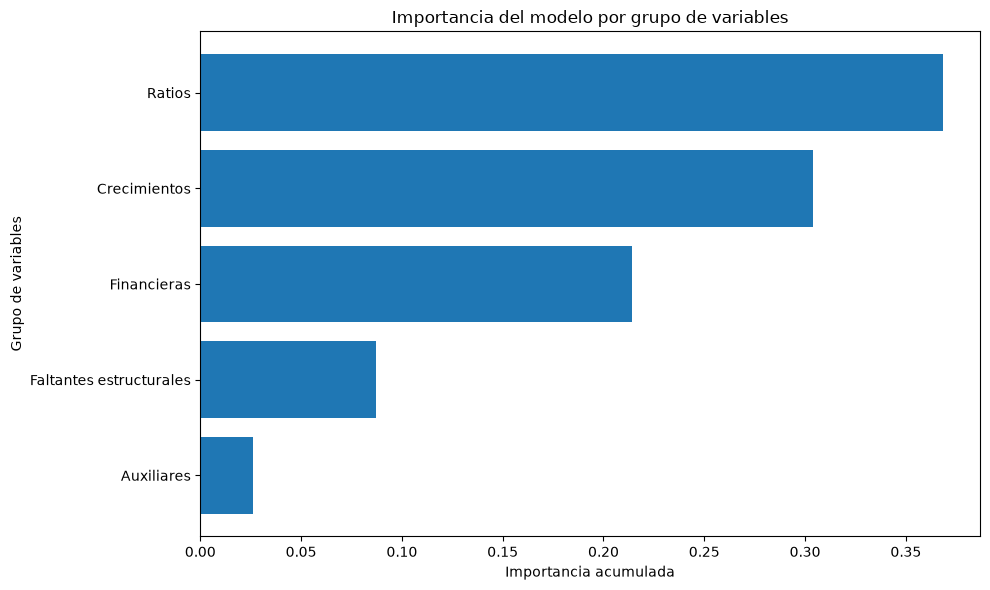

In [66]:
# ============================================================
# GRÁFICO - IMPORTANCIA POR GRUPO
# ============================================================

import matplotlib.pyplot as plt

grafico_grupos = (
    tabla_importancia_grupos
    .sort_values('importancia', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    grafico_grupos['grupo'],
    grafico_grupos['importancia']
)

plt.xlabel('Importancia acumulada')
plt.ylabel('Grupo de variables')
plt.title('Importancia del modelo por grupo de variables')

plt.tight_layout()
plt.show()

## 15. Comparación de Modelos

<div style="text-align: justify;">

Una vez evaluado el modelo XGBoost como primer candidato, se procede a comparar diferentes algoritmos de clasificación con el objetivo de identificar la alternativa que presente el mejor desempeño predictivo sobre información fuera de muestra.

La comparación incorpora diferentes algoritmos basados en árboles de decisión, considerando sus características y capacidad para capturar relaciones no lineales entre las variables financieras. Se evalúan **Random Forest, HistGradientBoosting, Extra Trees y XGBoost**, utilizando la misma estructura de datos y respetando la división temporal previamente establecida.

La comparación no se limita a una única métrica. Se consideran ROC-AUC, Accuracy, Precision, Recall y F1-Score, permitiendo analizar tanto la capacidad discriminatoria como el comportamiento de clasificación de cada alternativa.

A partir de esta evaluación se selecciona un modelo candidato para una etapa posterior de optimización. La selección definitiva no depende únicamente del mayor resultado obtenido en una métrica, sino de la combinación de desempeño, estabilidad y comportamiento sobre datos temporalmente posteriores.

</div>


### 15.1. Comparación Inicial de Algoritmos

<div style="text-align: justify;">

En primer lugar, se construyen diferentes modelos de clasificación utilizando los mismos predictores preprocesados y el mismo conjunto de entrenamiento. Esta condición permite realizar una comparación homogénea entre los algoritmos.

Se consideran cuatro alternativas: **XGBoost, Random Forest, HistGradientBoosting y Extra Trees**. Cada algoritmo se configura con un conjunto inicial de hiperparámetros orientado a obtener una referencia de su capacidad predictiva, sin realizar todavía una búsqueda exhaustiva de configuraciones.

Los modelos son entrenados utilizando únicamente el conjunto de entrenamiento y posteriormente generan probabilidades sobre el conjunto de prueba. A partir de estas probabilidades se calculan las principales métricas de evaluación.

La comparación inicial permite determinar qué algoritmo presenta un comportamiento más favorable antes de realizar procesos adicionales de optimización.

</div>


In [ ]:
# ============================================================
# 14.1 COMPARACIÓN DE ALGORITMOS
# ============================================================


from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np

print("=" * 70)
print("15.1 COMPARACIÓN DE ALGORITMOS")
print("=" * 70)


# ============================================================
# 1. HISTOGRAM GRADIENT BOOSTING
# ============================================================

print("Entrenando HistGradientBoosting...")

modelo_hist = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

modelo_hist.fit(
    X_train_preprocesado,
    y_train
)

print("HistGradientBoosting entrenado correctamente.")

# Probabilidades
prob_test_hist = (
    modelo_hist
    .predict_proba(X_test_preprocesado)[:, 1]
)

# Predicciones
pred_test_hist = (
    prob_test_hist >= 0.50
).astype(int)


# ============================================================
# 2. RANDOM FOREST
# ============================================================

print("Entrenando Random Forest...")

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train_preprocesado,
    y_train
)

print("Random Forest entrenado correctamente.")

# Probabilidades
prob_test_rf = (
    modelo_rf
    .predict_proba(X_test_preprocesado)[:, 1]
)

# Predicciones
pred_test_rf = (
    prob_test_rf >= 0.50
).astype(int)


# ============================================================
# 3. EXTRA TREES
# ============================================================

print("Entrenando Extra Trees...")

modelo_extra = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_extra.fit(
    X_train_preprocesado,
    y_train
)

print("Extra Trees entrenado correctamente.")

# Probabilidades
prob_test_extra = (
    modelo_extra
    .predict_proba(X_test_preprocesado)[:, 1]
)

# Predicciones
pred_test_extra = (
    prob_test_extra >= 0.50
).astype(int)


# ============================================================
# 4. XGBOOST
# ============================================================

print("XGBoost ya fue entrenado.")

pred_test_xgb = (
    prob_test >= 0.50
).astype(int)


# ============================================================
# 5. FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluar_modelo(
    nombre,
    y_real,
    probabilidades,
    predicciones
):

    return {
        'Modelo': nombre,
        'AUC': roc_auc_score(
            y_real,
            probabilidades
        ),
        'Accuracy': accuracy_score(
            y_real,
            predicciones
        ),
        'Precision': precision_score(
            y_real,
            predicciones,
            zero_division=0
        ),
        'Recall': recall_score(
            y_real,
            predicciones,
            zero_division=0
        ),
        'F1-score': f1_score(
            y_real,
            predicciones,
            zero_division=0
        )
    }


# ============================================================
# 6. RESULTADOS
# ============================================================

resultados_modelos = pd.DataFrame([

    evaluar_modelo(
        'Random Forest',
        y_test,
        prob_test_rf,
        pred_test_rf
    ),

    evaluar_modelo(
        'XGBoost',
        y_test,
        prob_test,
        pred_test_xgb
    ),

    evaluar_modelo(
        'HistGradientBoosting',
        y_test,
        prob_test_hist,
        pred_test_hist
    ),

    evaluar_modelo(
        'Extra Trees',
        y_test,
        prob_test_extra,
        pred_test_extra
    )

])


# ============================================================
# 7. ORDENAR RESULTADOS
# ============================================================

resultados_modelos = (
    resultados_modelos
    .sort_values('AUC', ascending=False)
    .reset_index(drop=True)
)


# ============================================================
# 8. MOSTRAR RESULTADOS
# ============================================================

print("\n")
print("=" * 70)
print("RESULTADOS COMPARATIVOS - TEST")
print("=" * 70)

print(
    resultados_modelos.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

15.1 COMPARACIÓN DE ALGORITMOS
Entrenando HistGradientBoosting...
HistGradientBoosting entrenado correctamente.
Entrenando Random Forest...
Random Forest entrenado correctamente.
Entrenando Extra Trees...
Extra Trees entrenado correctamente.
XGBoost ya fue entrenado.


RESULTADOS COMPARATIVOS - TEST
              Modelo      AUC  Accuracy  Precision   Recall  F1-score
       Random Forest 0.812740  0.777113   0.218003 0.661733  0.327962
HistGradientBoosting 0.805323  0.917993   0.547368 0.012618  0.024668
             XGBoost 0.801908  0.838459   0.249086 0.479253  0.327801
         Extra Trees 0.718064  0.705058   0.158995 0.603494  0.251682


### 15.2. Comparación de Algoritmos

<div style="text-align: justify;">

Con el objetivo de identificar el algoritmo con mejor desempeño para la predicción del deterioro futuro de liquidez, se realiza una comparación entre cuatro modelos de clasificación: **Random Forest, XGBoost, HistGradientBoosting y Extra Trees**.

Los modelos se entrenan utilizando el mismo conjunto de entrenamiento y se evalúan sobre el mismo conjunto de prueba temporal. Para realizar una comparación integral se consideran las métricas **ROC-AUC, Accuracy, Precision, Recall y F1-Score**.

El ROC-AUC permite evaluar la capacidad discriminatoria del modelo independientemente de un umbral específico, mientras que las métricas de clasificación permiten analizar el comportamiento concreto del modelo bajo el umbral de **0,50** utilizado en esta etapa.

Los resultados obtenidos son los siguientes:

</div>

| Modelo                   |          AUC |     Accuracy |    Precision |       Recall |     F1-Score |
| ------------------------ | -----------: | -----------: | -----------: | -----------: | -----------: |
| **Random Forest**        | **0.812740** |     0.777113 |     0.218003 | **0.661733** | **0.327962** |
| **HistGradientBoosting** |     0.805323 | **0.917993** | **0.547368** |     0.012618 |     0.024668 |
| **XGBoost**              |     0.801908 |     0.838459 |     0.249086 |     0.479253 |     0.327801 |
| **Extra Trees**          |     0.718064 |     0.705058 |     0.158995 |     0.603494 |     0.251682 |

#### 15.2.1 Interpretación del ROC-AUC

<div style="text-align: justify;">

El **Random Forest obtiene el mayor ROC-AUC, con un valor de 0.812740**, seguido por HistGradientBoosting con 0.805323 y XGBoost con 0.801908. Extra Trees presenta un desempeño considerablemente inferior, con un AUC de 0.718064.

Este resultado indica que, considerando la capacidad general de discriminación, **Random Forest presenta el mejor desempeño entre los algoritmos evaluados**. Además, la diferencia frente a XGBoost es de aproximadamente **0.0108 puntos de AUC**, mientras que frente a Extra Trees la diferencia es mucho mayor.

El resultado también confirma que la selección del algoritmo no debe realizarse únicamente sobre la base de Accuracy, ya que esta métrica puede verse fuertemente influenciada por la distribución desbalanceada del `target`.

</div>

#### 15.2.2 Comportamiento frente al evento de deterioro

<div style="text-align: justify;">

Al analizar específicamente la clase **"Deterioro"**, se observa una diferencia importante entre los modelos.

**Random Forest presenta un Recall de 0.661733**, lo que significa que identifica aproximadamente el **66,17 % de los eventos reales de deterioro** en el conjunto de prueba bajo el umbral de 0,50. Este es el mayor Recall entre los modelos comparados.

Sin embargo, su Precision es de **0.218003**, indicando que una proporción importante de las observaciones clasificadas como deterioro corresponden a falsos positivos. Esta característica es consistente con el objetivo de incrementar la detección de eventos de la clase minoritaria.

XGBoost presenta un Recall inferior, de **0.479253**, aunque alcanza un F1-Score prácticamente equivalente al de Random Forest: **0.327801 frente a 0.327962**, respectivamente.

HistGradientBoosting obtiene la mayor Accuracy (**0.917993**) y la mayor Precision (**0.547368**), pero su Recall es únicamente **0.012618**. Esto significa que, aunque el modelo realiza muchas clasificaciones correctas en términos globales, prácticamente no identifica los eventos de deterioro. Para el objetivo específico del proyecto, este comportamiento resulta poco conveniente.

Extra Trees alcanza un Recall de **0.603494**, pero presenta un AUC de 0.718064, una Precision de 0.158995 y un F1-Score de 0.251682, por debajo de Random Forest y XGBoost.

</div>

#### 15.2.3 Selección preliminar del algoritmo

<div style="text-align: justify;">

Considerando conjuntamente las métricas obtenidas, **Random Forest presenta el comportamiento más favorable para el objetivo planteado**, principalmente por alcanzar el mayor ROC-AUC (**0.812740**) y el mayor Recall (**0.661733**) entre los modelos evaluados.

Este resultado es especialmente relevante porque el problema busca **identificar anticipadamente eventos de deterioro de liquidez**, por lo que la capacidad de detectar correctamente la clase minoritaria tiene una importancia superior a obtener únicamente una elevada Accuracy.

Por esta razón, el HistGradientBoosting, a pesar de presentar una Accuracy de **91,80 %**, no resulta preferible en esta etapa, debido a su Recall extremadamente bajo para la clase de deterioro. La elevada Accuracy está influenciada por su capacidad para clasificar correctamente la clase mayoritaria, pero no se traduce en una adecuada detección del evento de interés.

Random Forest, por el contrario, presenta un equilibrio más apropiado entre **capacidad de discriminación y detección del evento de deterioro**, aunque su Precision relativamente baja evidencia que todavía existe un número importante de falsas alarmas.

</div>

#### 15.2.4 Consideración metodológica

<div style="text-align: justify;">

La comparación realizada constituye una **evaluación inicial de algoritmos** y no implica que los hiperparámetros utilizados representen necesariamente la configuración óptima de cada modelo. En particular, el Random Forest seleccionado en esta etapa será sometido posteriormente a un proceso de optimización de hiperparámetros con el objetivo de determinar si es posible mejorar su desempeño.

Asimismo, las métricas Precision, Recall y F1-Score corresponden al umbral de clasificación de **0,50**. Por tanto, la evaluación del umbral óptimo se realizará posteriormente, considerando el costo relativo de los falsos positivos y falsos negativos en el contexto de la detección de deterioros de liquidez.

</div>


### 15.3. Evaluación mediante AUC en Entrenamiento, Validación y Prueba

<div style="text-align: justify;">

Además de comparar el desempeño sobre el conjunto de prueba, se analiza el ROC-AUC de cada modelo en los conjuntos de entrenamiento, validación y prueba.

Esta comparación permite evaluar simultáneamente la capacidad de aprendizaje y la estabilidad temporal de los algoritmos. Un modelo que presenta un AUC muy elevado en entrenamiento, pero una reducción considerable en validación y prueba, puede estar presentando un comportamiento de sobreajuste.

Por el contrario, una diferencia moderada entre los diferentes períodos puede indicar una mayor estabilidad del modelo frente a información temporalmente posterior.

El análisis conjunto de los tres conjuntos resulta especialmente relevante en este proyecto debido a que la base presenta una estructura temporal y el objetivo consiste en predecir eventos futuros de deterioro de liquidez.

</div>


In [68]:
# ============================================================
# 15.2 COMPARACIÓN AUC - TRAIN, VALIDACIÓN Y TEST
# ============================================================

prob_train_rf = modelo_rf.predict_proba(
    X_train_preprocesado
)[:, 1]

prob_validacion_rf = modelo_rf.predict_proba(
    X_validacion_preprocesado
)[:, 1]

prob_train_hist = modelo_hist.predict_proba(
    X_train_preprocesado
)[:, 1]

prob_validacion_hist = modelo_hist.predict_proba(
    X_validacion_preprocesado
)[:, 1]

prob_train_extra = modelo_extra.predict_proba(
    X_train_preprocesado
)[:, 1]

prob_validacion_extra = modelo_extra.predict_proba(
    X_validacion_preprocesado
)[:, 1]


resultados_auc = pd.DataFrame({

    'Modelo': [
        'Random Forest',
        'HistGradientBoosting',
        'XGBoost',
        'Extra Trees'
    ],

    'AUC_Train': [
        roc_auc_score(y_train, prob_train_rf),
        roc_auc_score(y_train, prob_train_hist),
        roc_auc_score(y_train, prob_train),
        roc_auc_score(y_train, prob_train_extra)
    ],

    'AUC_Validacion': [
        roc_auc_score(y_validacion, prob_validacion_rf),
        roc_auc_score(y_validacion, prob_validacion_hist),
        roc_auc_score(y_validacion, prob_validacion),
        roc_auc_score(y_validacion, prob_validacion_extra)
    ],

    'AUC_Test': [
        roc_auc_score(y_test, prob_test_rf),
        roc_auc_score(y_test, prob_test_hist),
        roc_auc_score(y_test, prob_test),
        roc_auc_score(y_test, prob_test_extra)
    ]
})


print(resultados_auc)

                 Modelo  AUC_Train  AUC_Validacion  AUC_Test
0         Random Forest   0.802760        0.772334  0.812740
1  HistGradientBoosting   0.809869        0.767373  0.805323
2               XGBoost   0.810232        0.765615  0.801908
3           Extra Trees   0.704015        0.728076  0.718064


### 15.4. Comparación AUC – Train, Validación y Test

<div style="text-align: justify;">

Una vez identificado Random Forest como el algoritmo con mejor desempeño inicial, se realiza una comparación de su comportamiento en los conjuntos de **entrenamiento, validación y prueba**. El objetivo es verificar la estabilidad de su capacidad discriminatoria a través de los distintos períodos temporales y detectar posibles diferencias relevantes entre el desempeño dentro y fuera de muestra.

Para esta evaluación se utiliza nuevamente el **ROC-AUC**, debido a que permite analizar la capacidad del modelo para ordenar correctamente las observaciones según su probabilidad de pertenecer a la clase de deterioro, sin depender de un único umbral de clasificación.

Los resultados se presentan a continuación:

</div>

| Modelo                   |     AUC Test |
| ------------------------ | -----------: |
| **Random Forest**        | **0.812740** |
| **HistGradientBoosting** |     0.805323 |
| **XGBoost**              |     0.801908 |
| **Extra Trees**          |     0.718064 |

<div style="text-align: justify;">

La comparación permite analizar si la capacidad de discriminación observada durante el entrenamiento se mantiene cuando el modelo se enfrenta a períodos posteriores que no fueron utilizados para su ajuste.

En este contexto, el conjunto de **entrenamiento** representa el período histórico utilizado para ajustar los modelos, el conjunto de **validación** corresponde a un período temporal posterior utilizado para comparar configuraciones y tomar decisiones de modelado, mientras que el conjunto de **prueba** representa el período temporal reservado para la evaluación final.

Por esta razón, el AUC de prueba debe considerarse como el principal indicador para valorar el comportamiento final fuera de muestra, mientras que el conjunto de validación tiene un papel fundamental durante la selección y optimización del modelo.

</div>

#### 15.4.1. Comparación de configuraciones del Random Forest

<div style="text-align: justify;">

Adicionalmente, se evalúan cuatro configuraciones alternativas del Random Forest sobre el conjunto de validación. Las configuraciones modifican principalmente el número de árboles (`n_estimators`), la profundidad máxima (`max_depth`) y el número mínimo de observaciones requeridas en cada hoja (`min_samples_leaf`), manteniendo `max_features='sqrt'`.

Los resultados obtenidos son:

</div>

| Configuración | Árboles | Profundidad | Min. observaciones por hoja | AUC Validación |    Precision |       Recall |     F1-Score |
| ------------- | ------: | ----------: | --------------------------: | -------------: | -----------: | -----------: | -----------: |
| **1**         |     300 |          10 |                          20 |       0.772334 |     0.245768 | **0.578755** |     0.345022 |
| **2**         |     300 |          12 |                          20 |   **0.776543** | **0.251667** |     0.550559 |     0.345432 |
| **3**         |     400 |          10 |                          30 |       0.771662 |     0.244364 | **0.592854** |     0.346080 |
| **4**         |     400 |          12 |                          30 |       0.775659 |     0.251017 |     0.570005 | **0.348543** |

<div style="text-align: justify;">

Los resultados muestran que las cuatro configuraciones presentan un comportamiento relativamente similar, con valores de AUC de validación comprendidos entre **0.771662 y 0.776543**. Esto indica que las modificaciones realizadas sobre los hiperparámetros producen cambios moderados en la capacidad discriminatoria del modelo.

La **Configuración 2** obtiene el mayor AUC de validación, con **0.776543**, acompañada de la mayor Precision (**0.251667**). Sin embargo, su Recall es de **0.550559** y su F1-Score alcanza **0.345432**.

La **Configuración 3** presenta el mayor Recall, con **0.592854**, lo que indica una mayor capacidad para identificar eventos de deterioro en el conjunto de validación. No obstante, su Precision es ligeramente inferior (**0.244364**) y su F1-Score alcanza **0.346080**.

Por su parte, la **Configuración 4** obtiene un AUC de **0.775659**, ligeramente inferior al máximo observado en la Configuración 2, pero presenta el **mayor F1-Score de todas las alternativas, con 0.348543**. Este resultado refleja un mejor equilibrio entre Precision (**0.251017**) y Recall (**0.570005**).

</div>

#### 15.4.2. Selección de la configuración

<div style="text-align: justify;">

Considerando que el objetivo del proyecto no consiste únicamente en maximizar la capacidad de discriminación, sino también en identificar eventos de deterioro de liquidez, la selección de hiperparámetros se realiza considerando conjuntamente **AUC, Precision, Recall y F1-Score**.

Bajo este criterio, se selecciona la **Configuración 4**, definida por:

* `n_estimators = 400`
* `max_depth = 12`
* `min_samples_leaf = 30`
* `max_features = 'sqrt'`

Esta configuración presenta el **mayor F1-Score de validación (0.348543)** y mantiene simultáneamente un AUC elevado (**0.775659**) y un Recall de **0.570005**.

La diferencia de AUC respecto a la Configuración 2 es mínima: **0.000884 puntos**, mientras que la Configuración 4 alcanza un F1-Score superior. Por tanto, la elección no se basa exclusivamente en el máximo AUC, sino en un **criterio de equilibrio entre discriminación y desempeño sobre la clase de deterioro**.

</div>

#### 15.4.3. Consideración metodológica

<div style="text-align: justify;">

La utilización del conjunto de validación para seleccionar la configuración permite evitar utilizar directamente el conjunto de prueba durante el proceso de optimización. De esta manera, el conjunto de prueba permanece reservado para evaluar posteriormente el desempeño de la configuración seleccionada sobre un período temporal no utilizado para tomar decisiones de modelado.

Esta separación es especialmente importante en un problema de naturaleza temporal, ya que permite mantener una evaluación más objetiva de la capacidad de generalización del modelo hacia períodos posteriores.

La configuración seleccionada será utilizada posteriormente para construir el **Random Forest optimizado**, sobre el cual se realizará la evaluación final y el análisis de desempeño correspondiente.

</div>


### 15.3. Optimización del Random Forest

<div style="text-align: justify;">

A partir de la comparación inicial de algoritmos se procede a profundizar en el comportamiento del **Random Forest**, evaluando diferentes configuraciones de hiperparámetros.

El proceso considera variaciones en el número de árboles (`n_estimators`), la profundidad máxima (`max_depth`) y el número mínimo de observaciones requerido en cada hoja (`min_samples_leaf`). Estas configuraciones permiten analizar diferentes niveles de complejidad del modelo.

Se evalúan las siguientes alternativas:

| Modelo | Árboles | Profundidad máxima | Mínimo por hoja |
| ------ | ------: | -----------------: | --------------: |
| RF 1   |     300 |                 10 |              20 |
| RF 2   |     300 |                 12 |              20 |
| RF 3   |     400 |                 10 |              30 |
| RF 4   |     400 |                 12 |              30 |

Para cada configuración se calcula el desempeño sobre el conjunto de validación mediante ROC-AUC, Precision, Recall y F1-Score.

El uso del conjunto de validación permite seleccionar la configuración sin utilizar el conjunto de prueba durante esta fase de optimización, preservando este último para la evaluación final del modelo.

</div>


In [69]:
# ============================================================
# 15.2 OPTIMIZACIÓN DE RANDOM FOREST
# ============================================================

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [70]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import pandas as pd

resultados_rf = []

configuraciones_rf = [
    {
        'n_estimators': 300,
        'max_depth': 10,
        'min_samples_leaf': 20,
        'max_features': 'sqrt'
    },
    {
        'n_estimators': 300,
        'max_depth': 12,
        'min_samples_leaf': 20,
        'max_features': 'sqrt'
    },
    {
        'n_estimators': 400,
        'max_depth': 10,
        'min_samples_leaf': 30,
        'max_features': 'sqrt'
    },
    {
        'n_estimators': 400,
        'max_depth': 12,
        'min_samples_leaf': 30,
        'max_features': 'sqrt'
    }
]

for i, configuracion in enumerate(configuraciones_rf, start=1):

    modelo_rf_temp = RandomForestClassifier(
        n_estimators=configuracion['n_estimators'],
        max_depth=configuracion['max_depth'],
        min_samples_leaf=configuracion['min_samples_leaf'],
        max_features=configuracion['max_features'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    modelo_rf_temp.fit(
        X_train_preprocesado,
        y_train
    )

    prob_validacion_rf_temp = modelo_rf_temp.predict_proba(
        X_validacion_preprocesado
    )[:, 1]

    pred_validacion_rf_temp = (
        prob_validacion_rf_temp >= 0.50
    ).astype(int)

    auc_validacion = roc_auc_score(
        y_validacion,
        prob_validacion_rf_temp
    )

    precision_validacion = precision_score(
        y_validacion,
        pred_validacion_rf_temp,
        zero_division=0
    )

    recall_validacion = recall_score(
        y_validacion,
        pred_validacion_rf_temp,
        zero_division=0
    )

    f1_validacion = f1_score(
        y_validacion,
        pred_validacion_rf_temp,
        zero_division=0
    )

    resultados_rf.append({
        'Configuracion': i,
        'n_estimators': configuracion['n_estimators'],
        'max_depth': configuracion['max_depth'],
        'min_samples_leaf': configuracion['min_samples_leaf'],
        'max_features': configuracion['max_features'],
        'AUC_Validacion': auc_validacion,
        'Precision_Validacion': precision_validacion,
        'Recall_Validacion': recall_validacion,
        'F1_Validacion': f1_validacion
    })

resultados_rf = pd.DataFrame(resultados_rf)

resultados_rf.sort_values(
    by=['AUC_Validacion', 'F1_Validacion'],
    ascending=False
).reset_index(drop=True)

,Configuracion,n_estimators,max_depth,min_samples_leaf,max_features,AUC_Validacion,Precision_Validacion,Recall_Validacion,F1_Validacion
0,2,300,12,20,sqrt,0.776543,0.251667,0.550559,0.345432
1,4,400,12,30,sqrt,0.775659,0.251017,0.570005,0.348543
2,1,300,10,20,sqrt,0.772334,0.245768,0.578755,0.345022
3,3,400,10,30,sqrt,0.771662,0.244364,0.592854,0.346080


In [71]:
print(resultados_rf)

   Configuracion  n_estimators  max_depth  min_samples_leaf max_features  \
0              1           300         10                20         sqrt   
1              2           300         12                20         sqrt   
2              3           400         10                30         sqrt   
3              4           400         12                30         sqrt   

   AUC_Validacion  Precision_Validacion  Recall_Validacion  F1_Validacion  
0        0.772334              0.245768           0.578755       0.345022  
1        0.776543              0.251667           0.550559       0.345432  
2        0.771662              0.244364           0.592854       0.346080  
3        0.775659              0.251017           0.570005       0.348543  


### 15.4. Modelo Random Forest Optimizado

<div style="text-align: justify;">

A partir de las configuraciones evaluadas, se establece una especificación optimizada del modelo Random Forest. La configuración seleccionada utiliza `400` árboles, una profundidad máxima de `12`, un mínimo de `30` observaciones por hoja y `max_features='sqrt'`.

Asimismo, se utiliza `class_weight='balanced'`, con el propósito de compensar el posible desbalance entre las clases durante el entrenamiento. El parámetro `random_state=42` permite mantener la reproducibilidad de los resultados y `n_jobs=-1` permite utilizar los recursos computacionales disponibles para acelerar el entrenamiento.

Esta configuración representa el modelo Random Forest seleccionado para continuar con la evaluación y el análisis del umbral de clasificación.

</div>


In [72]:
# ============================================================
# 15.3 MODELO RANDOM FOREST OPTIMIZADO
# ============================================================

modelo_rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=30,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train_preprocesado,
    y_train
)

# Probabilidades
prob_train_rf = modelo_rf.predict_proba(
    X_train_preprocesado
)[:, 1]

prob_validacion_rf = modelo_rf.predict_proba(
    X_validacion_preprocesado
)[:, 1]

prob_test_rf = modelo_rf.predict_proba(
    X_test_preprocesado
)[:, 1]

### 15.5. Optimización del Umbral de Clasificación

<div style="text-align: justify;">

Una vez seleccionada la configuración del Random Forest, se analiza el efecto del umbral utilizado para transformar las probabilidades estimadas en una clasificación binaria.

Se evalúan diferentes umbrales comprendidos entre `0.20` y `0.80`, calculando para cada uno Precision, Recall y F1-Score sobre el conjunto de validación.

Este procedimiento permite analizar el equilibrio entre la identificación de eventos de deterioro y la generación de falsas alarmas. Un umbral más bajo tiende a favorecer la identificación de una mayor cantidad de eventos positivos, mientras que un umbral más elevado exige una mayor probabilidad estimada para clasificar una observación como deterioro.

El análisis se realiza sobre validación para evitar utilizar información del conjunto de prueba en la selección del umbral. Una vez definido el criterio de clasificación, este se mantiene fijo para la evaluación final.

</div>


In [73]:
# ============================================================
# 15.5 OPTIMIZACIÓN DEL UMBRAL DE DECISIÓN
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

umbrales = [
    0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65,
    0.70, 0.75, 0.80
]

resultados_umbral = []

for umbral in umbrales:

    pred_validacion = (
        prob_validacion_rf >= umbral
    ).astype(int)

    precision = precision_score(
        y_validacion,
        pred_validacion,
        zero_division=0
    )

    recall = recall_score(
        y_validacion,
        pred_validacion,
        zero_division=0
    )

    f1 = f1_score(
        y_validacion,
        pred_validacion,
        zero_division=0
    )

    resultados_umbral.append({
        'Umbral': umbral,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

resultados_umbral = pd.DataFrame(
    resultados_umbral
)

resultados_umbral.sort_values(
    by='F1',
    ascending=False
).reset_index(drop=True)

print(resultados_umbral)

    Umbral  Precision    Recall        F1
0     0.20   0.138024  0.970831  0.241687
1     0.25   0.156982  0.937773  0.268944
2     0.30   0.176886  0.889888  0.295111
3     0.35   0.196931  0.829849  0.318322
4     0.40   0.214335  0.749392  0.333333
5     0.45   0.232690  0.668206  0.345178
6     0.50   0.251017  0.570005  0.348543
7     0.55   0.265120  0.458192  0.335887
8     0.60   0.278544  0.338600  0.305650
9     0.65   0.301582  0.227030  0.259049
10    0.70   0.325893  0.124210  0.179866
11    0.75   0.362595  0.069276  0.116327
12    0.80   0.430818  0.033301  0.061823


### 15.6. Evaluación Final del Random Forest

<div style="text-align: justify;">

Finalmente, el Random Forest optimizado se evalúa sobre el conjunto de prueba utilizando el umbral establecido. En esta etapa se calculan ROC-AUC, Accuracy, Precision, Recall y F1-Score, además de construir la matriz de confusión correspondiente.

El conjunto de prueba permanece aislado de las decisiones tomadas durante la optimización de hiperparámetros y del análisis del umbral. Por esta razón, sus resultados constituyen una medida más objetiva de la capacidad de generalización del modelo hacia observaciones correspondientes a períodos posteriores.

Los resultados obtenidos en esta etapa permiten establecer el desempeño final del Random Forest optimizado y compararlo con los resultados obtenidos por los demás algoritmos.

A partir de este análisis se dispone de los elementos necesarios para justificar la selección del modelo definitivo, considerando no solo su capacidad discriminatoria, sino también su comportamiento frente a los diferentes tipos de error y su estabilidad fuera de muestra.

</div>


In [ ]:
# ============================================================
# 15.6 EVALUACIÓN FINAL DEL RANDOM FOREST
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Predicción sobre TEST
# ------------------------------------------------------------

pred_test_rf = (
    prob_test_rf >= 0.50
).astype(int)

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

auc_test_rf = roc_auc_score(
    y_test,
    prob_test_rf
)

accuracy_test_rf = accuracy_score(
    y_test,
    pred_test_rf
)

precision_test_rf = precision_score(
    y_test,
    pred_test_rf,
    zero_division=0
)

recall_test_rf = recall_score(
    y_test,
    pred_test_rf,
    zero_division=0
)

f1_test_rf = f1_score(
    y_test,
    pred_test_rf,
    zero_division=0
)

# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------

matriz_confusion_rf = confusion_matrix(
    y_test,
    pred_test_rf
)

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

resultados_rf_final = pd.DataFrame({
    'Métrica': [
        'AUC',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ],
    'Test': [
        auc_test_rf,
        accuracy_test_rf,
        precision_test_rf,
        recall_test_rf,
        f1_test_rf
    ]
})

print(resultados_rf_final)

     Métrica      Test
0        AUC  0.816065
1   Accuracy  0.785549
2  Precision  0.223943
3     Recall  0.652754
4   F1-score  0.333478


In [75]:
# Matriz de confusión

pd.DataFrame(
    matriz_confusion_rf,
    index=['Real 0', 'Real 1'],
    columns=['Predicho 0', 'Predicho 1']
)

,Predicho 0,Predicho 1
Real 0,36699,9322
Real 1,1431,2690


### 15.7. Evaluación Final del Random Forest

<div style="text-align: justify;">

Una vez seleccionada la configuración optimizada del Random Forest mediante el conjunto de validación, se realiza la evaluación final sobre el **conjunto de prueba (Test)**. Este conjunto corresponde a un período temporal posterior y no fue utilizado durante el proceso de entrenamiento ni para la selección de los hiperparámetros, por lo que permite obtener una estimación más objetiva del desempeño del modelo fuera de muestra.

Para esta evaluación se utiliza un umbral de clasificación de **0,50**, a partir del cual las probabilidades estimadas se transforman en predicciones binarias. Se calculan las métricas **ROC-AUC, Accuracy, Precision, Recall y F1-Score**, complementadas posteriormente con la matriz de confusión.

Los resultados obtenidos son:

</div>

| Métrica       |         Test |
| ------------- | -----------: |
| **ROC-AUC**   | **0.816065** |
| **Accuracy**  | **0.785549** |
| **Precision** | **0.223943** |
| **Recall**    | **0.652754** |
| **F1-Score**  | **0.333478** |

####  15.7.1 Interpretación del desempeño

<div style="text-align: justify;">

El modelo obtiene un **ROC-AUC de 0.816065**, lo que evidencia una buena capacidad para discriminar entre observaciones con mayor y menor probabilidad de presentar un deterioro futuro de liquidez. Este resultado constituye uno de los principales indicadores para valorar la capacidad de ordenamiento del modelo.

La **Accuracy alcanza 0.785549**, lo que significa que el modelo clasifica correctamente aproximadamente el **78,55 % de las observaciones del conjunto de prueba**. No obstante, debido al desbalance existente entre las clases, esta métrica debe interpretarse conjuntamente con las métricas específicas de la clase de deterioro.

En particular, el modelo alcanza un **Recall de 0.652754 para la clase "Deterioro"**, lo que significa que identifica correctamente aproximadamente el **65,28 % de los eventos reales de deterioro** presentes en el conjunto de prueba. Este resultado es relevante para el objetivo del proyecto, debido a que la detección de eventos adversos constituye el principal interés del modelo.

Por otra parte, la **Precision es de 0.223943**, indicando que aproximadamente el **22,39 % de las observaciones clasificadas por el modelo como deterioro corresponden efectivamente a eventos de deterioro**. En consecuencia, existe una proporción considerable de falsos positivos, aspecto que deberá considerarse al interpretar las señales generadas por el modelo.

El **F1-Score alcanza 0.333478**, reflejando el equilibrio entre Precision y Recall para la clase de deterioro. Su valor se encuentra condicionado principalmente por la baja Precision, aunque el Recall relativamente elevado demuestra que el modelo prioriza una mayor capacidad de detección del evento.

</div>

#### 15.7.2 Evaluación frente al modelo inicial

<div style="text-align: justify;">

La configuración optimizada también puede compararse con el Random Forest utilizado inicialmente en la comparación de algoritmos. El modelo inicial obtuvo un AUC de **0.812740**, mientras que la configuración optimizada alcanza **0.816065** en el conjunto de prueba.

Esto representa una mejora de aproximadamente **0.0033 puntos de AUC**, lo que indica una mejora moderada en la capacidad de discriminación del modelo después del proceso de optimización.

Sin embargo, la optimización no debe evaluarse únicamente por el incremento del AUC. El comportamiento final debe analizarse de manera conjunta mediante Recall, Precision, F1-Score y matriz de confusión, especialmente considerando que el evento de deterioro constituye la clase minoritaria y que los costos asociados a falsos positivos y falsos negativos pueden ser diferentes.

</div>

#### 15.7.3 Interpretación desde la perspectiva de alerta temprana

<div style="text-align: justify;">

Desde la perspectiva del objetivo planteado, el resultado puede considerarse favorable debido a que el modelo consigue identificar aproximadamente **dos de cada tres eventos reales de deterioro** bajo el umbral de 0,50.

No obstante, el nivel de Precision indica que el modelo también genera un número importante de señales que finalmente no corresponden a un deterioro observado. Por ello, el modelo debe interpretarse como un **mecanismo de priorización y alerta temprana**, que permite identificar observaciones con mayor probabilidad de deterioro para su posterior análisis, y no como una determinación automática de que una entidad necesariamente experimentará un evento adverso.

Asimismo, el desempeño observado corresponde específicamente al umbral de clasificación de **0,50**. Debido a que existe un compromiso entre detectar una mayor cantidad de deterioros y limitar las falsas alarmas, posteriormente puede analizarse la modificación del umbral de decisión para determinar una configuración más apropiada según el objetivo de gestión del riesgo.

</div>

#### 15.7.4 Resultado final de la etapa

<div style="text-align: justify;">

En conjunto, el **Random Forest optimizado presenta una capacidad discriminatoria de 0.8161 de ROC-AUC y un Recall de 65,28 % sobre el conjunto de prueba**, mostrando una capacidad razonable para identificar eventos futuros de deterioro de liquidez en información temporalmente posterior al período de entrenamiento.

El resultado respalda la utilización del modelo como componente analítico para la **identificación temprana de señales de deterioro**, manteniendo como aspectos de mejora el control de falsos positivos, la selección del umbral de clasificación y la evaluación de la estabilidad del modelo en diferentes períodos temporales.

</div>


## 16. Modelo Definitivo

<div style="text-align: justify;">

Concluidas las etapas de comparación y optimización, se establece la configuración del modelo que será utilizada como modelo definitivo para la predicción del deterioro futuro de liquidez.

La selección se fundamenta en los resultados obtenidos durante la comparación de algoritmos y en la optimización específica del Random Forest. La configuración seleccionada corresponde a un modelo con `400` árboles, profundidad máxima de `12`, mínimo de `30` observaciones por hoja, selección de características mediante `sqrt` y ponderación balanceada de las clases.

La definición explícita de los parámetros permite documentar la especificación final del modelo y garantizar la reproducibilidad del experimento. Asimismo, el modelo definitivo mantiene la misma estructura de predictores y el mismo preprocesamiento utilizados durante las etapas de evaluación.

Es importante distinguir entre la **configuración del modelo** y su posterior interpretación. En esta etapa se documentan los parámetros que definen el algoritmo seleccionado; posteriormente se analizarán su importancia de variables, desempeño final y capacidad de discriminación.

</div>


In [76]:
# ============================================================
# 16. MODELO DEFINITIVO
# ============================================================

parametros_modelo_definitivo = {
    'modelo': 'Random Forest',
    'n_estimators': 400,
    'max_depth': 12,
    'min_samples_leaf': 30,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'random_state': 42
}

parametros_modelo_definitivo

{'modelo': 'Random Forest',
 'n_estimators': 400,
 'max_depth': 12,
 'min_samples_leaf': 30,
 'max_features': 'sqrt',
 'class_weight': 'balanced',
 'random_state': 42}

## 17. Interpretabilidad del Modelo

<div style="text-align: justify;">

Una vez definido el modelo definitivo, se procede a analizar su interpretabilidad con el objetivo de identificar cuáles son las variables que presentan una mayor contribución dentro del proceso de predicción del deterioro futuro de liquidez.

Para este análisis se utilizan las importancias de variables proporcionadas por el modelo Random Forest. Estas medidas permiten establecer una jerarquía relativa de las características utilizadas por el conjunto de árboles durante el proceso de clasificación.

El análisis de importancia no debe interpretarse como evidencia de causalidad. Una mayor importancia indica que una variable contribuye en mayor medida al proceso predictivo del modelo bajo la configuración utilizada, pero no implica necesariamente que dicha variable sea la causa directa del deterioro observado.

La interpretación se complementa posteriormente con el análisis de importancia acumulada y la clasificación de las variables según su naturaleza financiera, permitiendo obtener una visión más estructurada de los principales factores utilizados por el modelo.

</div>


In [77]:
# ============================================================
# 17.1 IMPORTANCIA DE VARIABLES
# ============================================================

importancias_rf = modelo_rf.feature_importances_

tabla_importancias_rf = pd.DataFrame({
    'variable': X_train_preprocesado.columns,
    'importancia': importancias_rf
})

tabla_importancias_rf = (
    tabla_importancias_rf
    .sort_values(
        by='importancia',
        ascending=False
    )
    .reset_index(drop=True)
)

tabla_importancias_rf['importancia_acumulada'] = (
    tabla_importancias_rf['importancia'].cumsum()
)

tabla_importancias_rf.head(30)

print(tabla_importancias_rf)

                                             variable  importancia  \
0                      numericas__securities_deposits     0.115846   
1                 numericas__liquid_assets_growth_qoq     0.077443   
2                               numericas__securities     0.068727   
3                            numericas__cash_deposits     0.054504   
4                     numericas__liquid_assets_assets     0.050865   
..                                                ...          ...   
66  numericas__equity_growth_qoq_faltante_estructural     0.000189   
67  numericas__securities_growth_qoq_faltante_estr...     0.000188   
68                numericas__faltante_estructural_qoq     0.000170   
69    numericas__loan_growth_qoq_faltante_estructural     0.000169   
70                                 numericas__subdebt     0.000054   

    importancia_acumulada  
0                0.115846  
1                0.193289  
2                0.262016  
3                0.316520  
4                0.

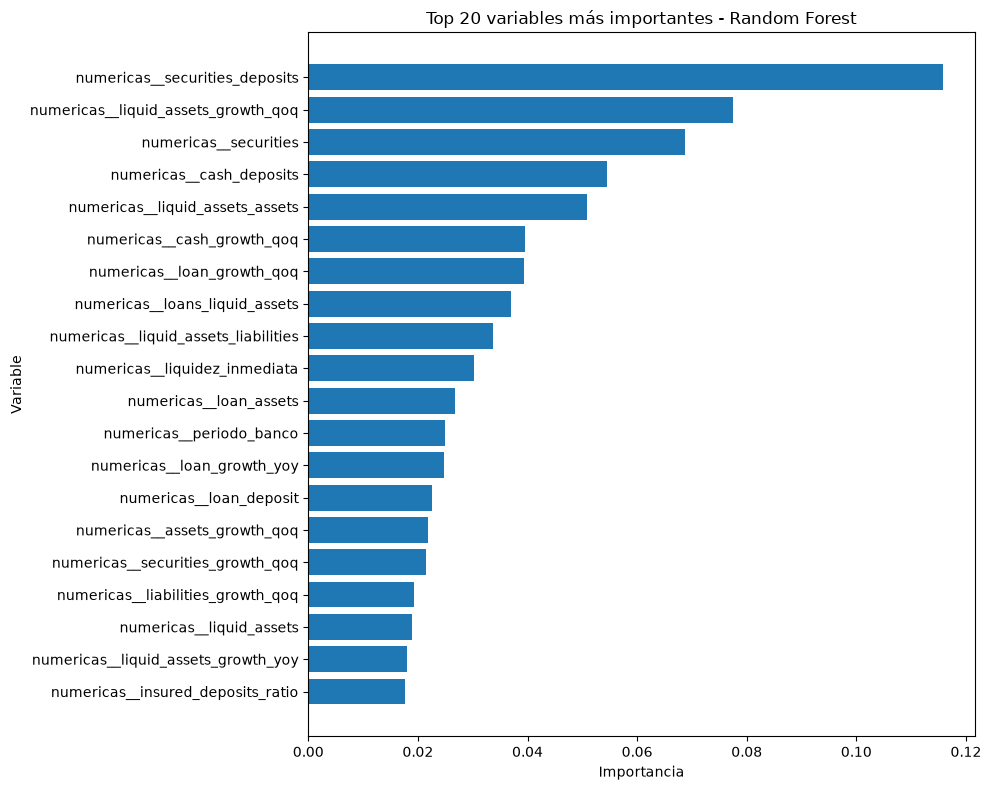

In [78]:
import matplotlib.pyplot as plt

top20_rf = (
    tabla_importancias_rf
    .head(20)
    .sort_values('importancia')
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_rf['variable'],
    top20_rf['importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Top 20 variables más importantes - Random Forest')

plt.tight_layout()
plt.show()

## 18. Importancia Acumulada

<div style="text-align: justify;">

Además del análisis individual de las variables, se calcula la **importancia acumulada** de las características ordenadas de mayor a menor contribución.

Este análisis permite determinar qué proporción de la importancia total del modelo se concentra en las primeras variables predictoras. De esta manera, es posible evaluar si la capacidad predictiva se encuentra distribuida entre un conjunto amplio de características o si está principalmente concentrada en un grupo reducido de indicadores.

La importancia acumulada constituye una herramienta descriptiva para comprender la estructura interna del modelo y facilita la identificación de las variables que concentran la mayor parte de la contribución predictiva.

</div>


In [79]:
# ============================================================
# 18.1 IMPORTANCIA ACUMULADA
# ============================================================

tabla_importancias_rf.head(30)[
    ['variable', 'importancia', 'importancia_acumulada']
]

print(tabla_importancias_rf)

                                             variable  importancia  \
0                      numericas__securities_deposits     0.115846   
1                 numericas__liquid_assets_growth_qoq     0.077443   
2                               numericas__securities     0.068727   
3                            numericas__cash_deposits     0.054504   
4                     numericas__liquid_assets_assets     0.050865   
..                                                ...          ...   
66  numericas__equity_growth_qoq_faltante_estructural     0.000189   
67  numericas__securities_growth_qoq_faltante_estr...     0.000188   
68                numericas__faltante_estructural_qoq     0.000170   
69    numericas__loan_growth_qoq_faltante_estructural     0.000169   
70                                 numericas__subdebt     0.000054   

    importancia_acumulada  
0                0.115846  
1                0.193289  
2                0.262016  
3                0.316520  
4                0.

## 19. Matriz de Confusión

<div style="text-align: justify;">

Como parte de la evaluación final del modelo definitivo se presenta la matriz de confusión correspondiente a las predicciones realizadas sobre el conjunto de prueba.

La matriz permite comparar los valores reales del evento de deterioro de liquidez con las clasificaciones generadas por el modelo utilizando el umbral establecido. De esta forma, se identifican los casos correctamente clasificados y los diferentes tipos de error cometidos.

Su análisis resulta especialmente importante para comprender el comportamiento del modelo frente al evento positivo, ya que permite determinar cuántos casos de deterioro fueron identificados correctamente y cuántos fueron clasificados incorrectamente.

</div>


In [80]:
pd.DataFrame(
    matriz_confusion_rf,
    index=['Real: No deterioro', 'Real: Deterioro'],
    columns=['Predicho: No deterioro', 'Predicho: Deterioro']
)

,Predicho: No deterioro,Predicho: Deterioro
Real: No deterioro,36699,9322
Real: Deterioro,1431,2690


## 20. Tabla de Resultados

<div style="text-align: justify;">

Finalmente, se consolidan los principales resultados obtenidos durante la evaluación del modelo definitivo en una tabla resumen.

La tabla permite presentar de manera estructurada las principales métricas de desempeño del Random Forest Optimizado, incluyendo ROC-AUC, Accuracy, Precision, Recall y F1-Score, utilizando el umbral de clasificación definido.

Esta consolidación facilita la interpretación del resultado final y permite documentar de forma resumida el desempeño alcanzado por el modelo sobre el conjunto de prueba.

</div>


In [81]:
# ============================================================
# 20.1 RESULTADOS FINALES
# ============================================================

resultados_modelo_definitivo = pd.DataFrame({
    'Modelo': ['Random Forest Optimizado'],
    'AUC': [auc_test_rf],
    'Accuracy': [accuracy_test_rf],
    'Precision': [precision_test_rf],
    'Recall': [recall_test_rf],
    'F1-score': [f1_test_rf],
    'Umbral': [0.50]
})

resultados_modelo_definitivo

,Modelo,AUC,Accuracy,Precision,Recall,F1-score,Umbral
0,Random Forest Optimizado,0.816065,0.785549,0.223943,0.652754,0.333478,0.5


## 21. Guardar Modelo

<div style="text-align: justify;">

Una vez completado el proceso de entrenamiento, evaluación y selección del modelo definitivo, se procede a almacenar los objetos necesarios para reproducir posteriormente el proceso de predicción.

El almacenamiento contempla no solamente el modelo Random Forest, sino también el preprocesador utilizado para transformar las variables y la lista de características empleadas durante el entrenamiento. Esta información es necesaria para garantizar que nuevos datos sean procesados de la misma manera que los datos utilizados durante el desarrollo.

Los objetos se almacenan utilizando `joblib` dentro de la carpeta `models`, siguiendo una estructura organizada del proyecto.

</div>



In [82]:
import os

ruta_modelos = r"D:\Edwin\DIPLOMADO INGENIERIA DE DATOS\Machine Learning II\Proyecto\LiquiditySense\models"

os.makedirs(
    ruta_modelos,
    exist_ok=True
)

In [83]:
import joblib

# Guardar modelo
joblib.dump(
    modelo_rf,
    os.path.join(
        ruta_modelos,
        'random_forest_liquidez.pkl'
    )
)

# Guardar preprocesador
joblib.dump(
    preprocesador,
    os.path.join(
        ruta_modelos,
        'preprocesador_liquidez.pkl'
    )
)

# Guardar variables
joblib.dump(
    list(X_train_def.columns),
    os.path.join(
        ruta_modelos,
        'variables_modelo.pkl'
    )
)

print("Modelo, preprocesador y variables guardados correctamente.")

Modelo, preprocesador y variables guardados correctamente.


## 22. Conclusión Final

<div style="text-align: justify;">

El desarrollo del modelo de predicción de deterioro de liquidez permitió construir un proceso completo de **Machine Learning aplicado al análisis de riesgo financiero**, partiendo de información histórica de entidades bancarias y estructurando una metodología orientada a identificar señales tempranas de reducción significativa de los activos líquidos.

En una primera etapa se definió el evento de deterioro a partir de la variación trimestral de los activos líquidos. El análisis de la distribución histórica permitió establecer de manera data-driven un umbral de **-13,14 %**, correspondiente al percentil 10 de la variación trimestral de liquidez. Bajo este criterio, se identificaron **68.654 eventos de deterioro**, equivalentes al **9,83 %** de los registros clasificables, frente a un **90,17 % de observaciones sin deterioro**. Esta distribución permitió caracterizar el problema como una clasificación binaria con una clase minoritaria de interés.

Posteriormente, se implementaron controles orientados a reducir el riesgo de **data leakage**, evitando utilizar como variables predictoras aquellos indicadores que contenían información directamente relacionada con la construcción del evento o con el comportamiento futuro de la liquidez. Asimismo, se realizó una revisión exploratoria de las variables predictoras y de su relación univariada con el `target`. Los resultados mostraron que las correlaciones lineales individuales fueron, en general, de magnitud baja, destacándose `liquid_assets_assets` con una correlación de **-0,1471** y `loan_assets` con **0,1227**. Esto evidenció que el deterioro de liquidez no puede explicarse adecuadamente mediante una única variable financiera y justificó la utilización de modelos capaces de capturar relaciones multivariadas y potencialmente no lineales.

La estrategia de validación se estructuró respetando la naturaleza temporal del problema. La información fue dividida en períodos de **entrenamiento, validación y prueba**, evitando una partición aleatoria que pudiera mezclar información de diferentes momentos del tiempo. Esta metodología permitió evaluar la capacidad de generalización del modelo hacia períodos posteriores a los utilizados durante su entrenamiento y selección.

Durante la comparación inicial de algoritmos se evaluaron **Random Forest, XGBoost, HistGradientBoosting y Extra Trees**. Random Forest presentó el mejor desempeño en términos de capacidad discriminatoria, alcanzando inicialmente un **ROC-AUC de 0,8127** en el conjunto de prueba. Además, obtuvo el mayor Recall entre los modelos comparados, con **66,17 %**, mostrando una mayor capacidad para detectar eventos de deterioro. Este comportamiento resultó particularmente relevante debido a que el objetivo principal del proyecto es identificar eventos adversos y no únicamente maximizar la proporción global de clasificaciones correctas.

A partir de la comparación de configuraciones se optimizó el Random Forest, seleccionando una estructura de **400 árboles, profundidad máxima de 12, mínimo de 30 observaciones por hoja y `max_features='sqrt'`**, manteniendo el tratamiento del desbalance mediante `class_weight='balanced'`. La selección se realizó utilizando el conjunto de validación y considerando conjuntamente AUC, Precision, Recall y F1-Score, evitando utilizar el conjunto de prueba para tomar decisiones durante la optimización.

La evaluación final del modelo optimizado sobre el conjunto de prueba mostró un **ROC-AUC de 0,8161**, **Accuracy de 78,55 %**, **Precision de 22,39 %**, **Recall de 65,28 %** y **F1-Score de 33,35 %**, utilizando inicialmente un umbral de clasificación de 0,50. El ROC-AUC obtenido evidencia una buena capacidad de discriminación, mientras que el Recall muestra que el modelo logra identificar aproximadamente **65 de cada 100 eventos reales de deterioro** bajo el umbral utilizado.

Sin embargo, los resultados también evidencian una limitación importante: la Precision de **22,39 %** indica la existencia de un número considerable de falsos positivos. Por tanto, el modelo no debe interpretarse como un mecanismo determinístico que establece que una entidad necesariamente experimentará un deterioro, sino como una **herramienta de alerta y priorización de riesgo**, capaz de identificar observaciones que presentan una mayor probabilidad de experimentar el evento definido.

En este sentido, el modelo desarrollado constituye una primera aproximación cuantitativa para la **detección temprana del deterioro de liquidez**. Su principal aporte consiste en transformar información financiera histórica en una señal predictiva que puede complementar los mecanismos tradicionales de monitoreo y análisis de riesgo.

Finalmente, para una eventual utilización en un entorno productivo, será necesario complementar este desarrollo con etapas adicionales de validación, incluyendo el análisis de estabilidad temporal del modelo, monitoreo de desempeño, revisión periódica de la distribución de las variables, evaluación de nuevos períodos de información y determinación de un **umbral de clasificación acorde con el costo relativo de los falsos positivos y falsos negativos**. Asimismo, deberá evaluarse periódicamente si el umbral estadístico utilizado para definir el evento de deterioro continúa siendo representativo de las condiciones del sistema financiero.

En conclusión, los resultados obtenidos permiten considerar que **Random Forest constituye un modelo viable para la identificación de señales tempranas de deterioro de liquidez**, al presentar una capacidad de discriminación consistente fuera de muestra y una capacidad relevante para detectar la clase de interés. No obstante, su utilización debe entenderse como un **instrumento de apoyo para la gestión y monitoreo del riesgo**, sujeto a validación, seguimiento y recalibración periódica, y no como un sustituto del análisis financiero y de riesgo realizado por la institución.

</div>
